# Kandinsky 2.2 — DIMER E2E text-to-image fine-tuning tutorial (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/kandinsky-generation-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/kandinsky-generation-pipeline/blob/main/tutorials/kandinsky_generation_colab.ipynb) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-kandinsky--community%2Fkandinsky--2--2--decoder-ffcc4d?style=flat)](https://huggingface.co/kandinsky-community/kandinsky-2-2-decoder) [![Upstream](https://img.shields.io/badge/Upstream-ai--forever%2FKandinsky--2-181717?style=flat&logo=github&logoColor=white)](https://github.com/ai-forever/Kandinsky-2) [![License](https://img.shields.io/badge/License-Apache--2.0-blue.svg)](https://www.apache.org/licenses/LICENSE-2.0)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** text-to-image generation with a 1.25 B-parameter UNet diffusion model, held-out denoising-loss and CLIP-scored evaluation, and bounded LoRA fine-tuning to a set of captioned photographs

**This notebook is standalone.** Section 2 carries the repository's package (4 modules under `src/kandinsky_generation_pipeline/`, at revision `7b64e2f045ca`), the stage runner, the hash-locked requirements (68 packages), the pinned snapshot manifests and the licence, and verifies every carried file against its SHA-256 before use, so the notebook keeps working after export even if the repository changes or disappears. Nothing is installed into the notebook kernel: a pinned `uv` (checked by size and SHA-256) builds an isolated Python environment from the lock with `--require-hashes`, and every stage runs there in its own process, so the hosted runtime's own packages are never replaced and no restart is needed. Its only external dependencies are PyPI, the managed CPython build that `uv` downloads, the Hugging Face Hub at the immutable revision `9ae140d347fed8ce6e8bb3005dcc1f48543bb8e3` and its two companion revisions (~16467 MB, digest-verified before loading), and the public sample-data bucket named in the Prerequisites. It was generated by `tools/build_notebook.py` (build_notebook.py/3.0); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh Linux **GPU** runtime (a 16 GB T4 is enough; see the Prerequisites) builds an isolated Python environment from the carried hash-locked requirements (torch, diffusers, transformers, peft, accelerate, sentencepiece, safetensors, huggingface-hub, numpy, pillow and their dependencies) without touching the notebook kernel's own packages, then runs each stage below in its own process: it stages and digest-verifies three pinned snapshots from the Hub — the 5.28 GB Kandinsky 2.2 decoder (UNet + MoVQ), the 10.57 GB Kandinsky 2.2 diffusion prior, and a 0.6 GB CLIP scorer — fetches 60 CC0 iNaturalist bird photographs as digest-verified JPEGs (6 MB, no credential), validates them and splits them 36 / 12 / 12 by seed, encodes every prompt with the prior into image embeddings and releases the prior, scores the frozen model — the held-out denoising loss on the validation and test photographs, and twelve generated images scored by CLIP against their prompts and the held-out photographs, beside a leave-one-out real-photo reference line — runs a bounded LoRA fine-tuning (4 epochs over 36 images) and exports the adapter as safetensors with a manifest, scores the exported adapter in a fresh process on identical inputs, and reloads it in a second fresh process to verify parity with the trained in-memory model before rendering a new prompt. The default path needs no repository clone, no DIMER worker or service, no credential, no upload dialog, no configuration edit and no runtime restart (NOTEBOOK_SPEC 2.2 §5). **Duration:** about 13 minutes on a Kaggle T4 — 795.8 s, measured on 2026-09-29 in a strict single-pass run of the previous revision of this notebook, which runs the same stages, starting from an empty Hugging Face cache, so the environment build and the 16.5 GB of downloads are included; your runtime will vary with the network and the GPU.

**Bring Your Own Data:** After the tutorial workflow completes, set `USE_BYOD = True` in Section 4 and re-run from that cell to supply your own captioned photographs as a zip holding `captions.csv` (columns `id`, `file`, `caption`) beside the image files (JPEG or PNG, shorter side 256..4096 px). **Minimum:** at least one caption with six or more distinct images; more captions are welcome, and a caption with fewer than three images is used for training only. Your records are split **stratified within each caption** — every caption with three or more images gives about 20 % of its images to validation and 20 % to test — and flow through the same contract — validation, prompt encoding, frozen baseline, adaptation, held-out evaluation, generation, artifact export and reload parity. The split assumes your photographs are independent: only exact (pixel-identical) copies are removed, so take out near-duplicates (bursts, crops, the same individual or scene) before zipping, or they can sit on both sides of the split and inflate the held-out numbers. The expected schema, the size limits and the privacy guidance are stated in the Prerequisites and in Section 4, and uploaded files stay inside this runtime. Set `BYOD_PATH` to a zip already in the runtime to skip the upload dialog. BYOD is optional and never part of the default path.

Kandinsky 2.2 (Shakhmatov et al., 2023) is a two-stage latent diffusion architecture: a frozen diffusion prior with CLIP ViT-G/14 encoders maps text prompts to image embeddings, a 1.25 B-parameter UNet denoises a 4-channel latent conditioned on those image embeddings with classifier-free guidance, and a MoVQ decoder (67.8 M parameters) decodes the latent to 3-channel RGB pixels. Three pinned snapshots make one generator: the decoder (5.28 GB safetensors), the shared diffusion prior (10.57 GB safetensors) and, for evaluation only, a CLIP ViT-B/32 scorer.

Two architectural properties are handled in the open. **The prior pipeline can be released before training**: Section 5 encodes every prompt the notebook will ever use — the 60 captions, the generation prompts, the empty negative prompt — into image embeddings on the CPU, and releases the prior so the UNet, the MoVQ, the scorer and a training graph fit comfortably on a 16 GB GPU. **Generation has no ground truth**, so the notebook reads three kinds of number: the held-out *denoising loss* (the training objective, measured on photographs the model never trained on), CLIP scores of generated images (prompt alignment and similarity to real photographs), and the same CLIP scores on the real photographs themselves — a **reference line, not a ceiling**: each photo is compared with the other held-out photos of its caption, never with itself, and generated images can score above it. None of these is a human judgement of image quality.

**Learning objectives:** by the end of this notebook you will be able to —

1. **Explain** how a prompt becomes an image in Kandinsky 2.2 (prior → image embedding → UNet denoising under classifier-free guidance → MoVQ decoding) and why the notebook can release the prior before training (Section 5).
2. **Diagnose** an invalid training record from a validation refusal, and **explain** why the sample split is drawn per species (Section 4).
3. **Interpret** a held-out denoising loss, a CLIP prompt similarity, a zero-shot label accuracy and a reference similarity, and **compare** the frozen model with the leave-one-out real-photo reference line, saying why it is not a ceiling (Section 6).
4. **Apply** a bounded LoRA fine-tuning with explicit hyperparameters and **identify** which parameters it trains and how the kept epoch is chosen (Section 7).
5. **Compare** the adapted and the frozen model on identical held-out inputs, and **distinguish** what the procedure guarantees from what is only observed (Section 8).
6. **Verify** that an exported adapter, reloaded from files, reproduces the held-out loss and the image of the in-memory model (Section 9).
7. **Predict**, run and **explain** the effect of changing one generation setting, the guidance scale, in an optional activity (Section 10).
8. **Write** an evidence-based conclusion that names the baseline, the real-photo reference and the limits of twelve held-out photographs (Conclusion).

**This notebook does not demonstrate:** Kandinsky 2.1, inpainting, ControlNet depth conditioning (each in their own repository), full fine-tuning, DreamBooth identifiers, safety filtering of prompts or images, human preference benchmarks, prompt engineering, and any claim that a CLIP score or a denoising loss measures image quality. The repository exposes none of these.

## How to use this notebook

**Who this notebook is for.** Learners who can open a hosted notebook (Google Colab or Jupyter), run cells in order and read short Python, and who want to see how a text-to-image diffusion model is evaluated and adapted. No prior experience with diffusion models is assumed: each term is explained where it is first needed, and the glossary below collects them. You need a CUDA **GPU** with at least 15 GB of memory — a Colab T4 is enough — and about 30 GB of free disk; CPU-only runtimes are not supported. The **Prerequisites** give the details.

**Running it.** In Colab, choose *Runtime → Change runtime type → T4 GPU*, then *Runtime → Run all*. The default path needs no edit, no upload, no account, no token and no runtime restart. Sections 1–3 build an isolated environment from hash-locked packages and download about 16.5 GB of verified weights, so they take the longest before any model runs; read ahead while they finish, or run the notebook one cell at a time with *Shift + Enter*.

**Where the code runs.** The notebook kernel installs nothing and imports no model library. Each learner cell calls `run_stage('…')`, which runs one stage of the carried stage runner in its own process with the isolated environment's Python, streams what it prints, and stops the notebook with the stage's own error message if it fails. Stages hand results to each other only through files in the run directory — the verified snapshots, the prompt embeddings, the adapter artifact and JSON records — and GPU memory is released when each stage ends.

**Two kinds of cell.** *Learner cells* (Sections 4–10) are the machine-learning workflow; each runs one stage and prints compact dictionaries for you to read. *Infrastructure cells* (Sections 1–3: the runtime check, the carried code, the isolated install and the pinned-weight staging) are collapsed and titled **Infrastructure**. You may run them without studying their implementation: they exist for reproducibility and provenance, not as prerequisite machine-learning knowledge. Open one with *Show code* if you are curious.

**Form controls.** Some learner cells start with fields that Colab renders as a form: `USE_BYOD` and `BYOD_PATH` (Section 4); `STEPS`, `GUIDANCE_SCALE` and `IMAGES_PER_PROMPT` (Section 6); `EPOCHS`, `LEARNING_RATE` and `BATCH_SIZE` (Section 7); and `RUN_ACTIVITY` and `ACTIVITY_GUIDANCE_SCALE` in the optional activity (Section 10). Leave them at their defaults for the first run: the notes and sample answers describe the default path. Changing a field and re-running from that cell is how you experiment afterwards.

**Section tags.** Each numbered heading carries one tag. **[Concept]** — what the model does and why. **[Evaluation practice]** — how the evidence is produced and how to read it. **[Engineering]** — reproducibility, provenance and packaging.

**Predict, then check.** Before each principal result a **Predict before running** prompt asks you to commit to an expectation; after it, **What to notice** describes normal output and a collapsed **Check your reasoning** answer follows each checkpoint. Write your own answer first, then open it. Exact numbers vary with the runtime and the library versions, so the notes describe the shape of a normal result rather than fixed values.

## The task: Input → Model/System → Output

| Stage | Input | Model / system | Output |
|---|---|---|---|
| **Generation** | a text prompt | diffusion prior (text → CLIP image embedding) → UNet, with its LoRA adapter, denoising a random 4 × 64 × 64 latent over `STEPS` steps under classifier-free guidance → MoVQ decoder | one 512 × 512 RGB image |
| **Adaptation** | a captioned photograph | MoVQ encoder → latent + seeded noise at a random timestep → UNet predicts the noise; the mean-squared error to the true noise updates only the LoRA tensors | a small safetensors adapter |
| **Evaluation** | held-out photographs and fixed prompt/seed pairs | the frozen and the adapted model, scored the same way; a frozen CLIP ViT-B/32 scores the images | a denoising loss per timestep; CLIP scores of generated images beside the same scores on the real photographs (a reference line, not a ceiling) |

No stage judges image quality: the loss is the training objective and the CLIP scores are another frozen model's opinion.

## Roadmap

| Section | Tag | What happens | What you read |
|---|---|---|---|
| 1. Check the runtime | [Engineering] | Linux, GPU and disk checked; a fresh run directory | the GPU name |
| 2. Carry the code, install the runtime | [Engineering] | carried files verified; an isolated hash-locked environment | versions, `cuda: True` |
| 3. Pin, stage and verify | [Engineering] | three snapshots downloaded and digest-checked | file counts |
| 4. Sample photographs | [Evaluation practice] | 60 photographs validated and split 36 / 12 / 12 | split sizes, refusals |
| 5. Encode prompts, release the prior | [Concept] | prompts → image embeddings, prior dropped | GPU memory |
| 6. The frozen model | [Evaluation practice] | baseline loss and CLIP scores, real-photo reference | the baseline |
| 7. LoRA fine-tuning | [Concept] | a bounded adaptation of the UNet | the epoch history |
| 8. Held-out comparison | [Evaluation practice] | frozen vs adapted on identical inputs | the principal result |
| 9. Fresh reload and a new prompt | [Engineering] | the adapter reloaded in a new process; an unseen prompt | reload parity |
| 10. Optional activity | [Concept] | change the guidance scale (off by default) | your comparison |
| Troubleshooting | [Engineering] | common hosted-runtime failures | when something fails |
| Interpretation and conclusion | [Evaluation practice] | limits and an evidence-based conclusion | your conclusion |

**Fast path.** Short on time? Run all, then read Sections 6 and 8 and the conclusion: they carry the principal results. The canonical path ends with Section 9; Section 10 changes nothing unless you switch it on.

<details>
<summary><strong>Glossary</strong> — open when a term is unfamiliar</summary>

| Term | Meaning in this notebook |
|---|---|
| **Latent diffusion** | Generating an image by starting from random noise in a compressed *latent* space and removing the noise step by step; a decoder then turns the latent into pixels. |
| **Latent** | The compressed representation the UNet works on: 4 channels of 64 × 64 for a 512 × 512 image. |
| **Diffusion prior** | Kandinsky's first stage: a model that turns a text prompt into a predicted CLIP *image* embedding. Frozen here. |
| **Image embedding** | A vector summarising an image's content; the UNet is conditioned on it rather than on text. |
| **UNet** | The 1.25 B-parameter network that predicts the noise in a latent at a given timestep. |
| **MoVQ** | The decoder (and encoder) between latents and pixels. Frozen here. |
| **Timestep** | How far along the noise schedule a latent is: 0 is almost clean, 999 almost pure noise. |
| **Denoising loss** | Mean-squared error between the noise the UNet predicts and the noise that was added. It is the training objective, not a quality score. |
| **Classifier-free guidance** | At each generation step the UNet runs with the prompt's embedding and with the empty (negative) prompt's; the difference is amplified by the *guidance scale*. |
| **Guidance scale** | How strongly generation follows the prompt. `GUIDANCE_SCALE = 4.0` by default; 1.0 switches guidance off. |
| **Seed** | The number that fixes the random noise, so the same prompt, seed and settings give the same image. |
| **Frozen model** | The pretrained model with its weights unchanged; here, the UNet with a LoRA adapter whose output starts at zero. |
| **LoRA** | Low-rank adaptation: small trainable matrices added to the attention projections, trained while the original weights stay fixed. |
| **Rank** | The inner size of the LoRA matrices (8 here); it bounds how much the adapter can change. |
| **Epoch** | One pass over the 36 training photographs. |
| **Validation / test split** | Validation photographs choose the kept epoch; test photographs are used only for the final comparison. |
| **CLIP score** | Cosine similarity between CLIP embeddings of an image and a text (or another image), × 100. |
| **Label accuracy** | The share of generated images whose nearest caption, according to CLIP, is their own prompt (zero-shot, argmax rule). |
| **Reference similarity** | CLIP similarity between a generated image and the average of the held-out real photographs with the same caption. |
| **Real-photo reference** | The same CLIP scores computed on the real test photographs, each photo's reference similarity measured against the *other* test photos of its caption (leave-one-out). A reference line, not a ceiling: generated images can score above it on prompt similarity and reference similarity. |
| **Adapter / artifact** | The trained LoRA tensors saved as `adapter.safetensors` with a `manifest.json`. |
| **Digest (SHA-256)** | A fingerprint of a file's bytes; a single changed byte changes it. |
| **Hash-locked environment** | A separate Python environment built from a requirements file that pins every package to one version and one set of SHA-256 digests; the installer refuses anything else. |
| **Stage** | One step of the workflow run as its own process by `run_stage`; it reads the files earlier stages wrote and writes its own. |
| **BYOD** | Bring Your Own Data: an optional switch to run the same workflow on your own captioned photographs. |

</details>

## Prerequisites

- **Runtime:** a fresh supported **Linux x86_64 GPU** runtime (Google Colab T4 or better, Kaggle T4, or a Linux Jupyter kernel with a CUDA GPU of at least 15 GB). The kernel's own Python version does not matter: the notebook installs nothing into it, and runs every stage with CPython 3.12.12 in an isolated environment built from 68 hash-locked packages (torch 2.14.0, whose Linux wheel is the CUDA 13.0 build). The prior runs in float16 while it encodes prompts and is then released; the UNet runs in float16 (2.5 GB) with the LoRA parameters in float32; the MoVQ decoder runs in float16 (0.13 GB). CPU-only runtimes are not supported. About 18 GB of disk is needed for the snapshots and about 12 GB for the isolated environment.
- **Knowledge:** what a two-stage latent diffusion model does at inference (prompt → image embedding via prior → latent via UNet → pixels via MoVQ), what classifier-free guidance is, what a LoRA adapter changes and what it does not, and why a training loss is not a quality score.
- **Weights:** the decoder, the diffusion prior and the CLIP scorer are all safetensors; nothing is unpickled and no Hub-hosted code is executed — the model classes come from `diffusers`, `transformers` and `peft` on PyPI. Upstream weights are released under Apache-2.0; the scorer is MIT.
- **Data contract:** a record is `{id, image, caption}` — an RGB image with shorter side 256..4096 px (resized so the shorter side is 512 px and centre-cropped to 512 × 512; the crop is reported) and a caption of 1..1000 characters. Validation is structural: nothing checks that a caption describes its image or that the model can render it.
- **Privacy:** Do not upload confidential or restricted data to a hosted runtime unless you are authorized to process it there — photographs of identifiable people, licensed stock images or client material are exactly that. The default path uploads nothing.
- **External access (data):** besides the Hub, the default path fetches 60 pinned photographs (about 6 MB) from the public iNaturalist open-data bucket `inaturalist-open-data.s3.amazonaws.com` over HTTPS, digest-verified before decoding; every photo is CC0 and its observation page is recorded.
- **External access:** the Hugging Face Hub, to fetch the pinned `kandinsky-community/kandinsky-2-2-decoder` snapshot and its companions (~16467 MB in total) at revision `9ae140d347fe…` and the revisions in the carried manifests; PyPI (`files.pythonhosted.org`), for the pinned `uv` wheel and the 68 hash-locked packages; and the managed CPython build (python-build-standalone) that `uv` downloads for the isolated environment. No repository clone and no credentials are required; nothing is installed from this repository.

## 1. Check the runtime · [Engineering]

> **Infrastructure.** The code cells in Sections 1–3 are collapsed. You may run them without studying their implementation; they exist for reproducibility and provenance. The learning activities start in Section 4.

**Input:** a fresh hosted runtime. **System:** checks that it is Linux x86_64 with a CUDA GPU and enough free disk, and creates a new run directory. **Output:** the GPU name and the directories this run will use. Each run writes to a new directory under `outputs/kandinsky_generation/`, so an earlier export cannot be mistaken for a current result. The verified snapshots are kept in `weights/` and reused by a later run.

In [ ]:
# @title Infrastructure: check the runtime, GPU and disk; create a fresh run directory
import hashlib
import json
import os
import platform
import shutil
import subprocess
import tempfile
import time
import uuid
from pathlib import Path

SESSION_START = time.perf_counter()
if platform.system() != 'Linux' or platform.machine() != 'x86_64':
    raise RuntimeError('This notebook needs a Linux x86_64 GPU runtime (Google Colab or Kaggle with a T4 or better): its locked environment is built for manylinux x86_64.')
try:
    gpu = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], capture_output=True, text=True)
except FileNotFoundError as exc:
    raise RuntimeError('No GPU driver was found. Select Runtime > Change runtime type > T4 GPU, then Run all.') from exc
if gpu.returncode:
    raise RuntimeError('CUDA was not detected. Select a fresh T4 GPU runtime, then Run all.')
STEM = 'kandinsky_generation'
ROOT = Path.cwd() / 'outputs' / STEM / uuid.uuid4().hex[:12]
ROOT.mkdir(parents=True)
WEIGHTS = Path.cwd() / 'weights'
WEIGHTS.mkdir(exist_ok=True)
ENV_ROOT = Path(tempfile.gettempdir()) / (STEM + '_env_' + ROOT.name)
staged_gib = sum(p.stat().st_size for p in WEIGHTS.rglob('*') if p.is_file()) / 1024**3
need = {'weights': max(0.0, 17.5 - staged_gib), 'environment': 12.0}
free = {'weights': shutil.disk_usage(WEIGHTS).free / 1024**3, 'environment': shutil.disk_usage(tempfile.gettempdir()).free / 1024**3}
if os.stat(WEIGHTS).st_dev == os.stat(tempfile.gettempdir()).st_dev:
    short = free['weights'] < need['weights'] + need['environment']
else:
    short = free['weights'] < need['weights'] or free['environment'] < need['environment']
if short:
    raise RuntimeError(f'Not enough free disk: need about {need} GiB, free {free} GiB. Start a fresh runtime (see Troubleshooting).')
print({'gpu': gpu.stdout.strip(), 'kernel_python': platform.python_version(), 'run_directory': str(ROOT), 'weights': str(WEIGHTS), 'environment': str(ENV_ROOT), 'free_gib': {k: round(v, 1) for k, v in free.items()}})

{'gpu': 'Tesla T4, 15360 MiB', 'kernel_python': '3.13.15', 'run_directory': '/content/outputs/kandinsky_generation/e1c4f6048f1f', 'weights': '/content/weights', 'environment': '/tmp/kandinsky_generation_env_e1c4f6048f1f', 'free_gib': {'weights': 193.2, 'environment': 193.2}}


**Expected result:** one dictionary naming the GPU (for example `Tesla T4, 15360 MiB`), the kernel's Python version, the run directory, the weights directory, the isolated environment's directory and the free disk. If the cell stops with a GPU or disk message, see **Troubleshooting**.

## 2. Carry the code and install the locked runtime · [Engineering]

> **Infrastructure.** The next two code cells are collapsed. The first **is** the repository's code, carried so that this notebook works on its own; the second builds the environment every stage runs in.

The first cell holds, as text, the files the workflow needs: the package's four modules under `src/kandinsky_generation_pipeline/` (identity constants, snapshot verification and staging, validation, the pipeline class, the sample corpus and the CLIP metrics), the stage runner `tutorial_stages.py`, the hash-locked `requirements.txt` (68 packages), the three snapshot manifests and the licence. It writes each file into the run directory and checks its SHA-256 against `CARRIED_HASHES`, stopping on any mismatch. The text is the repository's files byte for byte; the repository's parity test (`tests/test_notebook_parity.py`) fails whenever the two diverge, so what runs here is what the repository tests. Nothing in this cell runs a model.

In [ ]:
# @title Infrastructure: write and verify the carried package, stage runner, lock and manifests
CARRIED_FILES = {'src/kandinsky_generation_pipeline/__init__.py': '"""DIMER pipeline for Kandinsky 2.2 Text-to-Image: verified snapshots, two-stage generation (Prior + Decoder),\nheld-out denoising-loss evaluation, CLIP-scored generations, and bounded LoRA fine-tuning with a portable adapter."""\n\nfrom .metrics import (\n    REAL_PHOTO_REFERENCE_KIND,\n    REAL_PHOTO_REFERENCE_READING,\n    ClipScorer,\n    real_photo_baseline,\n    real_photo_reference,\n    score_generations,\n)\nfrom .pipeline import (\n    DEFAULT_GUIDANCE,\n    DEFAULT_STEPS,\n    DEFAULT_WEIGHTS_DIR,\n    EVAL_TIMESTEPS,\n    INPUT_SCHEMA,\n    LORA_ALPHA,\n    LORA_PARAMETERS,\n    LORA_RANK,\n    LORA_TARGETS,\n    LORA_TENSORS,\n    MANIFEST_NAME,\n    MAX_CAPTION_CHARS,\n    MAX_IMAGE_SIDE,\n    MIN_IMAGE_SIDE,\n    MIN_TRAIN_RECORDS,\n    MODEL_ID,\n    MODEL_KEY,\n    MODEL_LICENSE,\n    MODEL_REVISION,\n    MOVQ_PARAMETERS,\n    MOVQ_TENSORS,\n    PRIOR_ID,\n    PRIOR_KEY,\n    PRIOR_LICENSE,\n    PRIOR_PARAMETERS,\n    PRIOR_REVISION,\n    PRIOR_TENSORS,\n    PRIOR_WEIGHTS_DIR,\n    RESOLUTION,\n    SCORER_ID,\n    SCORER_KEY,\n    SCORER_LICENSE,\n    SCORER_REVISION,\n    SCORER_WEIGHTS_DIR,\n    UNET_PARAMETERS,\n    UNET_TENSORS,\n    KandinskyPipeline,\n    build_prior,\n    build_unet,\n    dataset_digest,\n    image_digest,\n    lora_parameter_names,\n    preprocess_image,\n    prompt_seed,\n    stage_missing_files,\n    stage_missing_prior_files,\n    stage_missing_scorer_files,\n    validate_dataset,\n    validate_inputs,\n    validate_prompts,\n    verify_prior_snapshot,\n    verify_scorer_snapshot,\n    verify_snapshot,\n)\nfrom .samples import (\n    CAPTION_TEMPLATE,\n    CORPUS_BASE_URL,\n    CORPUS_LICENSE,\n    MIN_BYOD_IMAGES_PER_CAPTION,\n    SAMPLE_LABEL_SOURCE,\n    SAMPLE_RECORDS,\n    SAMPLE_SPLIT,\n    SPECIES,\n    build_sample_dataset,\n    caption_for,\n    check_split_disjoint,\n    dataset_manifest,\n    fetch_corpus,\n    fetch_sample_dataset,\n    load_byod_dataset,\n    read_corpus,\n    sample_prompts,\n    split_dataset,\n    write_dataset_csv,\n)\n\n__all__ = [\n    "CAPTION_TEMPLATE",\n    "CORPUS_BASE_URL",\n    "CORPUS_LICENSE",\n    "DEFAULT_GUIDANCE",\n    "DEFAULT_STEPS",\n    "DEFAULT_WEIGHTS_DIR",\n    "EVAL_TIMESTEPS",\n    "INPUT_SCHEMA",\n    "LORA_ALPHA",\n    "LORA_PARAMETERS",\n    "LORA_RANK",\n    "LORA_TARGETS",\n    "LORA_TENSORS",\n    "MANIFEST_NAME",\n    "MAX_CAPTION_CHARS",\n    "MAX_IMAGE_SIDE",\n    "MIN_BYOD_IMAGES_PER_CAPTION",\n    "MIN_IMAGE_SIDE",\n    "MIN_TRAIN_RECORDS",\n    "MODEL_ID",\n    "MODEL_KEY",\n    "MODEL_LICENSE",\n    "MODEL_REVISION",\n    "MOVQ_PARAMETERS",\n    "MOVQ_TENSORS",\n    "PRIOR_ID",\n    "PRIOR_KEY",\n    "PRIOR_LICENSE",\n    "PRIOR_PARAMETERS",\n    "PRIOR_REVISION",\n    "PRIOR_TENSORS",\n    "PRIOR_WEIGHTS_DIR",\n    "REAL_PHOTO_REFERENCE_KIND",\n    "REAL_PHOTO_REFERENCE_READING",\n    "RESOLUTION",\n    "SAMPLE_LABEL_SOURCE",\n    "SAMPLE_RECORDS",\n    "SAMPLE_SPLIT",\n    "SCORER_ID",\n    "SCORER_KEY",\n    "SCORER_LICENSE",\n    "SCORER_REVISION",\n    "SCORER_WEIGHTS_DIR",\n    "SPECIES",\n    "UNET_PARAMETERS",\n    "UNET_TENSORS",\n    "ClipScorer",\n    "KandinskyPipeline",\n    "build_prior",\n    "build_sample_dataset",\n    "build_unet",\n    "caption_for",\n    "check_split_disjoint",\n    "dataset_digest",\n    "dataset_manifest",\n    "fetch_corpus",\n    "fetch_sample_dataset",\n    "image_digest",\n    "load_byod_dataset",\n    "lora_parameter_names",\n    "preprocess_image",\n    "prompt_seed",\n    "read_corpus",\n    "real_photo_baseline",\n    "real_photo_reference",\n    "sample_prompts",\n    "score_generations",\n    "split_dataset",\n    "stage_missing_files",\n    "stage_missing_prior_files",\n    "stage_missing_scorer_files",\n    "validate_dataset",\n    "validate_inputs",\n    "validate_prompts",\n    "verify_prior_snapshot",\n    "verify_scorer_snapshot",\n    "verify_snapshot",\n    "write_dataset_csv",\n]\n', 'src/kandinsky_generation_pipeline/pipeline.py': '"""Kandinsky 2.2 Text-to-Image (`kandinsky-community/kandinsky-2-2-decoder` + `kandinsky-community/kandinsky-2-2-prior`)\nDIMER pipeline: verified snapshots, two-stage generation (Prior + Decoder), held-out denoising-loss evaluation,\nand bounded LoRA fine-tuning of the UNet with a portable adapter.\n\nKandinsky 2.2 (Shakhmatov et al., 2023) is a latent diffusion architecture combining:\n* A **diffusion prior** (1.03 B parameters) with CLIP-ViT-G/14 image and text encoders that maps text prompts\n  to predicted CLIP image embeddings;\n* A **UNet2DConditionModel** (1.25 B parameters) that denoises 4-channel latents conditioned directly on the\n  predicted image embeddings under classifier-free guidance;\n* A **MoVQ VQModel** decoder (67.8 M parameters) that decodes 4-channel latents to 3-channel RGB pixels.\n\nThree pinned snapshots are used, each verified against its DIMER manifest:\n* The **decoder** (`MODEL_ID`, 5.28 GB safetensors, UNet + MoVQ, run in float16 on CUDA);\n* The **prior** (`PRIOR_ID`, 10.57 GB safetensors, Prior diffusion model + CLIP encoders);\n* The **scorer** used for evaluation (`SCORER_ID`, an MIT-licensed CLIP ViT-B/32, 605 MB).\n\nEvery file is safetensors or plain JSON/text: nothing is unpickled and no Hub-hosted code is executed.\nThe adaptation contract attaches LoRA to the attention projections of the UNet (rank 8, 176 tensors,\n1,646,592 parameters); MoVQ, Prior and text/image encoders remain frozen. Everything model-related is imported\nlazily so snapshot verification and input validation run before torch/diffusers/transformers are imported (fleet RTM-001).\n"""\n\nfrom __future__ import annotations\n\nimport gc\nimport hashlib\nimport json\nimport math\nimport time\nimport warnings\nfrom collections.abc import Callable, Mapping, Sequence\nfrom dataclasses import dataclass, field\nfrom pathlib import Path\nfrom typing import Any\n\nMODEL_ID = "kandinsky-community/kandinsky-2-2-decoder"\nMODEL_REVISION = "9ae140d347fed8ce6e8bb3005dcc1f48543bb8e3"\nMODEL_LICENSE = "apache-2.0"\nMODEL_KEY = "kandinsky-2-2-decoder"\nARTIFACT_FORMAT = "org.valcorza.kandinsky-generation.adapter.v1"\nARTIFACT_FORMAT_VERSION = "1.0"\nARTIFACT_WEIGHTS_NAME = "adapter.safetensors"\nARTIFACT_MANIFEST_NAME = "manifest.json"\n_WEIGHTS_ROOT = Path(__file__).resolve().parents[2] / "weights"\nDEFAULT_WEIGHTS_DIR = _WEIGHTS_ROOT / MODEL_KEY\nMANIFEST_NAME = "dimer-base-manifest.json"\n\n# Shared prior snapshot: diffusion prior + CLIP ViT-G text/image encoders\nPRIOR_ID = "kandinsky-community/kandinsky-2-2-prior"\nPRIOR_REVISION = "9fc51ad5732afc5d031724219d22e6c42179c5a8"\nPRIOR_LICENSE = "apache-2.0"\nPRIOR_KEY = "kandinsky-2-2-prior"\nPRIOR_WEIGHTS_DIR = _WEIGHTS_ROOT / PRIOR_KEY\n\n# Evaluation scorer (CLIP ViT-B/32 safetensors)\nSCORER_ID = "laion/CLIP-ViT-B-32-laion2B-s34B-b79K"\nSCORER_REVISION = "1a25a446712ba5ee05982a381eed697ef9b435cf"\nSCORER_LICENSE = "mit"\nSCORER_KEY = "clip-vit-b-32-laion2b"\nSCORER_WEIGHTS_DIR = _WEIGHTS_ROOT / SCORER_KEY\n\n# Architecture and contract facts\nUNET_PARAMETERS = 1_253_057_288\nUNET_TENSORS = 724\nMOVQ_PARAMETERS = 67_832_495\nMOVQ_TENSORS = 431\nPRIOR_PARAMETERS = 1_026_225_920\nPRIOR_TENSORS = 338\n\nRESOLUTION = 512\nLATENT_CHANNELS = 4\nMOVQ_SCALE = 8\nMAX_CAPTION_CHARS = 1_000\nMIN_IMAGE_SIDE = 256\nMAX_IMAGE_SIDE = 4_096\nMIN_TRAIN_RECORDS = 4\nMAX_RECORDS = 2_000\nDEFAULT_STEPS = 20\nDEFAULT_GUIDANCE = 4.0\nMAX_STEPS = 100\nMAX_GUIDANCE = 20.0\nNUM_TRAIN_TIMESTEPS = 1000\nEVAL_TIMESTEPS: tuple[int, ...] = (100, 300, 500, 700, 900)\nLORA_RANK = 8\nLORA_ALPHA = 8\nLORA_TARGETS: tuple[str, ...] = ("to_q", "to_k", "to_v", "to_out.0")\nLORA_TENSORS = 176\nLORA_PARAMETERS = 1_646_592\nNEGATIVE_PROMPT = ""\n\n\n# --------------------------------------------------------------------------------------------------\n# manifests and staging (three pinned snapshots)\n# --------------------------------------------------------------------------------------------------\n\n\ndef _sha256_file(path: Path) -> str:\n    digest = hashlib.sha256()\n    with open(path, "rb") as fh:\n        for chunk in iter(lambda: fh.read(1 << 20), b""):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef prompt_seed(prompt: str) -> int:\n    """Seed for the prior\'s sampler: the first 4 bytes of SHA-256(prompt), masked to 31 bits.\n\n    Stable across processes, unlike ``hash(prompt)``, which Python salts per interpreter.\n    """\n    return int.from_bytes(hashlib.sha256(prompt.encode("utf-8")).digest()[:4], "big") & 0x7FFFFFFF\n\n\ndef _verify_manifest(root: Path, model_id: str, revision: str) -> dict[str, Any]:\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f"no snapshot manifest at {manifest_path}")\n    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))\n    if manifest.get("modelId") != model_id:\n        raise ValueError(f"manifest modelId {manifest.get(\'modelId\')!r} != {model_id!r}")\n    if manifest.get("revision") != revision:\n        raise ValueError(f"manifest revision {manifest.get(\'revision\')!r} != {revision!r}")\n    for entry in manifest["files"]:\n        file_path = root / entry["path"]\n        if not file_path.is_file():\n            raise FileNotFoundError(f"snapshot file missing: {file_path}")\n        size = file_path.stat().st_size\n        if size != entry["bytes"]:\n            raise ValueError(f"{entry[\'path\']}: size {size} != manifest {entry[\'bytes\']}")\n        digest = _sha256_file(file_path)\n        if digest != entry["sha256"]:\n            raise ValueError(f"{entry[\'path\']}: sha256 {digest} != manifest {entry[\'sha256\']}")\n        if not entry["path"].endswith((".safetensors", ".json", ".model", ".txt", ".md")):\n            raise ValueError(f"{entry[\'path\']}: unexpected file type in a code-free snapshot")\n    return manifest\n\n\ndef verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    """Check the decoder snapshot against its DIMER manifest (size + SHA-256 of every listed file)."""\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    return _verify_manifest(root, MODEL_ID, MODEL_REVISION)\n\n\ndef verify_prior_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    """Check the prior snapshot against its own DIMER manifest."""\n    root = Path(path) if path is not None else PRIOR_WEIGHTS_DIR\n    return _verify_manifest(root, PRIOR_ID, PRIOR_REVISION)\n\n\ndef verify_scorer_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    """Check the CLIP scorer snapshot against its own manifest."""\n    root = Path(path) if path is not None else SCORER_WEIGHTS_DIR\n    return _verify_manifest(root, SCORER_ID, SCORER_REVISION)\n\n\ndef _hub_download(relative_path: str, root: Path, model_id: str, revision: str) -> None:\n    from huggingface_hub import hf_hub_download\n\n    hf_hub_download(model_id, relative_path, revision=revision, local_dir=str(root))\n\n\ndef _stage_missing(\n    root: Path,\n    model_id: str,\n    revision: str,\n    allow_download: bool,\n    downloader: Callable[[str, Path], None] | None,\n) -> list[str]:\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f"manifest not found: {manifest_path}")\n    with open(manifest_path, encoding="utf-8") as fh:\n        manifest = json.load(fh)\n    if manifest.get("modelId") != model_id or manifest.get("revision") != revision:\n        raise ValueError(\n            f"manifest names {manifest.get(\'modelId\')}@{manifest.get(\'revision\')}, "\n            f"package pins {model_id}@{revision}; refusing to stage"\n        )\n    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(\n            f"snapshot at {root} is missing {missing}; pass allow_download=True to fetch them at {revision}"\n        )\n    fetch = downloader or (lambda rel, dst: _hub_download(rel, dst, model_id, revision))\n    for relative_path in missing:\n        fetch(relative_path, root)\n    return missing\n\n\ndef stage_missing_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    """Fetch decoder-manifest entries that are absent locally."""\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    return _stage_missing(root, MODEL_ID, MODEL_REVISION, allow_download, downloader)\n\n\ndef stage_missing_prior_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    """Fetch prior-manifest entries that are absent locally."""\n    root = Path(path) if path is not None else PRIOR_WEIGHTS_DIR\n    return _stage_missing(root, PRIOR_ID, PRIOR_REVISION, allow_download, downloader)\n\n\ndef stage_missing_scorer_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    """Fetch CLIP scorer entries that are absent locally."""\n    root = Path(path) if path is not None else SCORER_WEIGHTS_DIR\n    return _stage_missing(root, SCORER_ID, SCORER_REVISION, allow_download, downloader)\n\n\n# --------------------------------------------------------------------------------------------------\n# captioned-image records and validation (no model import)\n# --------------------------------------------------------------------------------------------------\n\nINPUT_SCHEMA: dict[str, Any] = {\n    "record": "{id, image, caption}: a PIL image (or a path to one) and the caption used to generate it",\n    "image_side": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],\n    "resolution": RESOLUTION,\n    "preprocessing": (\n        f"each image is resized so its shorter side is {RESOLUTION} px and centre-cropped to {RESOLUTION}×{RESOLUTION}; "\n        "the crop is reported per record. Nothing else is changed"\n    ),\n    "caption_chars": [1, MAX_CAPTION_CHARS],\n    "records": [MIN_TRAIN_RECORDS, MAX_RECORDS],\n    "generation": {"steps": [1, MAX_STEPS], "guidance_scale": [1.0, MAX_GUIDANCE], "size": RESOLUTION},\n    "validation": (\n        "record shape, image decodability and side limits, caption length and duplicate ids only. Nothing checks "\n        "that a caption describes its image, that the images are photographs, or that the prompt is one the model "\n        "can render -- any RGB image with any string is accepted"\n    ),\n}\n\n\ndef _check_record(record: Any, index: int) -> dict[str, Any]:\n    from PIL import Image\n\n    label = f"records[{index}]"\n    if not isinstance(record, Mapping):\n        raise ValueError(f"{label} must be a mapping with id/image/caption")\n    for key in ("id", "image", "caption"):\n        if key not in record:\n            raise ValueError(f"{label} is missing {key!r}")\n    rid, image, caption = record["id"], record["image"], record["caption"]\n    if not isinstance(rid, str) or not rid or len(rid) > 64:\n        raise ValueError(f"{label}: id must be a non-empty string of at most 64 characters")\n    if isinstance(image, str | Path):\n        path = Path(image)\n        if not path.is_file():\n            raise ValueError(f"{label}: image file not found: {path}")\n        image = Image.open(path)\n        image.load()\n    if not isinstance(image, Image.Image):\n        raise ValueError(f"{label}: image must be a PIL.Image.Image or a file path")\n    width, height = image.size\n    if min(width, height) < MIN_IMAGE_SIDE or max(width, height) > MAX_IMAGE_SIDE:\n        raise ValueError(f"{label}: image sides must be within {MIN_IMAGE_SIDE}..{MAX_IMAGE_SIDE} px, got {image.size}")\n    if not isinstance(caption, str) or not caption.strip() or len(caption) > MAX_CAPTION_CHARS:\n        raise ValueError(f"{label}: caption must be a non-empty string of at most {MAX_CAPTION_CHARS} characters")\n    item = {"id": rid, "image": image.convert("RGB"), "caption": caption.strip()}\n    for key in ("label", "common_name", "scientific_name", "observer", "inat_photo_id", "inat_observation_url", "source_id"):\n        if key in record:\n            item[key] = record[key]\n    return item\n\n\ndef image_digest(image: Any) -> str:\n    """SHA-256 of the decoded RGB pixels (size + bytes), so a re-encoded copy of the same photo matches."""\n    rgb = image.convert("RGB")\n    return hashlib.sha256(f"{rgb.size[0]}x{rgb.size[1]}:".encode() + rgb.tobytes()).hexdigest()\n\n\ndef dataset_digest(records: Sequence[Mapping[str, Any]]) -> str:\n    payload = [[r["id"], image_digest(r["image"]), r["caption"]] for r in records]\n    return hashlib.sha256(json.dumps(payload, ensure_ascii=False, separators=(",", ":")).encode("utf-8")).hexdigest()\n\n\ndef validate_dataset(\n    records: Sequence[Mapping[str, Any]], *, min_records: int = MIN_TRAIN_RECORDS, max_records: int = MAX_RECORDS\n) -> dict[str, Any]:\n    """Structural validation of a captioned-image dataset; raises ValueError before any model import."""\n    if isinstance(records, Mapping) or not isinstance(records, Sequence) or isinstance(records, str | bytes):\n        raise ValueError("records must be a list of {id, image, caption} mappings")\n    if not min_records <= len(records) <= max_records:\n        raise ValueError(f"{len(records)} records; {min_records}..{max_records} are required")\n    checked = []\n    ids: set[str] = set()\n    crops = 0\n    for index, record in enumerate(records):\n        item = _check_record(record, index)\n        if item["id"] in ids:\n            raise ValueError(f"duplicate id {item[\'id\']!r}")\n        ids.add(item["id"])\n        width, height = item["image"].size\n        if width != height:\n            crops += 1\n        checked.append(item)\n    sides = [min(r["image"].size) for r in checked]\n    return {\n        "records": checked,\n        "n_records": len(checked),\n        "n_captions": len({r["caption"] for r in checked}),\n        "shorter_side": {"min": min(sides), "max": max(sides)},\n        "centre_cropped": crops,\n        "resolution": RESOLUTION,\n        "digest": dataset_digest(checked),\n        "model_id": MODEL_ID,\n    }\n\n\ndef validate_inputs(record: Mapping[str, Any]) -> dict[str, Any]:\n    """Validate one record; returns its id, size, the crop it will get and the caption length."""\n    item = _check_record(record, 0)\n    width, height = item["image"].size\n    short = min(width, height)\n    scale = RESOLUTION / short\n    return {\n        "id": item["id"],\n        "size": (width, height),\n        "resized_to": (round(width * scale), round(height * scale)),\n        "centre_crop": (RESOLUTION, RESOLUTION),\n        "caption_chars": len(item["caption"]),\n    }\n\n\ndef validate_prompts(prompts: Sequence[str]) -> list[str]:\n    """Generation prompts: non-empty strings within the caption limit; duplicates are allowed."""\n    if isinstance(prompts, str) or not isinstance(prompts, Sequence) or not prompts:\n        raise ValueError("prompts must be a non-empty list of strings")\n    out = []\n    for index, prompt in enumerate(prompts):\n        if not isinstance(prompt, str) or not prompt.strip() or len(prompt) > MAX_CAPTION_CHARS:\n            raise ValueError(f"prompts[{index}] must be a non-empty string of at most {MAX_CAPTION_CHARS} characters")\n        out.append(prompt.strip())\n    return out\n\n\ndef preprocess_image(image: Any) -> Any:\n    """Resize the shorter side to RESOLUTION and centre-crop; returns a PIL RGB image of RESOLUTION²."""\n    from PIL import Image\n\n    rgb = image.convert("RGB")\n    width, height = rgb.size\n    scale = RESOLUTION / min(width, height)\n    new = (max(RESOLUTION, round(width * scale)), max(RESOLUTION, round(height * scale)))\n    resized = rgb.resize(new, Image.Resampling.BICUBIC)\n    left = (new[0] - RESOLUTION) // 2\n    top = (new[1] - RESOLUTION) // 2\n    return resized.crop((left, top, left + RESOLUTION, top + RESOLUTION))\n\n\n# --------------------------------------------------------------------------------------------------\n# model construction\n# --------------------------------------------------------------------------------------------------\n\n\ndef _lora_config() -> Any:\n    from peft import LoraConfig\n\n    return LoraConfig(r=LORA_RANK, lora_alpha=LORA_ALPHA, init_lora_weights="gaussian", target_modules=list(LORA_TARGETS))\n\n\ndef lora_parameter_names(unet: Any) -> list[str]:\n    """The exact tensor set the adaptation contract may change on a UNet built with the adapter."""\n    return sorted(name for name, _param in unet.named_parameters() if ".lora_A." in name or ".lora_B." in name)\n\n\ndef build_unet(weights_dir: Path, *, dtype: Any, use_lora: bool) -> Any:\n    """Load the pinned UNet from the verified snapshot; optionally attach the (untrained) LoRA adapter."""\n    import torch\n    from diffusers import UNet2DConditionModel\n\n    with warnings.catch_warnings():\n        warnings.simplefilter("ignore")\n        model = UNet2DConditionModel.from_pretrained(str(weights_dir), subfolder="unet", torch_dtype=dtype)\n    n_params = sum(p.numel() for p in model.parameters())\n    if n_params != UNET_PARAMETERS or len(model.state_dict()) != UNET_TENSORS:\n        raise ValueError(\n            f"unet has {n_params} parameters in {len(model.state_dict())} tensors; "\n            f"expected {UNET_PARAMETERS} / {UNET_TENSORS}"\n        )\n    for param in model.parameters():\n        param.requires_grad_(False)\n    if use_lora:\n        from peft import inject_adapter_in_model\n\n        inject_adapter_in_model(_lora_config(), model, adapter_name="default")\n        names = lora_parameter_names(model)\n        if len(names) != LORA_TENSORS:\n            raise ValueError(f"adapter attached {len(names)} LoRA tensors, expected {LORA_TENSORS}")\n        for name, param in model.named_parameters():\n            if name in set(names):\n                param.data = param.data.to(torch.float32)\n                param.requires_grad_(False)\n    model.eval()\n    return model\n\n\ndef build_prior(weights_dir: Path, *, dtype: Any) -> Any:\n    """Load the pinned Prior pipeline from the verified prior snapshot."""\n    import warnings\n\n    from diffusers import KandinskyV22PriorPipeline\n\n    with warnings.catch_warnings():\n        warnings.simplefilter("ignore")\n        prior_pipe = KandinskyV22PriorPipeline.from_pretrained(\n            str(weights_dir),\n            torch_dtype=dtype,\n            use_safetensors=True,\n        )\n    return prior_pipe\n\n\ndef _select_device(device: str | None) -> str:\n    import torch\n\n    if device is None:\n        return "cuda" if torch.cuda.is_available() else "cpu"\n    if device.startswith("cuda") and not torch.cuda.is_available():\n        raise ValueError("device=\'cuda\' requested but CUDA is not available")\n    return device\n\n\n@dataclass\nclass KandinskyPipeline:\n    """Two-stage text-to-image generation and bounded LoRA fine-tuning for Kandinsky 2.2."""\n\n    unet: Any\n    movq: Any\n    scheduler_config: dict[str, Any]\n    prior_dir: Path\n    device: str\n    dtype: Any\n    weights_dir: Path\n    source: str\n    use_lora: bool\n    adapter: dict[str, Any] | None = None\n    _prior: Any = field(default=None, repr=False)\n    _prompt_cache: dict[str, Any] = field(default_factory=dict, repr=False)\n\n    @classmethod\n    def from_pretrained(\n        cls,\n        *,\n        device: str | None = None,\n        weights_dir: str | Path | None = None,\n        prior_dir: str | Path | None = None,\n        allow_download: bool = False,\n        use_lora: bool = False,\n    ) -> KandinskyPipeline:\n        """Stage and verify both model snapshots, then load the UNet, MoVQ and scheduler config."""\n        root = Path(weights_dir) if weights_dir is not None else DEFAULT_WEIGHTS_DIR\n        prior = Path(prior_dir) if prior_dir is not None else PRIOR_WEIGHTS_DIR\n        stage_missing_files(root, allow_download=allow_download)\n        stage_missing_prior_files(prior, allow_download=allow_download)\n        verify_snapshot(root)\n        verify_prior_snapshot(prior)\n\n        import torch\n        from diffusers import DDPMScheduler, VQModel\n\n        chosen = _select_device(device)\n        dtype = torch.float16 if chosen.startswith("cuda") else torch.float32\n\n        unet = build_unet(root, dtype=dtype, use_lora=use_lora).to(chosen)\n        movq = VQModel.from_pretrained(str(root), subfolder="movq", torch_dtype=dtype).to(chosen).eval()\n        for param in movq.parameters():\n            param.requires_grad_(False)\n        scheduler = DDPMScheduler.from_pretrained(str(root), subfolder="scheduler")\n\n        return cls(\n            unet=unet,\n            movq=movq,\n            scheduler_config=dict(scheduler.config),\n            prior_dir=prior,\n            device=chosen,\n            dtype=dtype,\n            weights_dir=root,\n            source="local-snapshot (verified safetensors)",\n            use_lora=use_lora,\n        )\n\n    # ---- prompts and prior caching -------------------------------------------------------------------\n\n    def encode_prompts(\n        self,\n        prompts: Sequence[str],\n        *,\n        prior_device: str | None = None,\n        num_inference_steps: int = 25,\n    ) -> dict[str, Any]:\n        """Encode every distinct prompt into the pipeline\'s prompt cache using the Prior diffusion pipeline."""\n        import torch\n\n        wanted = [p for p in dict.fromkeys([NEGATIVE_PROMPT, *validate_prompts(list(prompts))]) if p not in self._prompt_cache]\n        if not wanted:\n            return {"encoded": 0, "cached": len(self._prompt_cache)}\n\n        p_device = prior_device or self.device\n        p_dtype = torch.float16 if p_device.startswith("cuda") else torch.float32\n\n        if self._prior is None:\n            started = time.perf_counter()\n            self._prior = build_prior(self.prior_dir, dtype=p_dtype).to(p_device)\n            self._prior.set_progress_bar_config(disable=True)\n            load_seconds = round(time.perf_counter() - started, 1)\n        else:\n            load_seconds = 0.0\n\n        started = time.perf_counter()\n        with torch.inference_mode():\n            for prompt in wanted:\n                gen = torch.Generator(device=p_device).manual_seed(prompt_seed(prompt))\n                out = self._prior(\n                    prompt=prompt if prompt else "",\n                    num_inference_steps=num_inference_steps,\n                    generator=gen,\n                )\n                self._prompt_cache[prompt] = {\n                    "image_embeds": out.image_embeds[0].to("cpu", self.dtype),\n                    "negative_image_embeds": out.negative_image_embeds[0].to("cpu", self.dtype),\n                }\n\n        return {\n            "encoded": len(wanted),\n            "cached": len(self._prompt_cache),\n            "prior_device": p_device,\n            "prior_dtype": str(p_dtype).replace("torch.", ""),\n            "load_seconds": load_seconds,\n            "encode_seconds": round(time.perf_counter() - started, 1),\n        }\n\n    def export_prompt_cache(self) -> dict[str, Any]:\n        """Export prompt embeddings (CPU tensors keyed by prompt)."""\n        return {\n            k: {\n                "image_embeds": v["image_embeds"].clone(),\n                "negative_image_embeds": v["negative_image_embeds"].clone(),\n            }\n            for k, v in self._prompt_cache.items()\n        }\n\n    def import_prompt_cache(self, cache: Mapping[str, Mapping[str, Any]]) -> int:\n        """Adopt prompt embeddings exported by `export_prompt_cache`."""\n        for prompt, entry in cache.items():\n            if "image_embeds" not in entry or "negative_image_embeds" not in entry:\n                raise ValueError(f"prompt cache entry for {prompt[:40]!r} missing required embedding keys")\n            self._prompt_cache[prompt] = {\n                "image_embeds": entry["image_embeds"],\n                "negative_image_embeds": entry["negative_image_embeds"],\n            }\n        return len(self._prompt_cache)\n\n    def release_prior(self) -> bool:\n        """Drop the loaded Prior pipeline to free GPU VRAM."""\n        import torch\n\n        had = self._prior is not None\n        self._prior = None\n        gc.collect()\n        if torch.cuda.is_available():\n            torch.cuda.empty_cache()\n        return had\n\n    def _embeds(self, prompt: str) -> tuple[Any, Any]:\n        if prompt not in self._prompt_cache:\n            raise ValueError(f"prompt not encoded; call encode_prompts([...]) first: {prompt[:60]!r}")\n        entry = self._prompt_cache[prompt]\n        return entry["image_embeds"].to(self.device, self.dtype), entry["negative_image_embeds"].to(self.device, self.dtype)\n\n    # ---- generation ------------------------------------------------------------------------------------\n\n    def _diffusers_pipeline(self) -> Any:\n        from diffusers import DDPMScheduler\n        from diffusers import KandinskyV22Pipeline as _Upstream\n\n        return _Upstream(\n            unet=self.unet,\n            scheduler=DDPMScheduler.from_config(self.scheduler_config),\n            movq=self.movq,\n        )\n\n    def generate(\n        self,\n        prompts: Sequence[str],\n        *,\n        seed: int = 0,\n        steps: int = DEFAULT_STEPS,\n        guidance_scale: float = DEFAULT_GUIDANCE,\n    ) -> dict[str, Any]:\n        """Generate one RESOLUTION² image per prompt with classifier-free guidance; image i uses seed + i."""\n        import numpy as np\n        import torch\n\n        prompts = validate_prompts(prompts)\n        if not isinstance(steps, int) or not 1 <= steps <= MAX_STEPS:\n            raise ValueError(f"steps must be an int in 1..{MAX_STEPS}")\n        if not 1.0 <= float(guidance_scale) <= MAX_GUIDANCE:\n            raise ValueError(f"guidance_scale must be in 1..{MAX_GUIDANCE}")\n\n        if any(p not in self._prompt_cache for p in [NEGATIVE_PROMPT, *prompts]):\n            self.encode_prompts(prompts)\n\n        pipe = self._diffusers_pipeline()\n        pipe.set_progress_bar_config(disable=True)\n        started = time.perf_counter()\n        images = []\n        for index, prompt in enumerate(prompts):\n            img_emb, neg_emb = self._embeds(prompt)\n            generator = torch.Generator(device=self.device).manual_seed(seed + index)\n            with torch.inference_mode():\n                out = pipe(\n                    image_embeds=img_emb[None],\n                    negative_image_embeds=neg_emb[None],\n                    height=RESOLUTION,\n                    width=RESOLUTION,\n                    num_inference_steps=steps,\n                    guidance_scale=float(guidance_scale),\n                    generator=generator,\n                    output_type="pil",\n                )\n            image = out.images[0]\n            array = np.asarray(image)\n            images.append({"prompt": prompt, "seed": seed + index, "image": image, "pixel_mean": round(float(array.mean()), 3)})\n        return {\n            "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY, "adapted": self.adapter is not None},\n            "steps": steps,\n            "guidance_scale": float(guidance_scale),\n            "size": (RESOLUTION, RESOLUTION),\n            "scheduler": "DDPMScheduler (upstream config)",\n            "precision": str(self.dtype).replace("torch.", ""),\n            "images": images,\n            "seconds": round(time.perf_counter() - started, 2),\n        }\n\n    # ---- latents and the denoising loss --------------------------------------------------------------\n\n    def _latents(self, records: Sequence[Mapping[str, Any]], *, seed: int) -> Any:\n        """MoVQ-encode preprocessed images to scaled latents (B, 4, 64, 64)."""\n        import numpy as np\n        import torch\n\n        arrays = [np.asarray(preprocess_image(r["image"]), dtype=np.float32) / 127.5 - 1.0 for r in records]\n        pixels = torch.from_numpy(np.stack(arrays)).permute(0, 3, 1, 2).to(self.device, self.dtype)\n        with torch.no_grad():\n            latents = self.movq.encode(pixels).latents\n        return latents.to(self.dtype)\n\n    def _noise_scheduler(self) -> Any:\n        from diffusers import DDPMScheduler\n\n        return DDPMScheduler.from_config(self.scheduler_config)\n\n    def _predict_noise(self, noisy: Any, timesteps: Any, image_embeds: Any) -> Any:\n        added_cond_kwargs = {"image_embeds": image_embeds}\n        out = self.unet(\n            sample=noisy,\n            timestep=timesteps,\n            encoder_hidden_states=None,\n            added_cond_kwargs=added_cond_kwargs,\n            return_dict=False,\n        )[0]\n        return out[:, :LATENT_CHANNELS]\n\n    def evaluate(self, records: Sequence[Mapping[str, Any]], *, seed: int = 0, batch_size: int = 4) -> dict[str, Any]:\n        """Held-out denoising MSE: every record is MoVQ-encoded, noised at each of EVAL_TIMESTEPS,\n        and the UNet\'s noise prediction is scored against that noise."""\n        import torch\n\n        checked = validate_dataset(records, min_records=1)["records"]\n        if not isinstance(batch_size, int) or not 1 <= batch_size <= 32:\n            raise ValueError("batch_size must be an int in 1..32")\n        self.encode_prompts([r["caption"] for r in checked])\n        scheduler = self._noise_scheduler()\n        started = time.perf_counter()\n        per_timestep: dict[int, list[float]] = {t: [] for t in EVAL_TIMESTEPS}\n        per_record: dict[str, float] = {}\n        self.unet.eval()\n        for start in range(0, len(checked), batch_size):\n            batch = checked[start : start + batch_size]\n            latents = self._latents(batch, seed=seed + start)\n            image_embeds = torch.stack([self._embeds(r["caption"])[0] for r in batch])\n            record_losses = [0.0] * len(batch)\n            for t in EVAL_TIMESTEPS:\n                generator = torch.Generator(device="cpu").manual_seed(seed * 1_000 + t + start)\n                noise = torch.randn(latents.shape, generator=generator).to(self.device, self.dtype)\n                timesteps = torch.full((len(batch),), t, device=self.device, dtype=torch.long)\n                noisy = scheduler.add_noise(latents.float(), noise.float(), timesteps).to(self.dtype)\n                use_amp = self.dtype == torch.float16\n                autocast = torch.autocast(device_type=self.device.split(":")[0], dtype=torch.float16, enabled=use_amp)\n                with torch.inference_mode(), autocast:\n                    pred = self._predict_noise(noisy, timesteps, image_embeds)\n                loss = ((pred.float() - noise.float()) ** 2).mean(dim=(1, 2, 3))\n                for i, value in enumerate(loss.tolist()):\n                    per_timestep[t].append(value)\n                    record_losses[i] += value / len(EVAL_TIMESTEPS)\n            for record, value in zip(batch, record_losses, strict=True):\n                per_record[record["id"]] = round(value, 6)\n        by_t = {str(t): round(sum(v) / len(v), 6) for t, v in per_timestep.items()}\n        mean = sum(per_record.values()) / len(per_record)\n        return {\n            "metric": "denoising_mse (noise-prediction MSE over the latent, mean over records and EVAL_TIMESTEPS)",\n            "n_records": len(checked),\n            "timesteps": list(EVAL_TIMESTEPS),\n            "seed": seed,\n            "denoising_mse": round(mean, 6),\n            "by_timestep": by_t,\n            "per_record": per_record,\n            "adapted": self.adapter is not None,\n            "seconds": round(time.perf_counter() - started, 2),\n        }\n\n    # ---- adaptation ------------------------------------------------------------------------------------\n\n    def adapt(\n        self,\n        train: Sequence[Mapping[str, Any]],\n        val: Sequence[Mapping[str, Any]] | None = None,\n        *,\n        epochs: int = 4,\n        lr: float = 1e-4,\n        batch_size: int = 1,\n        seed: int = 0,\n        progress: Callable[[dict[str, Any]], None] | None = None,\n    ) -> dict[str, Any]:\n        """Bounded LoRA fine-tuning on the noise-prediction objective: AdamW on the 176 LoRA tensors only,\n        float16 autocast on CUDA. Epoch 0 records frozen model; lowest val loss epoch is kept."""\n        if not self.use_lora:\n            raise ValueError("adapt() needs a pipeline built with use_lora=True")\n        if not isinstance(epochs, int) or not 1 <= epochs <= 50:\n            raise ValueError("epochs must be an int in 1..50")\n        if not (0.0 < lr <= 1e-2):\n            raise ValueError("lr must be in (0, 1e-2]")\n        if not isinstance(batch_size, int) or not 1 <= batch_size <= 8:\n            raise ValueError("batch_size must be an int in 1..8")\n        train_checked = validate_dataset(train)["records"]\n        val_checked = validate_dataset(val, min_records=1)["records"] if val is not None else None\n\n        import torch\n\n        self.encode_prompts([r["caption"] for r in train_checked] + ([r["caption"] for r in val_checked] if val_checked else []))\n        torch.manual_seed(seed)\n        started = time.perf_counter()\n        model = self.unet\n        names = lora_parameter_names(model)\n        name_set = set(names)\n        for name, param in model.named_parameters():\n            param.requires_grad_(name in name_set)\n        params = [p for n, p in model.named_parameters() if n in name_set]\n        n_trainable = sum(p.numel() for p in params)\n        if n_trainable != LORA_PARAMETERS:\n            raise ValueError(f"{n_trainable} trainable parameters, expected {LORA_PARAMETERS}")\n        initial_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}\n        optimiser = torch.optim.AdamW(params, lr=lr, weight_decay=0.0)\n        use_amp = self.dtype == torch.float16\n        scaler = torch.amp.GradScaler("cuda", enabled=use_amp)\n        scheduler = self._noise_scheduler()\n        generator = torch.Generator(device="cpu").manual_seed(seed)\n\n        latents_by_id = {}\n        for start in range(0, len(train_checked), 4):\n            batch = train_checked[start : start + 4]\n            encoded = self._latents(batch, seed=seed + 10_000 + start)\n            for record, latent in zip(batch, encoded, strict=True):\n                latents_by_id[record["id"]] = latent\n\n        try:\n            history: list[dict[str, Any]] = []\n            entry: dict[str, Any] = {"epoch": 0, "train_loss": None, "note": "frozen model (LoRA at initialisation: B = 0)"}\n            entry["val_loss"] = self.evaluate(val_checked, seed=seed)["denoising_mse"] if val_checked else None\n            history.append(entry)\n            if progress:\n                progress(entry)\n            best_val = entry["val_loss"] if entry["val_loss"] is not None else math.inf\n            best_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}\n            best_epoch = 0\n            n_steps = 0\n            for epoch in range(1, epochs + 1):\n                model.train()\n                order = torch.randperm(len(train_checked), generator=generator).tolist()\n                losses = []\n                for start in range(0, len(order), batch_size):\n                    batch = [train_checked[i] for i in order[start : start + batch_size]]\n                    latents = torch.stack([latents_by_id[r["id"]] for r in batch])\n                    image_embeds = torch.stack([self._embeds(r["caption"])[0] for r in batch])\n                    noise = torch.randn(latents.shape, generator=generator).to(self.device, self.dtype)\n                    timesteps = torch.randint(0, NUM_TRAIN_TIMESTEPS, (len(batch),), generator=generator).to(self.device)\n                    noisy = scheduler.add_noise(latents.float(), noise.float(), timesteps).to(self.dtype)\n                    with torch.autocast(device_type=self.device.split(":")[0], dtype=torch.float16, enabled=use_amp):\n                        pred = self._predict_noise(noisy, timesteps, image_embeds)\n                    loss = torch.nn.functional.mse_loss(pred.float(), noise.float())\n                    optimiser.zero_grad(set_to_none=True)\n                    scaler.scale(loss).backward()\n                    scaler.unscale_(optimiser)\n                    torch.nn.utils.clip_grad_norm_(params, 1.0)\n                    scaler.step(optimiser)\n                    scaler.update()\n                    losses.append(float(loss.detach()))\n                    n_steps += 1\n                model.eval()\n                entry = {"epoch": epoch, "train_loss": sum(losses) / len(losses)}\n                entry["val_loss"] = self.evaluate(val_checked, seed=seed)["denoising_mse"] if val_checked else None\n                history.append(entry)\n                if progress:\n                    progress(entry)\n                if entry["val_loss"] is None or entry["val_loss"] < best_val:\n                    best_val = entry["val_loss"] if entry["val_loss"] is not None else best_val\n                    best_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}\n                    best_epoch = epoch\n        except BaseException:\n            restore = dict(model.state_dict())\n            restore.update(initial_state)\n            model.load_state_dict(restore, strict=True)\n            model.eval()\n            for param in model.parameters():\n                param.requires_grad_(False)\n            self.adapter = None\n            raise\n\n        merged = dict(model.state_dict())\n        merged.update(best_state)\n        model.load_state_dict(merged, strict=True)\n        model.eval()\n        for param in model.parameters():\n            param.requires_grad_(False)\n        self.adapter = {\n            "method": "LoRA (peft)",\n            "rank": LORA_RANK,\n            "alpha": LORA_ALPHA,\n            "targets": list(LORA_TARGETS),\n            "trainable_names": names,\n            "n_trainable": n_trainable,\n            "n_total": sum(p.numel() for p in model.parameters()),\n            "epochs": epochs,\n            "best_epoch": best_epoch,\n            "lr": lr,\n            "batch_size": batch_size,\n            "optimizer": "AdamW (weight_decay 0, grad-norm clip 1.0)",\n            "precision": "float16 autocast + GradScaler" if use_amp else "float32",\n        }\n        return {\n            "history": history,\n            "best_epoch": best_epoch,\n            "best_val_loss": best_val if best_val != math.inf else None,\n            "adapter": self.adapter,\n            "steps": n_steps,\n            "seconds": round(time.perf_counter() - started, 2),\n        }\n\n    # ---- artifact export and reload ------------------------------------------------------------------\n\n    def save_artifact(self, path: str | Path, *, metadata: Mapping[str, Any] | None = None) -> dict[str, Any]:\n        """Save the current adapter state as a portable safetensors artifact with manifest."""\n        import safetensors.torch\n\n        if self.adapter is None:\n            raise ValueError("no adapter attached; call adapt() or load_adapter() first")\n        dest = Path(path)\n        dest.mkdir(parents=True, exist_ok=True)\n        names = set(self.adapter["trainable_names"])\n        tensors = {k: v.detach().cpu() for k, v in self.unet.state_dict().items() if k in names}\n        weights_file = dest / ARTIFACT_WEIGHTS_NAME\n        safetensors.torch.save_file(tensors, weights_file)\n        manifest = {\n            "format": ARTIFACT_FORMAT,\n            "format_version": ARTIFACT_FORMAT_VERSION,\n            "base_model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY},\n            "adapter": self.adapter,\n            "weights": {\n                "file": ARTIFACT_WEIGHTS_NAME,\n                "bytes": weights_file.stat().st_size,\n                "sha256": _sha256_file(weights_file),\n                "n_tensors": len(tensors),\n                "n_parameters": sum(t.numel() for t in tensors.values()),\n            },\n            "metadata": dict(metadata) if metadata else {},\n            "created_at": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),\n        }\n        (dest / ARTIFACT_MANIFEST_NAME).write_text(json.dumps(manifest, indent=2), encoding="utf-8")\n        return manifest\n\n    save_adapter = save_artifact\n\n    def load_adapter(self, path: str | Path) -> dict[str, Any]:\n        """Load an adapter saved by `save_artifact` into this pipeline."""\n        import safetensors.torch\n\n        if not self.use_lora:\n            raise ValueError("load_adapter() needs a pipeline built with use_lora=True")\n        source = Path(path)\n        manifest_file = source / ARTIFACT_MANIFEST_NAME\n        weights_file = source / ARTIFACT_WEIGHTS_NAME\n        if not manifest_file.is_file() or not weights_file.is_file():\n            raise FileNotFoundError(f"not an adapter directory: {source}")\n        manifest = json.loads(manifest_file.read_text(encoding="utf-8"))\n        if manifest.get("format") != ARTIFACT_FORMAT:\n            raise ValueError(f"unexpected artifact format: {manifest.get(\'format\')!r}")\n        base = manifest.get("base_model", {})\n        if base.get("id") != MODEL_ID or base.get("revision") != MODEL_REVISION:\n            raise ValueError(f"adapter base model {base} does not match {MODEL_ID}@{MODEL_REVISION}")\n        digest = _sha256_file(weights_file)\n        if digest != manifest["weights"]["sha256"]:\n            raise ValueError(f"weights digest mismatch: {digest} != manifest {manifest[\'weights\'][\'sha256\']}")\n\n        tensors = safetensors.torch.load_file(weights_file)\n        current = dict(self.unet.state_dict())\n        current.update({k: v.to(self.device, current[k].dtype) for k, v in tensors.items()})\n        self.unet.load_state_dict(current, strict=True)\n        self.adapter = manifest["adapter"]\n        return manifest\n\n    @classmethod\n    def from_artifact(\n        cls,\n        artifact_path: str | Path,\n        *,\n        weights_dir: str | Path | None = None,\n        prior_dir: str | Path | None = None,\n        device: str | None = None,\n    ) -> KandinskyPipeline:\n        """Instantiate a pipeline and load an adapter directly from its artifact directory."""\n        pipe = cls.from_pretrained(\n            weights_dir=weights_dir,\n            prior_dir=prior_dir,\n            device=device,\n            use_lora=True,\n        )\n        pipe.load_adapter(artifact_path)\n        return pipe\n', 'src/kandinsky_generation_pipeline/samples.py': '"""Captioned-image dataset contract for adapting the generator: the pinned iNaturalist bird sample, seeded\nsplitting, generation prompts, BYOD loaders and CSV export.\n\nThe default dataset is **real** and narrow on purpose: 60 CC0-licensed, research-grade iNaturalist photographs of\nsix common North American birds (10 per species, one per observer per species), a subset of the corpus the\nfleet\'s DINOv2 and ViT rows pinned on 2026-09-19, pinned here by photo id, byte size and SHA-256 of the served\n`medium` JPEG (about 500 px on the longer side). Every file is fetched from the iNaturalist open-data bucket at\nrun time and refused on any byte-size or SHA-256 mismatch; the repository redistributes none of the photographs.\nEach record keeps the observation id and observer login so every image is traceable to its public observation\npage. Captions are generated from the species names by one template, so the adaptation teaches the generator\nwhat these six names look like in this kind of photograph.\n\nA record is ``{id, image, caption}``: a PIL image (or a path to one) and the caption used to generate it.\n"""\n\nfrom __future__ import annotations\n\nimport csv\nimport hashlib\nimport io\nimport json\nimport random\nimport urllib.request\nimport zipfile\nfrom collections.abc import Mapping, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nfrom .pipeline import MIN_TRAIN_RECORDS, MODEL_ID, image_digest, validate_dataset\n\nCORPUS_NAME = "iNaturalist CC0 bird photographs (six species, 10 each)"\nCORPUS_RELEASE = "iNaturalist open-data bucket, research-grade CC0 photos selected 2026-09-19 (fleet DINOv2/ViT corpus subset)"\nCORPUS_BASE_URL = "https://inaturalist-open-data.s3.amazonaws.com/photos/"\nCORPUS_LICENSE = "CC0 1.0 (each photo\'s own license_code on iNaturalist; observers credited in the records)"\nCORPUS_BYTES = 5_789_324\nDEFAULT_CACHE_DIR = Path("weights") / "inat-birds"\nSAMPLE_SEED = 42\nSAMPLE_SPLIT = {"train": 6, "validation": 2, "test": 2}  # per species; 6 species -> 36 / 12 / 12\n# The stated BYOD minimum: a zip in which at least one caption has this many distinct images is always accepted by\n# `split_dataset` (it leaves >= MIN_TRAIN_RECORDS training records and >= 1 test record); smaller zips may be refused.\nMIN_BYOD_IMAGES_PER_CAPTION = 6\nCAPTION_TEMPLATE = "a photo of a {common_name} ({scientific_name}), a wild bird photographed outdoors"\nSPECIES: dict[str, tuple[str, str]] = {\n    "song_sparrow": ("Melospiza melodia", "Song Sparrow"),\n    "chipping_sparrow": ("Spizella passerina", "Chipping Sparrow"),\n    "white_throated_sparrow": ("Zonotrichia albicollis", "White-throated Sparrow"),\n    "dark_eyed_junco": ("Junco hyemalis", "Dark-eyed Junco"),\n    "house_finch": ("Haemorhous mexicanus", "House Finch"),\n    "american_goldfinch": ("Spinus tristis", "American Goldfinch"),\n}\n# (id, label, iNat photo id, iNat observation id, observer login, bytes, sha256 of the served\n#  <photo id>/medium.<ext>, ext) — the bucket serves each photo under its original extension\n#  (jpg or jpeg); the digest pins the served bytes\nSAMPLE_RECORDS: tuple[tuple[str, str, int, int, str, int, str, str], ...] = (\n    (\n        "song_sparrow-00",\n        "song_sparrow",\n        129376982,\n        79016324,\n        "andywilson",\n        43427,\n        "7a9d9304a82f202e992655ec5f65477cd3d7c1dce03aa89a214c2daa38f9d61d",\n        "jpg",\n    ),\n    (\n        "song_sparrow-01",\n        "song_sparrow",\n        480991086,\n        267636534,\n        "lyneisfilm",\n        162073,\n        "11f77ff277dd2703c1000f2c787136ff0c3ca7ffad7017056892fe789d65efec",\n        "jpg",\n    ),\n    (\n        "song_sparrow-02",\n        "song_sparrow",\n        546060381,\n        302980489,\n        "swpollinators",\n        27899,\n        "4e70b9519c6e5f7384a4495b91b45465f2b1599f86491d8f9f9b12635a4046f6",\n        "jpg",\n    ),\n    (\n        "song_sparrow-03",\n        "song_sparrow",\n        308625896,\n        177450028,\n        "radrat",\n        70961,\n        "1211da4fdb24ae85ef0c6c3e2d03542c430457856aec661fe8f5f2de0027eee5",\n        "jpeg",\n    ),\n    (\n        "song_sparrow-04",\n        "song_sparrow",\n        494793016,\n        275349085,\n        "k-simpkins",\n        58410,\n        "255538cf450197257e86ed3d41dc69fb78e594434e9cb338c6314288c6cff26e",\n        "jpg",\n    ),\n    (\n        "song_sparrow-05",\n        "song_sparrow",\n        674054489,\n        369029444,\n        "ben142",\n        220573,\n        "1ae24622888d9d449ffd6b5c65cac1b9b14870fd8e12dbed8aa0acc2f5030123",\n        "jpg",\n    ),\n    (\n        "song_sparrow-06",\n        "song_sparrow",\n        339623726,\n        193339933,\n        "rawcomposition",\n        25012,\n        "d2cde085277a71886a2bf211a1eec26941a73752375708726a8af29aa4995a8b",\n        "jpg",\n    ),\n    (\n        "song_sparrow-07",\n        "song_sparrow",\n        222768957,\n        130949329,\n        "davidfbird",\n        110773,\n        "0feee62753f409d0aa365e9aa017ddef436ad70a2673dc847feb3b5386af27ff",\n        "jpg",\n    ),\n    (\n        "song_sparrow-08",\n        "song_sparrow",\n        181658744,\n        107953669,\n        "gcart043",\n        98482,\n        "a662a6abb24f42b256fb6e2d6f02c3e128a1053ef534f454461aa5cadcc03fe4",\n        "jpeg",\n    ),\n    (\n        "song_sparrow-09",\n        "song_sparrow",\n        148994242,\n        90171417,\n        "glennberry",\n        102702,\n        "64333977d24957d723a1d26886004f222d810557617685579f72a6b553e508fa",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-00",\n        "chipping_sparrow",\n        198992636,\n        117809422,\n        "k-simpkins",\n        62563,\n        "cf9f3b0c1863808e21af596b2e609b047ddbc28cb2ed076625e2546425ff0adf",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-01",\n        "chipping_sparrow",\n        248210057,\n        144599194,\n        "w_mark_c",\n        193389,\n        "497d0a0fef81c326bcc87b5d1eb97fe987d559b8f2b71bb60fe422ae34dce150",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-02",\n        "chipping_sparrow",\n        156350853,\n        94266719,\n        "ellyne",\n        142332,\n        "6a60ebac34476a372b4790a87d823432cdda8f72590930b5d18ae166cf4c7ba2",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-03",\n        "chipping_sparrow",\n        16128796,\n        11327134,\n        "reuvenm",\n        70532,\n        "5ad36c9cdd6c92e225a1b8ab3c04d2f65bc4e971d0243958f8ac090b0996115c",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-04",\n        "chipping_sparrow",\n        391300648,\n        220982684,\n        "carterdorscht",\n        208567,\n        "c974a676c3c227c2844ff822d429c784bc87bb41f40d5074a0ebadd4c6785b21",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-05",\n        "chipping_sparrow",\n        339456083,\n        193252042,\n        "rawcomposition",\n        46329,\n        "41c9260ca9107430e3a8090ba01cebf3e3c25f2dad15bea4f77c8e824d9fc496",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-06",\n        "chipping_sparrow",\n        40457652,\n        26076708,\n        "andywilson",\n        156894,\n        "b70edd35e00fe672a39d5f0441ea4e9bb9fac19b0f2415ae13e22160bc6091a6",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-07",\n        "chipping_sparrow",\n        84151914,\n        52921135,\n        "davidfbird",\n        145714,\n        "ea65ce5ed881ded9a8157b5756fa907948f41e0eefb6735b48a1c43993e977f9",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-08",\n        "chipping_sparrow",\n        523674610,\n        291074747,\n        "rwp84",\n        47983,\n        "41eac0a5fb578b089f7524c4d2e6cb38c5508aa81815d6cfc46948c081daa800",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-09",\n        "chipping_sparrow",\n        292695018,\n        168861389,\n        "tim_kirsten",\n        64812,\n        "cbb2a03f5dbd2209d56f1cca8b49f342dfbaf44e51fe1014ead75b2018c6678d",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-00",\n        "white_throated_sparrow",\n        339621218,\n        193338380,\n        "rawcomposition",\n        31152,\n        "d1c08bfaca721bf0873437455b4cc010c6860d08b4777136c775007b0b9d07b6",\n        "jpg",\n    ),\n    (\n        "white_throated_sparrow-01",\n        "white_throated_sparrow",\n        166821399,\n        99992799,\n        "dziakj1",\n        125954,\n        "c595a41fbc8948b0d918b59117340dc320e2ba80d29e92bb9dacaaed5b404852",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-02",\n        "white_throated_sparrow",\n        469820434,\n        261505977,\n        "joy4birds",\n        111767,\n        "7ce091492c73c68395667bb45578dfff11457511b0958d1d0d320d1df3e55ceb",\n        "jpg",\n    ),\n    (\n        "white_throated_sparrow-03",\n        "white_throated_sparrow",\n        99351488,\n        62040646,\n        "bradenjudson",\n        23399,\n        "e103968e2a6c9efb6f0bcb548a6457aef950a4a720838a624b6796b90411538e",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-04",\n        "white_throated_sparrow",\n        177497964,\n        105746665,\n        "andywilson",\n        29827,\n        "65475d4842396f2488167453192d4aa834d2f1b40bcc78b420878c55ccf694d7",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-05",\n        "white_throated_sparrow",\n        628148203,\n        344731686,\n        "lavenderdame",\n        106872,\n        "36379abf3af51d865ba6e6804ba3dd48fc9efd12ecc0b7d97e03fc04a16178a8",\n        "jpg",\n    ),\n    (\n        "white_throated_sparrow-06",\n        "white_throated_sparrow",\n        104660609,\n        65043951,\n        "allan7",\n        42443,\n        "10791891945e83a0c908c14fea07a257a0f25f51c0e708bee35184213833a635",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-07",\n        "white_throated_sparrow",\n        250718938,\n        145903421,\n        "stevestevens",\n        138735,\n        "bd52e6d2f48c247f72db0fa393ec4fa13af8510c95f0ca9134cbef71caddb6d4",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-08",\n        "white_throated_sparrow",\n        15105971,\n        10793852,\n        "schylerbrown",\n        31467,\n        "6496e7e6d3abf13b1a538f769e3cc402280cf1e9a2a1ebdf81c68dcfd7ed01e2",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-09",\n        "white_throated_sparrow",\n        171460784,\n        102554447,\n        "w_mark_c",\n        251287,\n        "3828c41af9209b408fe0d8ec6541edf35d13fc730b74fd27a82980d4f3771137",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-00",\n        "dark_eyed_junco",\n        172110799,\n        102901486,\n        "schylerbrown",\n        182973,\n        "185209c7a1111fc626a068e136ec3cfcdff3174d15f1c60af209d7b32fe7bef9",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-01",\n        "dark_eyed_junco",\n        46691943,\n        29901256,\n        "haida_gwaii",\n        46823,\n        "a92dca21e6e58c375fc313f0d1da2c86c11408beb0df8fd96fc60ae035ae80d5",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-02",\n        "dark_eyed_junco",\n        707222551,\n        386266764,\n        "ben142",\n        289608,\n        "7bf320edf4d34a4848f3e9d175cfafa66cc5bab6a1a8f97c41c670263de3ff89",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-03",\n        "dark_eyed_junco",\n        192557376,\n        114006980,\n        "k-simpkins",\n        172398,\n        "206f012add8a5d0fa434e07c51f1e7bd73a60c4d299a2202163fc662e1b03479",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-04",\n        "dark_eyed_junco",\n        8793471,\n        6892999,\n        "truthseqr",\n        45302,\n        "f8241eab39797c4e097a1432b13658466287d61ed515448457907c17e60cf5e2",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-05",\n        "dark_eyed_junco",\n        346777340,\n        196961623,\n        "zacharyfoster",\n        46712,\n        "ea8f9f0eebb4d2f86193c705344a8fab09bf634bc2217a0874ee57c4f0f5b4ab",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-06",\n        "dark_eyed_junco",\n        274980085,\n        159160633,\n        "andy71",\n        51209,\n        "c54b45ca7fdc635bdb31eb89166c9fce84f0b0f8f0c17331fd5e42b582633c9b",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-07",\n        "dark_eyed_junco",\n        243303909,\n        141959574,\n        "andywilson",\n        71321,\n        "ee5308b6f93fb40a6d795a7d8ca6f2ef55b4844513f4268ef34827e1c5e4c4a6",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-08",\n        "dark_eyed_junco",\n        213798376,\n        126031618,\n        "nathanael15",\n        57646,\n        "d6b9e7d2dcc63cdd88b47cce328149aa9e8eb486ee2a5fc0f08b90601f2c7d9b",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-09",\n        "dark_eyed_junco",\n        63482066,\n        39977347,\n        "chrisleearm",\n        41870,\n        "90573e814dbde965c70a934d9702110c40670aa22cc9f80ff8849db877d1fd72",\n        "jpeg",\n    ),\n    (\n        "house_finch-00",\n        "house_finch",\n        117990649,\n        72375345,\n        "kristen163",\n        75945,\n        "eeafad0dd2e91ecfe45c9d1f27dd0392a01bd81099549c60fd2e36a4b4342a9f",\n        "jpeg",\n    ),\n    (\n        "house_finch-01",\n        "house_finch",\n        389479656,\n        220010434,\n        "aster-asti",\n        82128,\n        "a8848197b4e7890e07538d492480c4275b75d04e10c1ae95aee91aaafe3319c5",\n        "jpg",\n    ),\n    (\n        "house_finch-02",\n        "house_finch",\n        176982307,\n        105476125,\n        "vicki936",\n        22211,\n        "c377fb361df0324c7a856d9344968886ece3b94bd67188c9325b8d2d284d3a2f",\n        "jpeg",\n    ),\n    (\n        "house_finch-03",\n        "house_finch",\n        697940852,\n        381438133,\n        "ben142",\n        196735,\n        "a89f8e0263fdabb404b462acaa592f5dd2ac88ee4615da444470de4a1fae82d5",\n        "jpg",\n    ),\n    (\n        "house_finch-04",\n        "house_finch",\n        72470599,\n        45698380,\n        "henrya",\n        61724,\n        "1b96d37a7078e1b725b80af4b10848da58b0d0c17a70c8ac01e326c0a749ee6b",\n        "jpeg",\n    ),\n    (\n        "house_finch-05",\n        "house_finch",\n        98576538,\n        61594129,\n        "enspring",\n        46784,\n        "8b355426d8fe6327f202c6a9458cee1b95de445bfbf7e48a4b5a2c7d0eb78a8c",\n        "jpg",\n    ),\n    (\n        "house_finch-06",\n        "house_finch",\n        80751781,\n        50842166,\n        "leahmfulton",\n        44269,\n        "6d6202de26f042d83ee6c5af550cd74e6ab10eb796eed2f78c83ac9e2368e4b7",\n        "jpg",\n    ),\n    (\n        "house_finch-07",\n        "house_finch",\n        630196420,\n        345777550,\n        "truthseqr",\n        149455,\n        "abb84d1e327dd82c07cbea3dd5583c07453e69b2cc220397b101e597da81bd6c",\n        "jpg",\n    ),\n    (\n        "house_finch-08",\n        "house_finch",\n        214612538,\n        126483167,\n        "hamiltonturner",\n        124116,\n        "6b7687640c4641b974865da04cf9eaf1f86b774ebc19678f2fc39e55c8648930",\n        "jpeg",\n    ),\n    (\n        "house_finch-09",\n        "house_finch",\n        213077180,\n        125637342,\n        "jnicat",\n        25823,\n        "e1e3baff8d0bd72339e3e49089f7f4f2c1dd383ff005e49a964a1bacc4f8ebb8",\n        "jpeg",\n    ),\n    (\n        "american_goldfinch-00",\n        "american_goldfinch",\n        84579952,\n        53187208,\n        "glennberry",\n        59673,\n        "72d36079e592e0a83c2f774f9073bfd4cc81253452c925d1673217ddd4b52a36",\n        "jpeg",\n    ),\n    (\n        "american_goldfinch-01",\n        "american_goldfinch",\n        12533322,\n        9255418,\n        "braincellsgone",\n        55661,\n        "6344e0125e74791f43ac6e07e5e1b9fbfce6d19bc62b6bb5d83b3caff9f7bcbc",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-02",\n        "american_goldfinch",\n        131102823,\n        80016788,\n        "radrat",\n        98990,\n        "232a944f7e3351d4916a12ef2f6d598e7b007caaa95a9b064a14c1ba3af2a6ff",\n        "jpeg",\n    ),\n    (\n        "american_goldfinch-03",\n        "american_goldfinch",\n        175048222,\n        104466897,\n        "eug302",\n        44231,\n        "11c723482cc75fcc3a723ac1c0818a68e2fcf74c4ca684cf60195bf0d33f274e",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-04",\n        "american_goldfinch",\n        68849595,\n        43390778,\n        "mefisher",\n        154503,\n        "66f07bc59bb3fdedd65a4537ebabd0cafd457826b8bf4bb633181f584a3edfd1",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-05",\n        "american_goldfinch",\n        431916465,\n        242278180,\n        "k-simpkins",\n        45413,\n        "d76e7adf33e3a84ebec24dde5438965e62ebec8595755453973846340e4f460d",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-06",\n        "american_goldfinch",\n        377136648,\n        213398931,\n        "nathan1177",\n        66516,\n        "7ad75838fdf2020a8e426e97507c7dd4355da93e6eece241128c28adbe302438",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-07",\n        "american_goldfinch",\n        230801384,\n        135330401,\n        "enspring",\n        42886,\n        "78aebfb9b28c3e16dd9618a0e1ae06df67bfa4b8550c0879427d96915c475fed",\n        "jpeg",\n    ),\n    (\n        "american_goldfinch-08",\n        "american_goldfinch",\n        660472044,\n        361884286,\n        "ben142",\n        270599,\n        "733d64cd50c61334682f0862f5c7859ded34cae5776ee0bc6594fee400dc4876",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-09",\n        "american_goldfinch",\n        294667312,\n        169935316,\n        "dande",\n        163470,\n        "39e7892e81eeef6af4887e61bc0998e17797688eb6394fcc8c9438391e875ee0",\n        "jpeg",\n    ),\n)\nSAMPLE_LABEL_SOURCE = f"{CORPUS_NAME}; {CORPUS_RELEASE}; {CORPUS_LICENSE}"\n\n\ndef _sha256_bytes(data: bytes) -> str:\n    return hashlib.sha256(data).hexdigest()\n\n\ndef caption_for(label: str) -> str:\n    """The template caption of a species key (the prompt the tutorial trains and generates with)."""\n    if label not in SPECIES:\n        raise ValueError(f"unknown species key {label!r}; expected one of {sorted(SPECIES)}")\n    scientific, common = SPECIES[label]\n    return CAPTION_TEMPLATE.format(common_name=common, scientific_name=scientific)\n\n\ndef photo_url(photo_id: int, ext: str = "jpg") -> str:\n    """The served object for a pinned photo; `ext` is its recorded original extension (jpg or jpeg)."""\n    if ext not in ("jpg", "jpeg"):\n        raise ValueError(f"unsupported photo extension {ext!r}")\n    return f"{CORPUS_BASE_URL}{photo_id}/medium.{ext}"\n\n\ndef observation_url(observation_id: int) -> str:\n    return f"https://www.inaturalist.org/observations/{observation_id}"\n\n\ndef fetch_corpus(*, cache_dir: str | Path | None = None, fetcher: Any = None) -> dict[str, bytes]:\n    """Return every pinned photo (bytes keyed by record id) from the cache or the open-data bucket."""\n    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR\n    cache.mkdir(parents=True, exist_ok=True)\n    out = {}\n    for rid, _label, photo_id, _obs, _user, size, digest, ext in SAMPLE_RECORDS:\n        local = cache / f"{photo_id}.jpg"\n        data = local.read_bytes() if local.is_file() else b""\n        if len(data) != size or _sha256_bytes(data) != digest:\n            url = photo_url(photo_id, ext)\n            if fetcher is not None:\n                data = fetcher(url)\n            else:\n                request = urllib.request.Request(url, headers={"User-Agent": "dimer-pixart-sigma-tutorial/1.0"})\n                with urllib.request.urlopen(request, timeout=120) as response:  # noqa: S310 (pinned https URL)\n                    data = response.read()\n            if len(data) != size or _sha256_bytes(data) != digest:\n                raise ValueError(\n                    f"{rid} ({photo_id}/medium.{ext}): fetched {len(data)} bytes with sha256 "\n                    f"{_sha256_bytes(data)[:16]}…, pinned {size} / {digest[:16]}…"\n                )\n            local.write_bytes(data)\n        out[rid] = data\n    return out\n\n\ndef read_corpus(files: Mapping[str, bytes]) -> list[dict[str, Any]]:\n    """Decode the verified photo bytes into `{id, image, caption, label}` records with their provenance."""\n    from PIL import Image\n\n    out = []\n    for rid, label, photo_id, obs_id, user, _size, _digest, _ext in SAMPLE_RECORDS:\n        if rid not in files:\n            raise ValueError(f"corpus is missing {rid}")\n        image = Image.open(io.BytesIO(files[rid]))\n        image.load()\n        out.append(\n            {\n                "id": rid,\n                "image": image.convert("RGB"),\n                "caption": caption_for(label),\n                "label": label,\n                "scientific_name": SPECIES[label][0],\n                "common_name": SPECIES[label][1],\n                "inat_photo_id": photo_id,\n                "inat_observation_url": observation_url(obs_id),\n                "observer": user,\n            }\n        )\n    return out\n\n\ndef build_sample_dataset(\n    records: Sequence[Mapping[str, Any]],\n    *,\n    seed: int = SAMPLE_SEED,\n    sizes: Mapping[str, int] | None = None,\n) -> dict[str, list[dict[str, Any]]]:\n    """Seeded stratified draw per species: `sizes` counts per class for train / validation / test."""\n    sizes = dict(sizes or SAMPLE_SPLIT)\n    rng = random.Random(seed)\n    by_label: dict[str, list[dict[str, Any]]] = {}\n    for record in records:\n        by_label.setdefault(str(record["label"]), []).append(dict(record))\n    out: dict[str, list[dict[str, Any]]] = {name: [] for name in sizes}\n    for label in sorted(by_label):\n        pool = by_label[label]\n        rng.shuffle(pool)\n        needed = sum(sizes.values())\n        if len(pool) < needed:\n            raise ValueError(f"{label}: only {len(pool)} records available, need {needed}")\n        cursor = 0\n        for name, per_class in sizes.items():\n            out[name].extend(pool[cursor : cursor + per_class])\n            cursor += per_class\n    for name in out:\n        rng.shuffle(out[name])\n        out[name] = [{**r, "id": f"{name}-{i:03d}", "source_id": r["id"]} for i, r in enumerate(out[name])]\n    return out\n\n\ndef fetch_sample_dataset(\n    *,\n    cache_dir: str | Path | None = None,\n    fetcher: Any = None,\n    seed: int = SAMPLE_SEED,\n    sizes: Mapping[str, int] | None = None,\n) -> dict[str, list[dict[str, Any]]]:\n    """The tutorial splits from the pinned corpus."""\n    return build_sample_dataset(read_corpus(fetch_corpus(cache_dir=cache_dir, fetcher=fetcher)), seed=seed, sizes=sizes)\n\n\ndef sample_prompts(records: Sequence[Mapping[str, Any]]) -> list[str]:\n    """The distinct captions of a split, in first-seen order (the prompts generation and scoring use)."""\n    return list(dict.fromkeys(str(r["caption"]) for r in records))\n\n\ndef check_split_disjoint(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:\n    """Assert no image (by decoded-pixel digest) appears in two splits (leakage check)."""\n    seen: dict[str, str] = {}\n    for name, records in splits.items():\n        for record in records:\n            key = image_digest(record["image"])\n            if key in seen and seen[key] != name:\n                raise ValueError(f"image {record[\'id\']!r} appears in both {seen[key]} and {name}")\n            seen[key] = name\n    return {name: len(records) for name, records in splits.items()}\n\n\ndef split_dataset(\n    records: Sequence[Mapping[str, Any]],\n    *,\n    val_fraction: float = 0.2,\n    test_fraction: float = 0.2,\n    seed: int = 0,\n) -> dict[str, list[dict[str, Any]]]:\n    """Seeded split of a BYOD dataset into train/validation/test, STRATIFIED WITHIN EACH CAPTION (every caption with\n    three or more images contributes to all three sets; it is not a group split that holds whole captions out), after\n    removing exact (pixel-identical) duplicate images. A caption with n >= 3 images gives max(1, round(n * test_fraction))\n    test and round(n * val_fraction) validation records; a caption with fewer goes to training only. The split\n    assumes the remaining images are independent: near-duplicates (bursts, crops, the same individual or scene) are\n    not detected and can sit on both sides. With the default fractions, any dataset in which one caption has at least\n    `MIN_BYOD_IMAGES_PER_CAPTION` (6) distinct images is accepted."""\n    if not (0.0 <= val_fraction < 1.0 and 0.0 < test_fraction < 1.0 and val_fraction + test_fraction < 1.0):\n        raise ValueError("fractions must satisfy 0 <= val < 1, 0 < test < 1, val + test < 1")\n    checked = validate_dataset(records)["records"]\n    seen: set[str] = set()\n    by_caption: dict[str, list[dict[str, Any]]] = {}\n    for record in checked:\n        key = image_digest(record["image"])\n        if key not in seen:\n            seen.add(key)\n            by_caption.setdefault(record["caption"], []).append(record)\n    rng = random.Random(seed)\n    splits: dict[str, list[dict[str, Any]]] = {"test": [], "validation": [], "train": []}\n    for caption in sorted(by_caption):\n        pool = by_caption[caption]\n        rng.shuffle(pool)\n        n_test = max(1, round(len(pool) * test_fraction)) if len(pool) >= 3 else 0\n        n_val = round(len(pool) * val_fraction) if len(pool) >= 3 else 0\n        splits["test"].extend(pool[:n_test])\n        splits["validation"].extend(pool[n_test : n_test + n_val])\n        splits["train"].extend(pool[n_test + n_val :])\n    for part in splits.values():\n        rng.shuffle(part)\n    if len(splits["train"]) < MIN_TRAIN_RECORDS:\n        raise ValueError(\n            f"split leaves {len(splits[\'train\'])} training records; at least {MIN_TRAIN_RECORDS} are required "\n            f"(give at least one caption {MIN_BYOD_IMAGES_PER_CAPTION} or more distinct images)"\n        )\n    if not splits["test"]:\n        raise ValueError(\n            f"split leaves no test record; give at least one caption {MIN_BYOD_IMAGES_PER_CAPTION} or more distinct images"\n        )\n    return splits\n\n\ndef load_byod_dataset(path: str | Path) -> list[dict[str, Any]]:\n    """Read `{id, image, caption}` records from a directory or a zip holding `captions.csv` (columns `id`, `file`,\n    `caption`) beside the image files; images are decoded, never extracted to disk."""\n    from PIL import Image\n\n    source = Path(path)\n    if source.is_dir():\n        table = (source / "captions.csv").read_text(encoding="utf-8")\n        loader = lambda name: Image.open(source / name)  # noqa: E731\n    elif source.is_file() and source.suffix.lower() == ".zip":\n        archive = zipfile.ZipFile(source)\n        members = {Path(n).name: n for n in archive.namelist()}\n        if "captions.csv" not in members:\n            raise ValueError("BYOD zip must contain captions.csv")\n        table = archive.read(members["captions.csv"]).decode("utf-8")\n        loader = lambda name: Image.open(io.BytesIO(archive.read(members[name])))  # noqa: E731\n    else:\n        raise ValueError("BYOD datasets must be a directory or a .zip holding captions.csv and the image files")\n    rows = list(csv.DictReader(io.StringIO(table)))\n    missing = {"id", "file", "caption"} - set(rows[0].keys() if rows else set())\n    if missing:\n        raise ValueError(f"captions.csv is missing columns {sorted(missing)}")\n    out = []\n    for row in rows:\n        image = loader(row["file"])\n        image.load()\n        out.append({"id": row["id"], "image": image.convert("RGB"), "caption": row["caption"]})\n    return out\n\n\ndef write_dataset_csv(records: Sequence[Mapping[str, Any]], path: str | Path) -> Path:\n    """Write the captions table of a split (id, file, caption, provenance) in the shape BYOD expects."""\n    out = Path(path)\n    out.parent.mkdir(parents=True, exist_ok=True)\n    with open(out, "w", encoding="utf-8", newline="") as handle:\n        writer = csv.DictWriter(handle, fieldnames=["id", "file", "caption", "label", "observer", "inat_observation_url"])\n        writer.writeheader()\n        for record in records:\n            writer.writerow(\n                {\n                    "id": record["id"],\n                    "file": f"{record[\'inat_photo_id\']}.jpg" if record.get("inat_photo_id") else f"{record[\'id\']}.jpg",\n                    "caption": record["caption"],\n                    "label": record.get("label", ""),\n                    "observer": record.get("observer", ""),\n                    "inat_observation_url": record.get("inat_observation_url", ""),\n                }\n            )\n    return out\n\n\ndef dataset_manifest(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:\n    """Validate every split and summarise the dataset (counts, captions, digests) for provenance exports."""\n    summary: dict[str, Any] = {"model_id": MODEL_ID, "splits": {}}\n    for name, records in splits.items():\n        report = validate_dataset(records, min_records=1)\n        summary["splits"][name] = {\n            "n_records": report["n_records"],\n            "n_captions": report["n_captions"],\n            "shorter_side": report["shorter_side"],\n            "centre_cropped": report["centre_cropped"],\n            "digest": report["digest"],\n        }\n    summary["disjoint"] = check_split_disjoint(splits)\n    digests = json.dumps({k: v["digest"] for k, v in summary["splits"].items()}, sort_keys=True)\n    summary["digest"] = hashlib.sha256(digests.encode("utf-8")).hexdigest()\n    return summary\n', 'src/kandinsky_generation_pipeline/metrics.py': '"""Evaluation of generated images with a frozen CLIP scorer: prompt alignment, zero-shot label accuracy among\nthe dataset\'s captions, and similarity to the held-out real photographs of the same caption.\n\nThe scorer is the pinned `laion/CLIP-ViT-B-32-laion2B-s34B-b79K` snapshot (MIT), loaded from its verified\ndirectory; it never takes part in generation or training, so a change in these scores can only come from the\ngenerator. Every number is a cosine similarity of L2-normalised CLIP embeddings (×100) or an accuracy derived\nfrom one — tutorial sample-sanity evidence, not a benchmark, and not a human judgement of image quality.\n"""\n\nfrom __future__ import annotations\n\nimport time\nfrom collections.abc import Mapping, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nfrom .pipeline import SCORER_ID, SCORER_REVISION, SCORER_WEIGHTS_DIR, stage_missing_scorer_files, verify_scorer_snapshot\n\n\ndef _projected(features: Any) -> Any:\n    """The projected CLIP embedding as a tensor: `transformers` 5 returns the encoder\'s model output (the projection\n    written into `pooler_output`) from `get_text_features` / `get_image_features`, earlier releases the tensor."""\n    return features if hasattr(features, "shape") else features.pooler_output\n\n\nclass ClipScorer:\n    """Frozen CLIP image/text embedder on a verified snapshot."""\n\n    def __init__(self, *, device: str | None = None, weights_dir: str | Path | None = None, allow_download: bool = False) -> None:\n        root = Path(weights_dir) if weights_dir is not None else SCORER_WEIGHTS_DIR\n        stage_missing_scorer_files(root, allow_download=allow_download)\n        verify_scorer_snapshot(root)\n        import torch\n        from transformers import CLIPModel, CLIPProcessor\n\n        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")\n        self.model = CLIPModel.from_pretrained(str(root), torch_dtype=torch.float32).to(self.device).eval()\n        for param in self.model.parameters():\n            param.requires_grad_(False)\n        self.processor = CLIPProcessor.from_pretrained(str(root))\n        self.weights_dir = root\n        self.identity = {"id": SCORER_ID, "revision": SCORER_REVISION}\n\n    def image_embeddings(self, images: Sequence[Any]) -> Any:\n        import torch\n\n        out = []\n        with torch.inference_mode():\n            for start in range(0, len(images), 16):\n                batch = self.processor(images=[im.convert("RGB") for im in images[start : start + 16]], return_tensors="pt")\n                features = _projected(self.model.get_image_features(pixel_values=batch["pixel_values"].to(self.device)))\n                out.append(torch.nn.functional.normalize(features.float(), dim=-1).cpu())\n        return torch.cat(out)\n\n    def text_embeddings(self, texts: Sequence[str]) -> Any:\n        import torch\n\n        with torch.inference_mode():\n            batch = self.processor(text=list(texts), return_tensors="pt", padding=True, truncation=True)\n            features = _projected(\n                self.model.get_text_features(\n                    input_ids=batch["input_ids"].to(self.device), attention_mask=batch["attention_mask"].to(self.device)\n                )\n            )\n        return torch.nn.functional.normalize(features.float(), dim=-1).cpu()\n\n\ndef score_generations(\n    scorer: ClipScorer,\n    generated: Sequence[Mapping[str, Any]],\n    *,\n    references: Sequence[Mapping[str, Any]] | None = None,\n) -> dict[str, Any]:\n    """Score `generated` records (`{prompt, image}`) with three measures:\n\n    * `clip_prompt_similarity` — mean cosine(image, its prompt) × 100 (prompt alignment);\n    * `label_accuracy` — the fraction of images whose nearest prompt among the distinct prompts is their own\n      (zero-shot classification of the generated image among the dataset\'s captions; argmax rule);\n    * `reference_similarity` — mean cosine(image, mean embedding of the real `references` with the same caption)\n      × 100 when references are given (how close the generations sit to the held-out photographs)."""\n    if not generated:\n        raise ValueError("no generated records to score")\n    started = time.perf_counter()\n    prompts = list(dict.fromkeys(str(g["prompt"]) for g in generated))\n    text = scorer.text_embeddings(prompts)\n    images = scorer.image_embeddings([g["image"] for g in generated])\n    index = {p: i for i, p in enumerate(prompts)}\n    sims = images @ text.T  # (n_images, n_prompts)\n    own = [float(sims[i, index[str(g["prompt"])]]) for i, g in enumerate(generated)]\n    nearest = sims.argmax(dim=1).tolist()\n    correct = [nearest[i] == index[str(g["prompt"])] for i, g in enumerate(generated)]\n    per_image = []\n    ref_means: dict[str, Any] = {}\n    if references:\n        ref_images = scorer.image_embeddings([r["image"] for r in references])\n        for caption in prompts:\n            rows = [i for i, r in enumerate(references) if str(r["caption"]) == caption]\n            if rows:\n                mean = ref_images[rows].mean(dim=0)\n                ref_means[caption] = mean / mean.norm()\n    ref_scores = []\n    for i, g in enumerate(generated):\n        entry = {\n            "prompt": str(g["prompt"]),\n            "seed": g.get("seed"),\n            "clip_prompt_similarity": round(own[i] * 100, 3),\n            "nearest_prompt": prompts[nearest[i]],\n            "correct": bool(correct[i]),\n        }\n        if str(g["prompt"]) in ref_means:\n            value = float(images[i] @ ref_means[str(g["prompt"])]) * 100\n            entry["reference_similarity"] = round(value, 3)\n            ref_scores.append(value)\n        per_image.append(entry)\n    report: dict[str, Any] = {\n        "scorer": dict(scorer.identity),\n        "n_images": len(generated),\n        "n_prompts": len(prompts),\n        "clip_prompt_similarity": round(sum(own) / len(own) * 100, 3),\n        "label_accuracy": round(sum(correct) / len(correct), 4),\n        "decision_rule": "argmax cosine similarity over the distinct prompts (no threshold)",\n        "per_image": per_image,\n        "seconds": round(time.perf_counter() - started, 2),\n    }\n    if ref_scores:\n        report["reference_similarity"] = round(sum(ref_scores) / len(ref_scores), 3)\n        report["n_references"] = len(references or [])\n    return report\n\n\nREAL_PHOTO_REFERENCE_KIND = "leave-one-out real-photo reference"\nREAL_PHOTO_REFERENCE_READING = {\n    "clip_prompt_similarity": (\n        "not an upper bound: a generator conditioned on the prompt can match it more closely than a photograph does"\n    ),\n    "label_accuracy": "a reference: the real photographs are what the captions describe",\n    "reference_similarity": (\n        "not an upper bound: each real photo is compared with the other held-out photos of its caption (itself "\n        "excluded), the generations with all of them, so the two are not on identical terms"\n    ),\n}\n\n\ndef real_photo_reference(scorer: ClipScorer, records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n    """The same three measures on the real photographs of a split, as a LEAVE-ONE-OUT reference line, not a ceiling.\n\n    Each photo is scored as if it were a generation of its own caption. Its `reference_similarity` is its cosine with\n    the normalised mean embedding of the OTHER records of the same caption: the photo itself is excluded, so with two\n    photos of a caption each one\'s value is cos(a, b) — not sqrt((1 + cos(a, b)) / 2), which including the photo in\n    its own reference would give. A photo whose caption has no other record gets no reference similarity and is\n    counted in `n_without_reference`; when no photo has one, the report has no `reference_similarity` at all (never\n    the 100.0 that comparing a photo with itself would give). Prompt similarity and label accuracy involve no\n    reference set and are computed exactly as for generated images. Generated images can score above this line on\n    prompt similarity and reference similarity (see `REAL_PHOTO_REFERENCE_READING`)."""\n    generated = [{"prompt": r["caption"], "image": r["image"], "seed": None} for r in records]\n    report = score_generations(scorer, generated)\n    images = scorer.image_embeddings([r["image"] for r in records])\n    captions = [str(r["caption"]) for r in records]\n    values: list[float] = []\n    missing = 0\n    for i, entry in enumerate(report["per_image"]):\n        others = [j for j, caption in enumerate(captions) if caption == captions[i] and j != i]\n        if not others:\n            missing += 1\n            continue\n        mean = images[others].mean(dim=0)\n        value = float(images[i] @ (mean / mean.norm())) * 100\n        entry["reference_similarity"] = round(value, 3)\n        entry["reference_excludes_self"] = True\n        values.append(value)\n    if values:\n        report["reference_similarity"] = round(sum(values) / len(values), 3)\n        report["n_references"] = len(records)\n    report["n_without_reference"] = missing\n    report["reference_kind"] = REAL_PHOTO_REFERENCE_KIND\n    report["reading"] = dict(REAL_PHOTO_REFERENCE_READING)\n    report["note"] = (\n        "real held-out photographs scored as if generated; each photo\'s reference similarity excludes the photo itself "\n        "(leave-one-out). A reference line, not a ceiling: generated images can score above it"\n    )\n    return report\n\n\n# Earlier name (it included each photo in its own reference); kept so existing callers get the corrected measure.\nreal_photo_baseline = real_photo_reference\n', 'tutorial_stages.py': '"""Stage runner for the standalone Kandinsky 2.2 tutorial (NOTEBOOK_SPEC 2.2 §25.13 isolated-environment pattern).\n\nThe tutorial notebook carries this file verbatim (as ``tutorial_stages.py`` in its run directory, beside the carried\npackage under ``src/``) and runs every stage with the interpreter of an isolated, hash-locked environment::\n\n    python -u tutorial_stages.py --root RUN_DIR --weights WEIGHTS_DIR --stage prepare [--byod PATH]\n\nNothing is installed into the notebook kernel. Each stage is a separate process, so a stage starts from files only:\nthe verified snapshots under ``--weights``, the dataset recorded by ``prepare``, the prompt-embedding cache written by\n``encode``, the adapter artifact written by ``adapt`` and the JSON records of earlier stages. Learner-facing exports go\nto ``RUN_DIR/outputs``; hand-off state goes to ``RUN_DIR/state``. On failure a stage writes\n``RUN_DIR/state/<stage>.error.json`` with the exception type and message, which the notebook re-raises in the kernel.\n\nStages: weights → prepare → encode → frozen → adapt → evaluate → reload, plus the optional ``activity``.\n"""\n# ruff: noqa: E501  -- the printed dictionaries are the learner-facing output; they are kept on one line each\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport platform\nimport shutil\nimport sys\nimport time\nimport traceback\nfrom pathlib import Path\nfrom typing import Any\n\nSTEM = "kandinsky_generation"\nEVAL_SEED = 0\nGENERATION_SEED = 1000\nNEW_PROMPT_SEED = 2000\nPARITY_SEED = 3000\nNEW_PROMPT = "a photo of a House Finch (Haemorhous mexicanus) perched on a snow-covered branch in winter"\nSNAPSHOT_KEYS = ("kandinsky-2-2-decoder", "kandinsky-2-2-prior", "clip-vit-b-32-laion2b")\nSAMPLE_CACHE = "inat-birds"\nPROMPT_CACHE = "prompt_cache.safetensors"\nPROMPT_INDEX = "prompt_cache.json"\n\n\n# --------------------------------------------------------------------------------------------------\n# run context and small helpers\n# --------------------------------------------------------------------------------------------------\n\n\nclass Run:\n    """Paths of one run: carried sources and state under ``root``, snapshots under ``weights``."""\n\n    def __init__(self, root: Path, weights: Path, options: argparse.Namespace) -> None:\n        self.root = root\n        self.weights = weights\n        self.options = options\n        self.out = root / "outputs"\n        self.state = root / "state"\n        self.out.mkdir(parents=True, exist_ok=True)\n        self.state.mkdir(parents=True, exist_ok=True)\n\n    def snapshot(self, key: str) -> Path:\n        return self.weights / key\n\n    def write_state(self, name: str, value: Any) -> Path:\n        path = self.state / name\n        path.write_text(json.dumps(value, indent=2), encoding="utf-8")\n        return path\n\n    def read_state(self, name: str, needed_by: str) -> Any:\n        path = self.state / name\n        if not path.is_file():\n            raise RuntimeError(f"{name} is missing: run the stage that writes it before \'{needed_by}\' (run the notebook from the top)")\n        return json.loads(path.read_text(encoding="utf-8"))\n\n    def write_output(self, name: str, value: Any) -> Path:\n        path = self.out / name\n        path.write_text(json.dumps(value, indent=2), encoding="utf-8")\n        return path\n\n\ndef gpu_memory_gb() -> float | None:\n    import torch\n\n    return round(torch.cuda.memory_allocated() / 1e9, 2) if torch.cuda.is_available() else None\n\n\ndef grid(images: list[Any], path: Path, columns: int = 6) -> Path:\n    from PIL import Image\n\n    tiles = [im.resize((256, 256)) for im in images]\n    rows = (len(tiles) + columns - 1) // columns\n    sheet = Image.new("RGB", (256 * columns, 256 * rows), "white")\n    for i, tile in enumerate(tiles):\n        sheet.paste(tile, (256 * (i % columns), 256 * (i // columns)))\n    sheet.save(path)\n    return path\n\n\ndef without_images(generation: dict[str, Any]) -> dict[str, Any]:\n    """A generation result without its PIL images (JSON-serialisable)."""\n    return {**generation, "images": [{k: v for k, v in g.items() if k != "image"} for g in generation["images"]]}\n\n\ndef runtime_versions() -> dict[str, Any]:\n    import diffusers\n    import peft\n    import torch\n    import transformers\n\n    return {\n        "python": platform.python_version(),\n        "torch": torch.__version__,\n        "diffusers": diffusers.__version__,\n        "transformers": transformers.__version__,\n        "peft": peft.__version__,\n        "cuda": torch.cuda.is_available(),\n    }\n\n\n# --------------------------------------------------------------------------------------------------\n# model and data factories (the CPU pre-flight test replaces these with stubs)\n# --------------------------------------------------------------------------------------------------\n\n\ndef load_pipeline(run: Run) -> Any:\n    import torch\n\n    from kandinsky_generation_pipeline import KandinskyPipeline\n\n    device = "cuda" if torch.cuda.is_available() else "cpu"\n    return KandinskyPipeline.from_pretrained(\n        weights_dir=run.snapshot(SNAPSHOT_KEYS[0]), prior_dir=run.snapshot(SNAPSHOT_KEYS[1]), device=device, use_lora=True\n    )\n\n\ndef load_from_artifact(run: Run, artifact_dir: Path) -> Any:\n    import torch\n\n    from kandinsky_generation_pipeline import KandinskyPipeline\n\n    device = "cuda" if torch.cuda.is_available() else "cpu"\n    return KandinskyPipeline.from_artifact(\n        artifact_dir, weights_dir=run.snapshot(SNAPSHOT_KEYS[0]), prior_dir=run.snapshot(SNAPSHOT_KEYS[1]), device=device\n    )\n\n\ndef load_scorer(run: Run, device: str) -> Any:\n    from kandinsky_generation_pipeline import ClipScorer\n\n    return ClipScorer(weights_dir=run.snapshot(SNAPSHOT_KEYS[2]), device=device)\n\n\ndef load_sample_splits(run: Run) -> dict[str, list[dict[str, Any]]]:\n    from kandinsky_generation_pipeline import fetch_sample_dataset\n\n    return fetch_sample_dataset(cache_dir=run.weights / SAMPLE_CACHE)\n\n\ndef stage_snapshots(run: Run) -> list[dict[str, Any]]:\n    """Install the carried manifests, fetch the absent files at the pinned revisions and verify every file."""\n    from kandinsky_generation_pipeline import (\n        MANIFEST_NAME,\n        MODEL_ID,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        PRIOR_ID,\n        PRIOR_LICENSE,\n        PRIOR_REVISION,\n        SCORER_ID,\n        SCORER_LICENSE,\n        SCORER_REVISION,\n        stage_missing_files,\n        stage_missing_prior_files,\n        stage_missing_scorer_files,\n        verify_prior_snapshot,\n        verify_scorer_snapshot,\n        verify_snapshot,\n    )\n\n    plan = (\n        (SNAPSHOT_KEYS[0], MODEL_ID, MODEL_REVISION, MODEL_LICENSE, stage_missing_files, verify_snapshot),\n        (SNAPSHOT_KEYS[1], PRIOR_ID, PRIOR_REVISION, PRIOR_LICENSE, stage_missing_prior_files, verify_prior_snapshot),\n        (SNAPSHOT_KEYS[2], SCORER_ID, SCORER_REVISION, SCORER_LICENSE, stage_missing_scorer_files, verify_scorer_snapshot),\n    )\n    records = []\n    for key, model_id, revision, license_name, stage, verify in plan:\n        carried = run.root / "weights" / key / MANIFEST_NAME\n        manifest = json.loads(carried.read_text(encoding="utf-8"))\n        if (manifest["modelId"], manifest["revision"]) != (model_id, revision):\n            raise RuntimeError(f"carried {key} manifest does not name the identity pinned by the package; regenerate the notebook")\n        target = run.snapshot(key)\n        target.mkdir(parents=True, exist_ok=True)\n        shutil.copyfile(carried, target / MANIFEST_NAME)\n        print({"model_id": model_id, "revision": revision, "license": license_name, "files": len(manifest["files"]), "total_bytes": manifest["totalBytes"]}, flush=True)\n        fetched = stage(target, allow_download=True)\n        print({"weights_dir": str(target), "fetched": fetched}, flush=True)\n        verified = verify(target)\n        print({"verified_files": len(verified["files"]), "revision": verified["revision"]}, flush=True)\n        records.append({"key": key, "id": model_id, "revision": revision, "license": license_name, "files": len(verified["files"]), "fetched": fetched})\n    return records\n\n\ndef load_data(run: Run, stage: str) -> tuple[dict[str, list[dict[str, Any]]], dict[str, Any]]:\n    """Rebuild the splits recorded by `prepare` from their source and refuse if they changed."""\n    from kandinsky_generation_pipeline import dataset_manifest, load_byod_dataset, split_dataset\n\n    data = run.read_state("data.json", stage)\n    splits = split_dataset(load_byod_dataset(data["byod_path"]), seed=0) if data["source"] == "byod" else load_sample_splits(run)\n    splits = {name: splits[name] for name in ("train", "validation", "test")}\n    digest = dataset_manifest(splits)["digest"]\n    if digest != data["dataset_digest"]:\n        raise RuntimeError(f"the dataset changed since \'prepare\' (digest {digest[:16]}… != {data[\'dataset_digest\'][:16]}…); re-run from Section 4")\n    return splits, data\n\n\ndef save_prompt_cache(run: Run, cache: dict[str, Any]) -> None:\n    import safetensors.torch\n\n    prompts = list(cache)\n    tensors = {}\n    for i, prompt in enumerate(prompts):\n        tensors[f"{i}.image_embeds"] = cache[prompt]["image_embeds"].contiguous()\n        tensors[f"{i}.negative_image_embeds"] = cache[prompt]["negative_image_embeds"].contiguous()\n    safetensors.torch.save_file(tensors, run.state / PROMPT_CACHE)\n    run.write_state(PROMPT_INDEX, {"prompts": prompts})\n\n\ndef load_prompt_cache(run: Run, pipe: Any, stage: str) -> int:\n    import safetensors.torch\n\n    prompts = run.read_state(PROMPT_INDEX, stage)["prompts"]\n    tensors = safetensors.torch.load_file(run.state / PROMPT_CACHE)\n    cache = {p: {"image_embeds": tensors[f"{i}.image_embeds"], "negative_image_embeds": tensors[f"{i}.negative_image_embeds"]} for i, p in enumerate(prompts)}\n    return pipe.import_prompt_cache(cache)\n\n\n# --------------------------------------------------------------------------------------------------\n# stages\n# --------------------------------------------------------------------------------------------------\n\n\ndef stage_weights(run: Run) -> None:\n    """Section 3: install the carried manifests, fetch the absent files at the pinned revisions, verify every file."""\n    snapshots = stage_snapshots(run)\n    run.write_output("weights.json", {"snapshots": snapshots})\n\n\ndef stage_prepare(run: Run) -> None:\n    """Section 4: fetch the sample (or read the BYOD zip), validate, split, and probe the refusals."""\n    from PIL import Image\n\n    from kandinsky_generation_pipeline import (\n        INPUT_SCHEMA,\n        SAMPLE_LABEL_SOURCE,\n        dataset_manifest,\n        load_byod_dataset,\n        sample_prompts,\n        split_dataset,\n        validate_dataset,\n        validate_inputs,\n        write_dataset_csv,\n    )\n\n    byod = run.options.byod\n    if byod:\n        byod_path = Path(byod).resolve()\n        splits = split_dataset(load_byod_dataset(byod_path), seed=0)\n        data_source = "BYOD (" + byod_path.name + ")"\n    else:\n        byod_path = None\n        splits = load_sample_splits(run)\n        data_source = SAMPLE_LABEL_SOURCE\n    train_records, val_records, test_records = splits["train"], splits["validation"], splits["test"]\n\n    dataset_report = dataset_manifest({"train": train_records, "validation": val_records, "test": test_records})\n    print({"data_source": data_source, "splits": {k: v["n_records"] for k, v in dataset_report["splits"].items()}, "captions": dataset_report["splits"]["train"]["n_captions"], "disjoint": dataset_report["disjoint"]})\n    print({"shorter_side": dataset_report["splits"]["train"]["shorter_side"], "centre_cropped": dataset_report["splits"]["train"]["centre_cropped"], "digest": dataset_report["digest"][:16] + "..."})\n    print({"first_test_record": validate_inputs(test_records[0]), "caption": test_records[0]["caption"]})\n    prompts = sample_prompts(train_records)\n    print({"prompts": prompts})\n    sample_csv = write_dataset_csv(test_records, run.out / f"{STEM}_sample_captions.csv")\n    print({"sample_csv": str(sample_csv)})\n\n    print({"validation": INPUT_SCHEMA["validation"]})\n    probes = {\n        "missing caption": [{"id": r["id"], "image": r["image"]} for r in train_records[:4]],\n        "image too small": [{**train_records[0], "image": Image.new("RGB", (200, 200))}, *train_records[1:4]],\n        "duplicate id": [train_records[0], *train_records[:4]],\n    }\n    probe_results = []\n    for name, records in probes.items():\n        try:\n            validate_dataset(records)\n            probe_results.append({"probe": name, "verdict": "accepted"})\n        except (TypeError, ValueError) as exc:\n            probe_results.append({"probe": name, "rejected": str(exc)[:110]})\n        print(probe_results[-1])\n\n    run.write_state(\n        "data.json",\n        {\n            "source": "byod" if byod_path else "sample",\n            "byod_path": str(byod_path) if byod_path else None,\n            "data_source": data_source,\n            "dataset_digest": dataset_report["digest"],\n            "ids": {name: [r["id"] for r in records] for name, records in splits.items()},\n        },\n    )\n    run.write_output("prepare.json", {"data_source": data_source, "dataset": dataset_report, "prompts": prompts, "probes": probe_results})\n\n\ndef stage_encode(run: Run) -> None:\n    """Section 5: encode every prompt with the prior, release it, and write the prompt-embedding cache."""\n    from kandinsky_generation_pipeline import sample_prompts\n\n    splits, _data = load_data(run, "encode")\n    pipe = load_pipeline(run)\n    all_prompts = sample_prompts(splits["train"] + splits["validation"] + splits["test"]) + [NEW_PROMPT]\n    encode_report = pipe.encode_prompts(all_prompts)\n    print({**encode_report, "gpu_memory_gb_with_prior": gpu_memory_gb()})\n    released = pipe.release_prior()\n    print({"prior_released": released, "gpu_memory_gb_after_release": gpu_memory_gb(), "device": pipe.device, "precision": str(pipe.dtype).replace("torch.", "")})\n    cache = pipe.export_prompt_cache()\n    save_prompt_cache(run, cache)\n    print({"prompt_cache": str(run.state / PROMPT_CACHE), "prompts": len(cache)})\n    run.write_output("encode.json", {**encode_report, "prior_released": released, "cached_prompts": list(cache), "device": pipe.device})\n\n\ndef stage_frozen(run: Run) -> None:\n    """Section 6: the frozen model\'s held-out denoising loss and CLIP-scored generations, and the leave-one-out\n    real-photo reference line (each photo excluded from its own reference; a reference, not a ceiling)."""\n    from kandinsky_generation_pipeline import real_photo_reference, sample_prompts, score_generations\n\n    opts = run.options\n    splits, data = load_data(run, "frozen")\n    val_records, test_records = splits["validation"], splits["test"]\n    prompts = sample_prompts(splits["train"])\n    pipe = load_pipeline(run)\n    load_prompt_cache(run, pipe, "frozen")\n    scorer = load_scorer(run, pipe.device)\n    t0 = time.perf_counter()\n    frozen_val = pipe.evaluate(val_records, seed=EVAL_SEED)\n    frozen_test = pipe.evaluate(test_records, seed=EVAL_SEED)\n    print({"frozen_denoising_mse": {"validation": frozen_val["denoising_mse"], "test": frozen_test["denoising_mse"]}, "by_timestep_test": frozen_test["by_timestep"], "seconds": round(time.perf_counter() - t0, 1)})\n\n    generation_prompts = [p for p in prompts for _ in range(opts.images_per_prompt)]\n    frozen_generation = pipe.generate(generation_prompts, seed=GENERATION_SEED, steps=opts.steps, guidance_scale=opts.guidance)\n    print({"generated": len(frozen_generation["images"]), "steps": frozen_generation["steps"], "guidance_scale": frozen_generation["guidance_scale"], "seconds": frozen_generation["seconds"], "adapted": frozen_generation["model"]["adapted"]})\n    frozen_scores = score_generations(scorer, frozen_generation["images"], references=test_records)\n    real_reference = real_photo_reference(scorer, test_records)\n    print({"frozen_generations": {k: frozen_scores.get(k) for k in ("clip_prompt_similarity", "label_accuracy", "reference_similarity")}})\n    print({"real_photo_reference_leave_one_out": {k: real_reference.get(k) for k in ("clip_prompt_similarity", "label_accuracy", "reference_similarity")}, "photos_without_a_reference": real_reference["n_without_reference"]})\n    for entry in frozen_scores["per_image"][:: opts.images_per_prompt]:\n        print({"prompt": entry["prompt"][:42], "clip": entry["clip_prompt_similarity"], "nearest": entry["nearest_prompt"][13:40], "correct": entry["correct"], "reference_similarity": entry.get("reference_similarity")})\n    grid_path = grid([g["image"] for g in frozen_generation["images"]], run.out / f"{STEM}_frozen_grid.jpg")\n    print({"grid": str(grid_path)})\n    record = {\n        "data_source": data["data_source"],\n        "generation": {"prompts": generation_prompts, "steps": opts.steps, "guidance_scale": opts.guidance, "images_per_prompt": opts.images_per_prompt, "seed": GENERATION_SEED},\n        "validation": frozen_val,\n        "test": frozen_test,\n        "generation_result": without_images(frozen_generation),\n        "generations": frozen_scores,\n        "real_photo_reference": real_reference,\n    }\n    run.write_state("frozen.json", record)\n    run.write_output("frozen.json", record)\n\n\ndef stage_adapt(run: Run) -> None:\n    """Section 7: bounded LoRA fine-tuning; record the in-memory model\'s reference values; export the adapter."""\n    from kandinsky_generation_pipeline import sample_prompts\n\n    opts = run.options\n    splits, data = load_data(run, "adapt")\n    frozen = run.read_state("frozen.json", "adapt")\n    settings = frozen["generation"]\n    pipe = load_pipeline(run)\n    load_prompt_cache(run, pipe, "adapt")\n\n    def report(entry: dict[str, Any]) -> None:\n        row = {"epoch": entry["epoch"], "train_loss": None if entry["train_loss"] is None else round(entry["train_loss"], 4), "val_denoising_mse": entry["val_loss"]}\n        if "note" in entry:\n            row["note"] = entry["note"]\n        print(row, flush=True)\n\n    t0 = time.perf_counter()\n    adapt_result = pipe.adapt(splits["train"], splits["validation"], epochs=opts.epochs, lr=opts.lr, batch_size=opts.batch_size, seed=EVAL_SEED, progress=report)\n    adapt_seconds = round(time.perf_counter() - t0, 1)\n    print({"trainable_parameters": adapt_result["adapter"]["n_trainable"], "total_parameters": adapt_result["adapter"]["n_total"], "steps": adapt_result["steps"], "best_epoch": adapt_result["best_epoch"], "precision": adapt_result["adapter"]["precision"], "seconds": adapt_seconds, "gpu_memory_gb": gpu_memory_gb()})\n\n    # Reference values of the trained, in-memory model, for the fresh-process reload check in Section 9 (VER2/VER4).\n    in_memory_test = pipe.evaluate(splits["test"], seed=EVAL_SEED)\n    parity_prompt = sample_prompts(splits["train"])[0]\n    parity_image = pipe.generate([parity_prompt], seed=PARITY_SEED, steps=settings["steps"], guidance_scale=settings["guidance_scale"])["images"][0]["image"]\n    parity_image.save(run.state / "parity_in_memory.png")\n\n    artifact_dir = run.out / f"{STEM}_adapter"\n    shutil.rmtree(artifact_dir, ignore_errors=True)\n    manifest = pipe.save_artifact(artifact_dir, metadata={"tutorial": STEM, "data_source": data["data_source"]})\n    print({"artifact": str(artifact_dir), "format": manifest["format"], "tensors": manifest["weights"]["n_tensors"], "bytes": manifest["weights"]["bytes"], "sha256": manifest["weights"]["sha256"][:16] + "..."})\n    record = {\n        "history": adapt_result["history"],\n        "best_epoch": adapt_result["best_epoch"],\n        "adaptation": {k: v for k, v in adapt_result.items() if k not in ("history", "trainable_names")},\n        "adaptation_seconds": adapt_seconds,\n        "hyperparameters": {"epochs": opts.epochs, "lr": opts.lr, "batch_size": opts.batch_size, "seed": EVAL_SEED},\n        "in_memory": {"test_denoising_mse": in_memory_test["denoising_mse"], "parity_prompt": parity_prompt, "parity_seed": PARITY_SEED, "parity_image": "state/parity_in_memory.png"},\n        "artifact": {"dir": str(artifact_dir), "sha256": manifest["weights"]["sha256"], "bytes": manifest["weights"]["bytes"], "tensors": manifest["weights"]["n_tensors"]},\n    }\n    run.write_state("adapt.json", record)\n    run.write_output("adapt.json", record)\n\n\ndef stage_evaluate(run: Run) -> None:\n    """Section 8: a fresh process loads the exported adapter and scores it exactly as the frozen model was scored."""\n    from kandinsky_generation_pipeline import MODEL_ID, MODEL_KEY, MODEL_REVISION, PRIOR_ID, PRIOR_REVISION, score_generations\n\n    splits, data = load_data(run, "evaluate")\n    val_records, test_records = splits["validation"], splits["test"]\n    frozen = run.read_state("frozen.json", "evaluate")\n    adapted_state = run.read_state("adapt.json", "evaluate")\n    settings = frozen["generation"]\n    pipe = load_from_artifact(run, Path(adapted_state["artifact"]["dir"]))\n    load_prompt_cache(run, pipe, "evaluate")\n    scorer = load_scorer(run, pipe.device)\n    adapted_val = pipe.evaluate(val_records, seed=EVAL_SEED)\n    adapted_test = pipe.evaluate(test_records, seed=EVAL_SEED)\n    adapted_generation = pipe.generate(settings["prompts"], seed=settings["seed"], steps=settings["steps"], guidance_scale=settings["guidance_scale"])\n    adapted_scores = score_generations(scorer, adapted_generation["images"], references=test_records)\n    frozen_val, frozen_test, frozen_scores, real_reference = frozen["validation"], frozen["test"], frozen["generations"], frozen["real_photo_reference"]\n    comparison = {\n        "denoising_mse_validation": {"frozen": frozen_val["denoising_mse"], "adapted": adapted_val["denoising_mse"]},\n        "denoising_mse_test": {"frozen": frozen_test["denoising_mse"], "adapted": adapted_test["denoising_mse"]},\n        "denoising_mse_test_by_timestep": {t: {"frozen": frozen_test["by_timestep"][t], "adapted": adapted_test["by_timestep"][t]} for t in adapted_test["by_timestep"]},\n        "clip_prompt_similarity": {"frozen": frozen_scores["clip_prompt_similarity"], "adapted": adapted_scores["clip_prompt_similarity"], "real_photo_reference": real_reference["clip_prompt_similarity"]},\n        "label_accuracy": {"frozen": frozen_scores["label_accuracy"], "adapted": adapted_scores["label_accuracy"], "real_photo_reference": real_reference["label_accuracy"]},\n        "reference_similarity": {"frozen": frozen_scores.get("reference_similarity"), "adapted": adapted_scores.get("reference_similarity"), "real_photo_reference": real_reference.get("reference_similarity")},\n    }\n    for name, row in comparison.items():\n        print({name: row})\n    print({"real_photo_reference": real_reference["reference_kind"], "reading": real_reference["reading"]})\n    step = settings["images_per_prompt"]\n    for before, after in zip(frozen_scores["per_image"][::step], adapted_scores["per_image"][::step], strict=True):\n        print({"prompt": before["prompt"][:42], "reference_similarity": {"frozen": before.get("reference_similarity"), "adapted": after.get("reference_similarity")}, "correct": {"frozen": before["correct"], "adapted": after["correct"]}})\n    grid_path = grid([g["image"] for g in adapted_generation["images"]], run.out / f"{STEM}_adapted_grid.jpg")\n    print({"grid": str(grid_path)})\n    evaluation_report = {\n        "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY},\n        "components": {"id": PRIOR_ID, "revision": PRIOR_REVISION},\n        "scorer": frozen_scores["scorer"],\n        "data_source": data["data_source"],\n        "dataset": json.loads((run.out / "prepare.json").read_text(encoding="utf-8"))["dataset"],\n        "generation": {k: settings[k] for k in ("steps", "guidance_scale", "images_per_prompt", "seed")},\n        "frozen": {"validation": frozen_val, "test": frozen_test, "generations": frozen_scores},\n        "adapted": {"validation": adapted_val, "test": adapted_test, "generations": adapted_scores, "loaded_from": "exported artifact, fresh process"},\n        "real_photo_reference": real_reference,\n        "comparison": comparison,\n        "adaptation": adapted_state["adaptation"],\n        "history": adapted_state["history"],\n        "adaptation_seconds": adapted_state["adaptation_seconds"],\n    }\n    report_path = run.write_output(f"{STEM}_evaluation_report.json", evaluation_report)\n    history = adapted_state["history"]\n    best = history[adapted_state["best_epoch"]]\n    # Guaranteed by the procedure: epoch 0 (the frozen model) is a candidate, so the kept validation loss is no worse.\n    if not best["val_loss"] <= history[0]["val_loss"]:\n        raise AssertionError(f"kept epoch validation loss {best[\'val_loss\']} exceeds the frozen model\'s {history[0][\'val_loss\']}")\n    # The exported adapter, loaded in this fresh process, reproduces the kept epoch\'s validation loss.\n    if not abs(adapted_val["denoising_mse"] - best["val_loss"]) < 1e-4:\n        raise AssertionError(f"the exported adapter gives validation loss {adapted_val[\'denoising_mse\']}, the kept epoch recorded {best[\'val_loss\']}")\n    print({"test_denoising_mse_change": round(adapted_test["denoising_mse"] - frozen_test["denoising_mse"], 6), "note": "held-out observation, not asserted"})\n    print({"report": str(report_path)})\n    run.write_state("evaluate.json", {"comparison": comparison, "adapted_test_denoising_mse": adapted_test["denoising_mse"], "adapted_generations": adapted_scores, "generation_seconds": adapted_generation["seconds"]})\n\n\ndef stage_reload(run: Run) -> None:\n    """Section 9: another fresh process rebuilds the pipeline from the artifact, checks parity with the trained\n    in-memory model recorded by `adapt`, renders the new prompt, and writes the result record."""\n    import numpy as np\n    from PIL import Image\n\n    from kandinsky_generation_pipeline import (\n        CORPUS_BASE_URL,\n        CORPUS_LICENSE,\n        MODEL_LICENSE,\n        PRIOR_LICENSE,\n        SCORER_LICENSE,\n        score_generations,\n    )\n\n    splits, data = load_data(run, "reload")\n    frozen = run.read_state("frozen.json", "reload")\n    adapted_state = run.read_state("adapt.json", "reload")\n    evaluated = run.read_state("evaluate.json", "reload")\n    settings = frozen["generation"]\n    artifact_dir = Path(adapted_state["artifact"]["dir"])\n    artifact_manifest = json.loads((artifact_dir / "manifest.json").read_text(encoding="utf-8"))\n    print({"artifact": str(artifact_dir), "format": artifact_manifest["format"], "tensors": artifact_manifest["weights"]["n_tensors"], "bytes": artifact_manifest["weights"]["bytes"], "sha256": artifact_manifest["weights"]["sha256"][:16] + "..."})\n\n    reloaded = load_from_artifact(run, artifact_dir)\n    load_prompt_cache(run, reloaded, "reload")\n    reloaded_test = reloaded.evaluate(splits["test"], seed=EVAL_SEED)\n    in_memory = adapted_state["in_memory"]\n    after = reloaded.generate([in_memory["parity_prompt"]], seed=in_memory["parity_seed"], steps=settings["steps"], guidance_scale=settings["guidance_scale"])["images"][0]["image"]\n    with Image.open(run.root / in_memory["parity_image"]) as saved:\n        before = np.asarray(saved.convert("RGB"), dtype=np.float32)\n    parity = {\n        "denoising_mse_diff": round(abs(reloaded_test["denoising_mse"] - in_memory["test_denoising_mse"]), 8),\n        "mean_abs_pixel_diff": round(float(np.abs(before - np.asarray(after, dtype=np.float32)).mean()), 4),\n        "compared_with": "the trained in-memory model of the \'adapt\' process",\n    }\n    print({"reload_parity": parity, "reloaded_best_epoch": reloaded.adapter["best_epoch"]})\n    if not (parity["denoising_mse_diff"] < 1e-6 and parity["mean_abs_pixel_diff"] < 1.0):\n        raise AssertionError(f"reload parity failed: {parity}")\n\n    scorer = load_scorer(run, reloaded.device)\n    new_generation = reloaded.generate([NEW_PROMPT, NEW_PROMPT], seed=NEW_PROMPT_SEED, steps=settings["steps"], guidance_scale=settings["guidance_scale"])\n    new_scores = score_generations(scorer, new_generation["images"])\n    print({"new_prompt": NEW_PROMPT, "clip_prompt_similarity": new_scores["clip_prompt_similarity"], "seconds": new_generation["seconds"], "note": "sanity check, not an evaluation"})\n    for i, entry in enumerate(new_generation["images"]):\n        entry["image"].save(run.out / f"{STEM}_new_prompt_{i}.png")\n\n    source_path = run.root / "source.json"\n    notebook_source = json.loads(source_path.read_text(encoding="utf-8")) if source_path.is_file() else None\n    weights = json.loads((run.out / "weights.json").read_text(encoding="utf-8"))\n    report = json.loads((run.out / f"{STEM}_evaluation_report.json").read_text(encoding="utf-8"))\n    result_payload = {\n        "notebook_source": notebook_source,\n        "repository_revision": notebook_source["revision"] if notebook_source else None,\n        "model": {**report["model"], "model_license": MODEL_LICENSE, "device": reloaded.device, "precision": str(reloaded.dtype).replace("torch.", ""), "source": reloaded.source},\n        "components": {**report["components"], "license": PRIOR_LICENSE},\n        "scorer": {**report["scorer"], "license": SCORER_LICENSE},\n        "provenance": {\n            "snapshots": {s["key"]: s["files"] for s in weights["snapshots"]},\n            "safetensors_only": True,\n            "remote_code_executed": False,\n            "prior_released_before_training": json.loads((run.out / "encode.json").read_text(encoding="utf-8"))["prior_released"],\n            "data_base_url": CORPUS_BASE_URL,\n            "data_license": CORPUS_LICENSE,\n        },\n        "runtime": {**runtime_versions(), "environment": "isolated hash-locked environment (one process per stage)"},\n        "data_source": data["data_source"],\n        "comparison": evaluated["comparison"],\n        "artifact": {"dir": str(artifact_dir), "sha256": artifact_manifest["weights"]["sha256"], "bytes": artifact_manifest["weights"]["bytes"]},\n        "reload_parity": parity,\n        "new_prompt": {"prompt": NEW_PROMPT, "clip_prompt_similarity": new_scores["clip_prompt_similarity"]},\n    }\n    run.write_output(f"{STEM}_result.json", result_payload)\n    run.write_output("reload.json", {"reload_parity": parity, "new_prompt": result_payload["new_prompt"]})\n    print("outputs/:")\n    for path in sorted(run.out.rglob("*")):\n        if path.is_file():\n            print(f"  - {path.relative_to(run.root).as_posix()} ({path.stat().st_size / 1024:.1f} KB)")\n\n\ndef stage_activity(run: Run) -> None:\n    """Section 10 (optional): regenerate the Section 8 prompt/seed pairs at another guidance scale."""\n    from kandinsky_generation_pipeline import score_generations\n\n    splits, _data = load_data(run, "activity")\n    frozen = run.read_state("frozen.json", "activity")\n    adapted_state = run.read_state("adapt.json", "activity")\n    evaluated = run.read_state("evaluate.json", "activity")\n    settings = frozen["generation"]\n    guidance = run.options.guidance\n    pipe = load_from_artifact(run, Path(adapted_state["artifact"]["dir"]))\n    load_prompt_cache(run, pipe, "activity")\n    scorer = load_scorer(run, pipe.device)\n    activity_generation = pipe.generate(settings["prompts"], seed=settings["seed"], steps=settings["steps"], guidance_scale=guidance)\n    activity_scores = score_generations(scorer, activity_generation["images"], references=splits["test"])\n    real_reference = frozen["real_photo_reference"]\n    adapted_scores = evaluated["adapted_generations"]\n    rows = {}\n    for key in ("clip_prompt_similarity", "label_accuracy", "reference_similarity"):\n        rows[key] = {f"guidance {settings[\'guidance_scale\']}": adapted_scores.get(key), f"guidance {guidance}": activity_scores.get(key), "real_photo_reference": real_reference.get(key)}\n        print({key: rows[key]})\n    seconds = {f"guidance {settings[\'guidance_scale\']}": evaluated["generation_seconds"], f"guidance {guidance}": activity_generation["seconds"]}\n    print({"seconds": seconds})\n    grid_path = grid([g["image"] for g in activity_generation["images"]], run.out / f"{STEM}_activity_grid.jpg")\n    print({"grid": str(grid_path)})\n    run.write_output("activity.json", {"guidance_scale": guidance, "comparison": rows, "seconds": seconds, "generations": activity_scores})\n\n\nSTAGES = {\n    "weights": stage_weights,\n    "prepare": stage_prepare,\n    "encode": stage_encode,\n    "frozen": stage_frozen,\n    "adapt": stage_adapt,\n    "evaluate": stage_evaluate,\n    "reload": stage_reload,\n    "activity": stage_activity,\n}\n\n\ndef parse_args(argv: list[str] | None = None) -> argparse.Namespace:\n    parser = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)\n    parser.add_argument("--root", type=Path, required=True, help="run directory holding the carried sources")\n    parser.add_argument("--weights", type=Path, required=True, help="directory holding the three snapshots and the photo cache")\n    parser.add_argument("--stage", choices=sorted(STAGES), required=True)\n    parser.add_argument("--byod", default="", help="prepare: a BYOD zip or directory instead of the sample")\n    parser.add_argument("--steps", type=int, default=20, help="frozen: generation steps")\n    parser.add_argument("--guidance", type=float, default=4.0, help="frozen/activity: classifier-free guidance scale")\n    parser.add_argument("--images-per-prompt", type=int, default=2, help="frozen: images per caption")\n    parser.add_argument("--epochs", type=int, default=4, help="adapt: training epochs")\n    parser.add_argument("--lr", type=float, default=1e-4, help="adapt: AdamW learning rate")\n    parser.add_argument("--batch-size", type=int, default=1, help="adapt: records per optimiser step")\n    return parser.parse_args(argv)\n\n\ndef main(argv: list[str] | None = None) -> int:\n    options = parse_args(argv)\n    root = options.root.resolve()\n    carried_src = root / "src"\n    if carried_src.is_dir() and str(carried_src) not in sys.path:\n        sys.path.insert(0, str(carried_src))\n    run = Run(root, options.weights.resolve(), options)\n    error_file = run.state / f"{options.stage}.error.json"\n    error_file.unlink(missing_ok=True)\n    started = time.perf_counter()\n    try:\n        STAGES[options.stage](run)\n    except Exception as exc:  # the notebook re-raises this message in the kernel\n        traceback.print_exc()\n        message = str(exc) or repr(exc)\n        error_file.write_text(json.dumps({"stage": options.stage, "type": type(exc).__name__, "message": message}), encoding="utf-8")\n        print(f"STAGE FAILED ({options.stage}): {type(exc).__name__}: {message}", flush=True)\n        return 2\n    print({"stage": options.stage, "status": "ok", "seconds": round(time.perf_counter() - started, 1)}, flush=True)\n    return 0\n\n\nif __name__ == "__main__":\n    raise SystemExit(main())\n', 'requirements.txt': '# This file was autogenerated by uv via the following command:\n#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --index-url https://pypi.org/simple --only-binary :all: -o tutorials/requirements-colab.lock.txt\naccelerate==1.15.0 \\\n    --hash=sha256:5654f8c5eaa0d4fa68b33e287a97765da6849bf6d51dcac874e73fbbddfb6134 \\\n    --hash=sha256:97eacca0b73e45cb867dbf8c5d5d4dc32219544300e0c8992c7334dc2ef33cec\n    # via\n    #   kandinsky-generation-pipeline (pyproject.toml)\n    #   peft\nannotated-doc==0.0.5 \\\n    --hash=sha256:117bac03a25ede5df5440e855b32d556049ca169ead221505badf432fed4b101 \\\n    --hash=sha256:c7e58ce09192557605d8bbd92836d7e1d520ac9580096042c0bfd197efacf1bb\n    # via typer\nanyio==4.15.1 \\\n    --hash=sha256:6152fdbbf9a77fdec97731721bebf7c4c44f7c29b424b0065826173efc7ed101 \\\n    --hash=sha256:9f28306018cbd6d329e64a36d58256edff76dd996fe423bc957326e578b82a94\n    # via httpx\ncertifi==2026.7.22 \\\n    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \\\n    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55\n    # via\n    #   httpcore\n    #   httpx\n    #   requests\ncharset-normalizer==3.5.1 \\\n    --hash=sha256:00668ebb0609751758682eb0b5857e7c35b9f00e84dfdef062e103244ec94d45 \\\n    --hash=sha256:012a22b88a77ca2e59b98ac5889b0deb604147666032f45e6d6e217634d2550d \\\n    --hash=sha256:01e93745f7f219b703b60ba7afead36cfc4242782be5af484673fc500df12da5 \\\n    --hash=sha256:04368edf83514385ffc3e1cfd4546e595f4f1272dd23ba437a93a9cc3741d47b \\\n    --hash=sha256:0722590aabf9dc6a6c0343d523c05458fa2b5047dbe6302fd526bb570600753f \\\n    --hash=sha256:07ffd07412fc5d5e84cd8952acf9ff7e4ed7a708e69d1bada19d8ba91711353f \\\n    --hash=sha256:09a7bba9f739468c8e78c36a75c33768e53cb1959fc638f510454c14683f00d5 \\\n    --hash=sha256:0b2b1b3fa5670c127b246df1d0c059defd41f689a868a3b9d79df9b1cac42d22 \\\n    --hash=sha256:0c6dfb5ca6723eeed15aa8e564a014d69fcb8812f94eef11fe3631e0508199f5 \\\n    --hash=sha256:0d929fc574b4d6fd9e7c0f5c2ede8716a41911923aa7fa5fce38e0818aa4a1ac \\\n    --hash=sha256:13e3afe97712e8887cd516e960c63f0b93122971e5b5e4b2622fe7701771e838 \\\n    --hash=sha256:15f024313246a4ed976c60f440bb8d257815513a681d212ff74fd46f7d715a90 \\\n    --hash=sha256:195ce897c6153c0700078142cf8efe3e6454ca4cf4357499e4078dfd83396626 \\\n    --hash=sha256:19a3dd5aa73cef1c99687c4fc57db016a9c17104ae1185da88ba566a5d3bebe4 \\\n    --hash=sha256:1d1c7a53a6c2103925cdd6d7229f8c567379f211c869793df679f2e9f738c369 \\\n    --hash=sha256:1f5883d77fd409a261abb5dc8ccbe335720d798b1de4abb3b1d47ccbbc76b53b \\\n    --hash=sha256:21b82d8082f6f5e7f456ef0bd16323d08de1266efbfeb476e64b2a91d1471a4e \\\n    --hash=sha256:252d099029bcbea642f2a06c4ed5046bdf8b5a8150b64afa5e027e88b106e5ee \\\n    --hash=sha256:256dd4d85d9e4dc595e2bc983c980e73f62ddeb3165c58b4c3dfe78c5c8548c1 \\\n    --hash=sha256:26422d45fd13551cf564c58932f7d72b4f58b93b0fcf18c35ba6be12b46bb102 \\\n    --hash=sha256:2679de311c7946dde5d3b6f44941844133ff5c7cb86099c0061ab1e8901c20a8 \\\n    --hash=sha256:29880d17a8eb0b5cfdfd8944b468322928059aa35f1f5fa8ff22b149ec0b42f8 \\\n    --hash=sha256:2bced4061f000f7187254a02ad3433ae17eaf991747ceea2f478422590a5bba9 \\\n    --hash=sha256:2e9cf9253119d8e5d111f05d71626786fd3d6193817316eab1ca088cdb8593cf \\\n    --hash=sha256:2f06b7eae9dbe77fe1d644ca244dad508de8d302870a43f3c559b521270938a0 \\\n    --hash=sha256:2f293479cce755c75f1697e87c409b7ae4c555c7dfecb6e988ad13abba943031 \\\n    --hash=sha256:329fc3ccb63ad22d867d84c2adea759a64079a37ba4a343433b02c7a2816871e \\\n    --hash=sha256:343fb4f2821043bd87095f7b08a1a181febc8e36ac64212143bbfd0a0e1bc235 \\\n    --hash=sha256:3588e376b3ea2eea84976f67273d679f229e24c66dce7b82ae45aef04ff6e072 \\\n    --hash=sha256:35aea775dc2bd5f54cd84a1cd2696cc3207c479cb9cf0bd346f0d343e4300ddb \\\n    --hash=sha256:35fe081843b35aad20ffeccec3eeffbe637b15d14f3fb22cc1b59cd8ec17e93c \\\n    --hash=sha256:36047af20e17097c3bb9476c2b7655f2f7aa51322c0ba58c07695bedf755a950 \\\n    --hash=sha256:3617ac3cfd8b9888f145ad89dd6e692285834b0201c6074a5eeaad3fd4d668c2 \\\n    --hash=sha256:366ec70f5547c640d3ce1985722490f23faf4eb5216a7eeba78277490e78dacb \\\n    --hash=sha256:394fea06235c8543390050ed5f529187074b029fb027213f6c46ac11ab5d950e \\\n    --hash=sha256:3d27167433c0d5f18dc850f07d0b3816221984fecdc405d6c157a6f0b8f8e9e6 \\\n    --hash=sha256:3e5e1224c0a6a90e05843e07adfec669edebec17801c67072f51e59561d63c0b \\\n    --hash=sha256:41876ee62a3dddf48ff1121ad8f0798032aa03f2fd35f21f34a4cab14f18d8d2 \\\n    --hash=sha256:433c5a81eade63b47e522303bad236f59dba55ea6951746f5558355eeed8c75d \\\n    --hash=sha256:4582c27e8c889d64811987b5967fbd3ae0c823fe1fd933b543d55ac20bb475fa \\\n    --hash=sha256:485a0d363cafefcd2538a73c7c838daa2035f09b2c9f9b5e3133f80c6aeb84c2 \\\n    --hash=sha256:494b70049a4d69aec6e8137c13af4cf8db8c9f9820a1392ac293b0dd2987a818 \\\n    --hash=sha256:496846868fea80e479324862fa877f02411f2fd0f83b79ccee2607aa68b2a032 \\\n    --hash=sha256:4abdc5f9ad448c1ecbfae2974b820535d6bc6e7eef63babbab3d81cf46968c71 \\\n    --hash=sha256:4b599739b93b2cbeded49645ae3c8d1405c29ddfbceac1545c87a3f9580a9e96 \\\n    --hash=sha256:4bea7f8ebe90bbd7f0e4a2de42ca6924ba23e3e76418c408ff82f1d46fabd687 \\\n    --hash=sha256:4c4fb141a727957c93edfe5c32a26ceb6b5f6461d67146e2d39f51e16170bea8 \\\n    --hash=sha256:4c9548dc78002099910abaebc0a72ac58b7d30931869e0351c09b507dff4ece3 \\\n    --hash=sha256:4d26f14f041e83dd8edfd61f4cd4fa7285d31798b5bf1f28e70c367ba6c41d61 \\\n    --hash=sha256:4f298bdadb8f0b9e5672877f647d1be9373ef5320c9e2f049795e26cad28b6a9 \\\n    --hash=sha256:52ec005752a56ae79547a05c0139ca2501a0c866390b6115008456b9f0e7cde1 \\\n    --hash=sha256:55261ac0d2941c42f196dd576f543d87a8ee03cd6f5e30dfb4d807b2e3b9121a \\\n    --hash=sha256:56490c595a28b1bb27dfc583e816152a9767721ef58b2c03b13f954d2f707420 \\\n    --hash=sha256:58d3e12c88e0950bca850ae1f7c256055c097639c2edb9eb123af9807d8b15e4 \\\n    --hash=sha256:58d4aa13a59c969dbfdf9e6a9560e242cbfd9e8a8f50c2747714df1a423adf65 \\\n    --hash=sha256:59171c6e45bf07d0d5cab3b0bf81d945035530f6873398b3b531c31184d46663 \\\n    --hash=sha256:5b6d1386bf0096d26d3a863dc0a487a5b4eb9aa93cf5ba69683d29dde6b9d60f \\\n    --hash=sha256:5c0ea61a470e070686aa30892fed79e297d2c8d0ab46b8bcdf027d38c51da591 \\\n    --hash=sha256:5c84bec0ab5ae0c64bfe73a7d2adcb5ce73b467523fc27fd6a28ab2aa6cbe35a \\\n    --hash=sha256:5ca0555312ae2fe82715cada7fac375530c2f3349e1eaa1bcb33d0283ac79a18 \\\n    --hash=sha256:5d8531a6569d025f68e2321e7638fb7978f23db58e5f69f56913837aae03816e \\\n    --hash=sha256:5e2d0e146dcb57034f8b97dc58d2d512cb90aba253960ce449f695fec6a82c6f \\\n    --hash=sha256:5fc45d653ea8c9a20479167e11d4a0f8cb2fa3470737ab6f9c827532313187b7 \\\n    --hash=sha256:6117b84ea48435e5356dc737f5121485c30920ba43375fa7b434fd753df0eac3 \\\n    --hash=sha256:6199d5606e2bbf2b096cf64d03f8b6790c91081d5ac866b8e7bb6422738cc60c \\\n    --hash=sha256:62b55f6722735a6c472f88361cde6640608773d9443cebdbb51abf436a1fcdd3 \\\n    --hash=sha256:687c9ca3035544b113bea2055e180af96fb63c0c476e22a9180f51925186e7b7 \\\n    --hash=sha256:6b7430cf5728e68f6c462254009a6ef4086e1bea43cf2f57aa9c55fb4f50ff96 \\\n    --hash=sha256:6ba32c4d2abf1d2fe7cf27d280f4cca5664233b0f885549c7761719eb977f486 \\\n    --hash=sha256:6c9cdde8becb25a7fde49924511aa2644d6f8081cc8df8e9452724303348d8e3 \\\n    --hash=sha256:6df0ec430f9a831772c23ca5a224cba36517a58a84bb32c32bb59a9fa67c47f6 \\\n    --hash=sha256:6e2912d4babbc65196ac13c2f53468dc57fb8b9c25ef913e8c59ddf7c6dc0e1b \\\n    --hash=sha256:6e5e4d73d588ca5ed09df1b7dcd1b203d1df3c542e3f50d126c947d432b10731 \\\n    --hash=sha256:70055ff39b97c99e7ae40ea3e393fb62aa2e44dbd9b29f8d14f42fb0025c3959 \\\n    --hash=sha256:706bfd38730a5ac7a365793269a00f4e988178cec121391f4248d84ad8c972e9 \\\n    --hash=sha256:7235dc28fc6dd9d832ac7c7bce95367dedb85929f17368a0c2bee1e080b9acbf \\\n    --hash=sha256:774d157f112367ff4abd29019f38f023c24e00e56edc7829c20e358a5a913ad8 \\\n    --hash=sha256:77efcff2b23071c349402ac1066667a3d011f62398d81408c9b88ad991747c9e \\\n    --hash=sha256:789b8982559ae28dad2356519f841655756cdcd96616410590ae0b17454ee64f \\\n    --hash=sha256:7ac76cf9afd34929d76eb7fcb63be476a4853d8a96f0dcf2d0db68a0cbdf9885 \\\n    --hash=sha256:7c0c10730342b0c9b35dd1d619beb8214e520bd96a1f870f452680b238aab3e0 \\\n    --hash=sha256:823f82903d189af463d7df250ef1f7f696f3cee08cc8d91deb565e8d425f6506 \\\n    --hash=sha256:838648accb3a7fd9803fd45c87bce8509648eb0c11bc34e216141300977244f2 \\\n    --hash=sha256:854066be00447fa8de2ccbbe893e2ffc4b123ef16d897af794c1e18bd4a714b0 \\\n    --hash=sha256:85d5855daafc240cc045c026d7a15fd198a09b0fc8ff6f5ecbb5297b509cb11e \\\n    --hash=sha256:85de3134b5379856e323ba37c19c9256d39425f7b76a63af52b09fb4664c2e8f \\\n    --hash=sha256:87e4f41d375c0b9be2fb5251aee4b8a689169e134535aed81bf085c3b647451e \\\n    --hash=sha256:88ca277405c2d3b71c4e1c2ee0e7966e807bcba86a69d11e19ba199d18ae4491 \\\n    --hash=sha256:88e85ab89cb822c1e635f51d6d32e488f94e002e70e2f492bdb8b945543f345a \\\n    --hash=sha256:8ac8c94b6539074e0f40899301273ac8402b9b3e01c7b7ba269ff30340aaaf20 \\\n    --hash=sha256:8fe532b3c966d1fb794e0698e4589d0444017ae77fc0b31edea13c0e35bcc449 \\\n    --hash=sha256:9085f87b0e38a2b92b8923059b4e8789fe40d9279712d15dcc670048d77079af \\\n    --hash=sha256:90b7481fb62fbe172c558bc6fd1c4c98d82004a54a7551f20e11ac9bf0b8708c \\\n    --hash=sha256:92caef967d287a407085d61176fce4012b1dd62daed4eb6d5ceb26d3d2538712 \\\n    --hash=sha256:9362dd90aa7dab48c0054a21187791ccf05473f7dba5d92b8033ae62164675e7 \\\n    --hash=sha256:94d78ecec2605a8d0398b0f365d5f12a63248438516f5dac536a5eff7337df4a \\\n    --hash=sha256:94fbf1c0c6cc0d3d5e50f9a9313a8cdca90dd696d34b381cd1704f8c9e939f20 \\\n    --hash=sha256:950f23cb393f85543777b0433f082cddd25b51ab398eac7971146495679efe5f \\\n    --hash=sha256:96eefc178f8636b9c760c5829345307fd81cfae9ab1e80997dbddeb0f54ee9a3 \\\n    --hash=sha256:96fef3e886d6a9874b14f27fc193fbdc69d5d8035783d86aa4e1cea594e695f9 \\\n    --hash=sha256:977cdbd483a9cff38179bea4fd754289a6f2195c7abd414aba85410b3e66cc5e \\\n    --hash=sha256:978eab16f55b4ab2c2a745be9a0a840bf8f09a7f227d9c76eb30214d078865a5 \\\n    --hash=sha256:994e883d17c559cdfd38c84003c8b27d25424a1077272a17e7cd27bfe0bf57b2 \\\n    --hash=sha256:9ac4444d8d4fd4c4bd08bf451ed3167aa9e7ec6cdb41b648794f1d1103652e36 \\\n    --hash=sha256:9b5db6052055d34d41230fb78d7c439c23dc536a9896f6cb039e8dd92cfc1263 \\\n    --hash=sha256:9d9a0dc7cbe9bec24c3f767c9122c41fe5a1bc43f47cd099d00d393e09769de4 \\\n    --hash=sha256:9dbdd9205662134957cf0c324f639bdc5031c0ca056e2369e238db75187c0f11 \\\n    --hash=sha256:9eea3ab2597a5e65fe65296e2d6a84570845a6b55532d90333d740d48bbc850a \\\n    --hash=sha256:a2028475ba855475b8b4d3cfeb4994269c967aea8b9892dfba907f4263a863a3 \\\n    --hash=sha256:a3a370082ce34d0612f421e15fe011c53bb1feff21a26d06ad4fb244dab5a375 \\\n    --hash=sha256:a545775cfe815855ea32d7c27731d79da358ef2055b4a25830231b1622dd18aa \\\n    --hash=sha256:a5cbd90ecf0fc62e64726917ad083b73001f0563657a87ec3c0b504e277dc90d \\\n    --hash=sha256:a6d095662e73e74f0a49988e0593373e243e3a52e27bfeea0a859e88acf4a0f5 \\\n    --hash=sha256:a6dac12ff6b846103483683f60c5f8fee205121adc58ffd87e90a90a3af69e99 \\\n    --hash=sha256:a951ad59cad9145664a730d3036b40b844e74d2d3683da40111463cd3a83845d \\\n    --hash=sha256:aa1099b956fb795e686d073568f6dc002a0bb89765ea6d5b055dd7d9bf1b116c \\\n    --hash=sha256:aa2bb0b37202dca27175591f761108b5d34096ade1191ffe4808bdf6b1571488 \\\n    --hash=sha256:aae2ee51122d3ae968a3837d97dc24a0aeebb0dea23694422cd172bd30017cd6 \\\n    --hash=sha256:ab743e9bc90c1f73552ec33e10e3331315acd2c397b36065b591b0181de533cc \\\n    --hash=sha256:ac00177c4831ffa650f8609e4bdddd5fe09c03b1c0c47acece7e6ea20421598b \\\n    --hash=sha256:ac13b004224fb341e1e25a1ed5e19d32f57cdb2a403e01f003b46f051a550f6f \\\n    --hash=sha256:acaf604462bf330b0d07e7a07c1d6e4adac79e5fb13e9c5140590542cafacc00 \\\n    --hash=sha256:ae31a1a1db2ee6cc2942fccaf695c934bc7f3db9f2133a3fef1f367cf1a4ab10 \\\n    --hash=sha256:ae4a097991662cd4fff0ddc74e0fe7874f82e00042fa0ea00855645ed0c79598 \\\n    --hash=sha256:aea996a6aba25260827c9ea511d1addfde2da9eb686ac961838509086188b7e6 \\\n    --hash=sha256:b39b69b347e5e47a3b5b8cfc005c68c1ba347474e3960236c4944a8ecd174962 \\\n    --hash=sha256:b54e7e13267d49ffbfe68e25b3cbd774dab38fa37238f71265e91b36146eb21c \\\n    --hash=sha256:b9af956078716df40d985fb0dfeb2c2120c5ca92ba4ff4b388acfd01cdc14d08 \\\n    --hash=sha256:ba2f37ee79e6338845261a3c5b1784e5d1acdff2c0785b284f1b633033d136ab \\\n    --hash=sha256:ba501e667c17d8411f98e67a022d9604ef179aff0e459b7e292c796837c13573 \\\n    --hash=sha256:baf3775a2635e5a11fbd5e4e64ee69c7e86875d224a5c72aca4c141064589a90 \\\n    --hash=sha256:bb57753e36e4855b8ca375069482250a6246372331a3e4f3407eaebb007443f5 \\\n    --hash=sha256:bd6c173f04743d483881bffa1478d5a4624475b8cd1d2194956a75548e191c18 \\\n    --hash=sha256:be47f99644b208bff7766314013f9acf57b056b04191d570d68ad14022cf5b1d \\\n    --hash=sha256:c010f5581d9c612804cc59fcf7b524b707fbcb72828551237ab545bb5c7034af \\\n    --hash=sha256:c1dcc36dcb96abc02236e182d17e0f71430152a6c2c7447421da2d2dc144edea \\\n    --hash=sha256:c428c6c31eb5f4277d7f8eccaf767fbd548ddd5ce3c8b4f4cbbfab3d96b5904c \\\n    --hash=sha256:c658c50ac0c98cd755a2dd50b7977d3bca7df401dcc47fbdfa87db53ef7d4e8b \\\n    --hash=sha256:c71fb0d56c920c269cd3e2e3fe7c610e3f1fdb21a6ce60efa6430ff63676cea6 \\\n    --hash=sha256:c7b742bf31c88566b4bb6335a7f393bb322e580b6bb98df7bd0c25e6e3519ce8 \\\n    --hash=sha256:cc0329df4caaceb950d2f580b5ac716a377f7059624a0bafaeaf8a218c6ed774 \\\n    --hash=sha256:cc5d36d96478aa9c60654bd932525bf32964c62a7281eafdf16d85003a8d6004 \\\n    --hash=sha256:ce854f5f478050ade5a238731c4ca985a7d3b3cb53ff600a9b5c3b689b5f0a7a \\\n    --hash=sha256:ced3fdd71aaa83ce593746c2edb42b7a59cb4c19c8b5c407781c72e493aae55a \\\n    --hash=sha256:cee5dd7c6fb5dd52a0fe2a740f9bc6e3593f5f8b1788bde49de02086f30182b2 \\\n    --hash=sha256:cfa1c0cc3a8f9f53f1243a5a99ac36fd003880199383b37672e86ddda9cb07e2 \\\n    --hash=sha256:d1ee1e296209fdce05b81b663250eefa02213a2da7b41bf26f7829b8ba3545aa \\\n    --hash=sha256:d59b75732e9b6f27388e10c14b0259cc5f2e48c78627d185e6a177b58ad3cffe \\\n    --hash=sha256:d63600d620ad0064c3a748b950ac5ea38a80190e5498532efefa4b7b3f1da1f3 \\\n    --hash=sha256:dd732602a7009217f658d5863d12d79d373a4de0eebc111094bcdd3bb8e0a6cc \\\n    --hash=sha256:e06efa066f7dbadbc84ebc126a97c452a6451dfcf589d89d788484949e1cf795 \\\n    --hash=sha256:e199fb99720074809a7720f1c0b4d919eea8b87e88713e0f8f602f7bef543d9d \\\n    --hash=sha256:e4b018dc5a0eee4676e38fe84a47a427816c590b93b55d9025274ec4d6ffc2dc \\\n    --hash=sha256:e6621fb2a4988d6e53eedc455e5903e2679f3967b8acb3d639f1b63c14a2e893 \\\n    --hash=sha256:e71c909f353863b2b89c83de2ebed71ea6d0df8a6ef65a128193c5e650766bef \\\n    --hash=sha256:e90251c0c7bdd54a100a0dce3c07b7e637278c93af29dbf78ebb89a58c4bac7d \\\n    --hash=sha256:e9fbdce1e47394b09bc9f26ab117dfc8d6491977a11d86f592bb42c779db2fda \\\n    --hash=sha256:eb12fb2ba69ffa05f8695f61c69e591dc4b4a12ac3757ac8af8adb259bf56d17 \\\n    --hash=sha256:eda059b6bc8bc0812d626fd91a7ce01bf583df0a61296eff390fd94141a34e30 \\\n    --hash=sha256:f03ac127268b43ef4fe9e6ab6794a6794b49485a0cc0c1db79876d2f33f75bc7 \\\n    --hash=sha256:f298e218441525d3794428b4c8b8fb8662c6d3ea79925d4807ee6b9a96a3bca5 \\\n    --hash=sha256:f5542f9b941279d82d41eb0aa9f98eba36fe4df5c7086c651df7944935b37182 \\\n    --hash=sha256:f6f7deae3feb4edfa2efaf7c574fe88cbf055038a6abdb40188e4fff66d5699f \\\n    --hash=sha256:f9b1e28d0e8dbfa858abdba91d6b547beaf2df1a59bec6da6faae7b96a4991a9 \\\n    --hash=sha256:f9f8405c2c758532c74fed975dbee57be1f31a6e865c031870c79a6ed3212ada \\\n    --hash=sha256:fa48b1b63d639f9483e0633e092f5851e2348c352f1f9bb6c8182f87884ef876 \\\n    --hash=sha256:fb78f6e7fcd8ad785d28cd577168bc1aaee827b25bb8755638f694794ea98f0a \\\n    --hash=sha256:fbc597639158fd7c14d55e808718848319540f51b0e6746e3eefa59723a4a348 \\\n    --hash=sha256:fce8cbd4997efeb450bd298b54f755dcdff18d496f7a5ddbb4867c6d7c88fdc3 \\\n    --hash=sha256:fd0350afdc3aabd5576f60ea109228bd5538139713c7b094c5cd27c73a98bc6f \\\n    --hash=sha256:fd0a274c0e5f9a21565cd9d3dd749b61f96b7aa1e20a93aa1ba4029518f2e5c0 \\\n    --hash=sha256:fdb8a068947befafba9952162645dc2fecaeb400e64584829ed5e9b2fbe21a7f\n    # via requests\nclick==8.5.0 \\\n    --hash=sha256:255bc9599cf7748b4b1a446ccc735421bd08a2ae529a8b88597d3de5664ee360 \\\n    --hash=sha256:ba0d2089de75ea0310e2dde03160e6ca10009947fb95a182f9b54021bb272e34\n    # via huggingface-hub\ncuda-bindings==13.4.3 \\\n    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \\\n    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \\\n    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \\\n    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \\\n    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \\\n    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \\\n    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \\\n    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \\\n    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \\\n    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \\\n    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \\\n    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \\\n    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \\\n    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \\\n    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \\\n    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \\\n    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \\\n    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \\\n    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \\\n    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \\\n    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \\\n    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \\\n    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368\n    # via torch\ncuda-pathfinder==1.8.2 \\\n    --hash=sha256:4e65059febdb4d19d5cbc4798677e19db2b582f2f702f457b609e571690d357e\n    # via cuda-bindings\ncuda-toolkit==13.0.3.0 \\\n    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f\n    # via torch\ndiffusers==0.40.0 \\\n    --hash=sha256:49f112ce52ff6d332ab68afec01f79a53e6489b42cb69104444c98b4a2f64af8 \\\n    --hash=sha256:5b5da7c3ddb62152fa4afc577f02e050af688c797375c34fb2d01006da3f3541\n    # via kandinsky-generation-pipeline (pyproject.toml)\nfilelock==4.0.6 \\\n    --hash=sha256:323fab3b2fb22d889b29fa83774f60029addddb4b6a1bcfa1e73066eabffb5f2 \\\n    --hash=sha256:9b139fb93b2ac5807f7feaf63aa4546fbd74074a2d3f554c040f40a4694d7b9f\n    # via\n    #   diffusers\n    #   huggingface-hub\n    #   torch\nfsspec==2026.9.0 \\\n    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \\\n    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f\n    # via\n    #   huggingface-hub\n    #   torch\nh11==0.16.0 \\\n    --hash=sha256:4e35b956cf45792e4caa5885e69fba00bdbc6ffafbfa020300e549b208ee5ff1 \\\n    --hash=sha256:63cf8bbe7522de3bf65932fda1d9c2772064ffb3dae62d55932da54b31cb6c86\n    # via httpcore\nhf-xet==1.6.0 \\\n    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \\\n    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \\\n    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \\\n    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \\\n    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \\\n    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \\\n    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \\\n    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \\\n    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \\\n    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \\\n    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \\\n    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \\\n    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \\\n    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \\\n    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \\\n    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \\\n    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b\n    # via huggingface-hub\nhttpcore==1.0.9 \\\n    --hash=sha256:2d400746a40668fc9dec9810239072b40b4484b640a8c38fd654a024c7a1bf55 \\\n    --hash=sha256:6e34463af53fd2ab5d807f399a9b45ea31c3dfa2276f15a2c3f00afff6e176e8\n    # via httpx\nhttpx==0.28.1 \\\n    --hash=sha256:75e98c5f16b0f35b567856f597f06ff2270a374470a5c2392242528e3e3e42fc \\\n    --hash=sha256:d909fcccc110f8c7faf814ca82a9a4d816bc5a6dbfea25d6591d6985b8ba59ad\n    # via\n    #   diffusers\n    #   huggingface-hub\nhuggingface-hub==1.32.0 \\\n    --hash=sha256:b0c7c80561969d9cdacdd55fce67ba9584cca0b9d4ea80957a3a5c1445fac5c8 \\\n    --hash=sha256:ed70a45498abe86039df7c2f4e5f7575de524be908d3840e8f828d5525eafd6a\n    # via\n    #   kandinsky-generation-pipeline (pyproject.toml)\n    #   accelerate\n    #   diffusers\n    #   peft\n    #   tokenizers\n    #   transformers\nidna==3.20 \\\n    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \\\n    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c\n    # via\n    #   anyio\n    #   httpx\n    #   requests\nimportlib-metadata==9.0.1 \\\n    --hash=sha256:ab830580bc0ef3db61ce8fae716389e5462b67e033018bab6d8f80ef17172f99 \\\n    --hash=sha256:bba5600596a7e21f3eef53281cf28d6a5195634d2f2b78ff9501a3272c6eaab0\n    # via diffusers\njinja2==3.1.6 \\\n    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n    # via torch\nmarkdown-it-py==4.2.0 \\\n    --hash=sha256:04a21681d6fbb623de53f6f364d352309d4094dd4194040a10fd51833e418d49 \\\n    --hash=sha256:9f7ebbcd14fe59494226453aed97c1070d83f8d24b6fc3a3bcf9a38092641c4a\n    # via rich\nmarkupsafe==3.0.3 \\\n    --hash=sha256:0303439a41979d9e74d18ff5e2dd8c43ed6c6001fd40e5bf2e43f7bd9bbc523f \\\n    --hash=sha256:068f375c472b3e7acbe2d5318dea141359e6900156b5b2ba06a30b169086b91a \\\n    --hash=sha256:0bf2a864d67e76e5c9a34dc26ec616a66b9888e25e7b9460e1c76d3293bd9dbf \\\n    --hash=sha256:0db14f5dafddbb6d9208827849fad01f1a2609380add406671a26386cdf15a19 \\\n    --hash=sha256:0eb9ff8191e8498cca014656ae6b8d61f39da5f95b488805da4bb029cccbfbaf \\\n    --hash=sha256:0f4b68347f8c5eab4a13419215bdfd7f8c9b19f2b25520968adfad23eb0ce60c \\\n    --hash=sha256:1085e7fbddd3be5f89cc898938f42c0b3c711fdcb37d75221de2666af647c175 \\\n    --hash=sha256:116bb52f642a37c115f517494ea5feb03889e04df47eeff5b130b1808ce7c219 \\\n    --hash=sha256:12c63dfb4a98206f045aa9563db46507995f7ef6d83b2f68eda65c307c6829eb \\\n    --hash=sha256:133a43e73a802c5562be9bbcd03d090aa5a1fe899db609c29e8c8d815c5f6de6 \\\n    --hash=sha256:1353ef0c1b138e1907ae78e2f6c63ff67501122006b0f9abad68fda5f4ffc6ab \\\n    --hash=sha256:15d939a21d546304880945ca1ecb8a039db6b4dc49b2c5a400387cdae6a62e26 \\\n    --hash=sha256:177b5253b2834fe3678cb4a5f0059808258584c559193998be2601324fdeafb1 \\\n    --hash=sha256:1872df69a4de6aead3491198eaf13810b565bdbeec3ae2dc8780f14458ec73ce \\\n    --hash=sha256:1b4b79e8ebf6b55351f0d91fe80f893b4743f104bff22e90697db1590e47a218 \\\n    --hash=sha256:1b52b4fb9df4eb9ae465f8d0c228a00624de2334f216f178a995ccdcf82c4634 \\\n    --hash=sha256:1ba88449deb3de88bd40044603fafffb7bc2b055d626a330323a9ed736661695 \\\n    --hash=sha256:1cc7ea17a6824959616c525620e387f6dd30fec8cb44f649e31712db02123dad \\\n    --hash=sha256:218551f6df4868a8d527e3062d0fb968682fe92054e89978594c28e642c43a73 \\\n    --hash=sha256:26a5784ded40c9e318cfc2bdb30fe164bdb8665ded9cd64d500a34fb42067b1c \\\n    --hash=sha256:2713baf880df847f2bece4230d4d094280f4e67b1e813eec43b4c0e144a34ffe \\\n    --hash=sha256:2a15a08b17dd94c53a1da0438822d70ebcd13f8c3a95abe3a9ef9f11a94830aa \\\n    --hash=sha256:2f981d352f04553a7171b8e44369f2af4055f888dfb147d55e42d29e29e74559 \\\n    --hash=sha256:32001d6a8fc98c8cb5c947787c5d08b0a50663d139f1305bac5885d98d9b40fa \\\n    --hash=sha256:3524b778fe5cfb3452a09d31e7b5adefeea8c5be1d43c4f810ba09f2ceb29d37 \\\n    --hash=sha256:3537e01efc9d4dccdf77221fb1cb3b8e1a38d5428920e0657ce299b20324d758 \\\n    --hash=sha256:35add3b638a5d900e807944a078b51922212fb3dedb01633a8defc4b01a3c85f \\\n    --hash=sha256:38664109c14ffc9e7437e86b4dceb442b0096dfe3541d7864d9cbe1da4cf36c8 \\\n    --hash=sha256:3a7e8ae81ae39e62a41ec302f972ba6ae23a5c5396c8e60113e9066ef893da0d \\\n    --hash=sha256:3b562dd9e9ea93f13d53989d23a7e775fdfd1066c33494ff43f5418bc8c58a5c \\\n    --hash=sha256:457a69a9577064c05a97c41f4e65148652db078a3a509039e64d3467b9e7ef97 \\\n    --hash=sha256:4bd4cd07944443f5a265608cc6aab442e4f74dff8088b0dfc8238647b8f6ae9a \\\n    --hash=sha256:4e885a3d1efa2eadc93c894a21770e4bc67899e3543680313b09f139e149ab19 \\\n    --hash=sha256:4faffd047e07c38848ce017e8725090413cd80cbc23d86e55c587bf979e579c9 \\\n    --hash=sha256:509fa21c6deb7a7a273d629cf5ec029bc209d1a51178615ddf718f5918992ab9 \\\n    --hash=sha256:5678211cb9333a6468fb8d8be0305520aa073f50d17f089b5b4b477ea6e67fdc \\\n    --hash=sha256:591ae9f2a647529ca990bc681daebdd52c8791ff06c2bfa05b65163e28102ef2 \\\n    --hash=sha256:5a7d5dc5140555cf21a6fefbdbf8723f06fcd2f63ef108f2854de715e4422cb4 \\\n    --hash=sha256:69c0b73548bc525c8cb9a251cddf1931d1db4d2258e9599c28c07ef3580ef354 \\\n    --hash=sha256:6b5420a1d9450023228968e7e6a9ce57f65d148ab56d2313fcd589eee96a7a50 \\\n    --hash=sha256:722695808f4b6457b320fdc131280796bdceb04ab50fe1795cd540799ebe1698 \\\n    --hash=sha256:729586769a26dbceff69f7a7dbbf59ab6572b99d94576a5592625d5b411576b9 \\\n    --hash=sha256:77f0643abe7495da77fb436f50f8dab76dbc6e5fd25d39589a0f1fe6548bfa2b \\\n    --hash=sha256:795e7751525cae078558e679d646ae45574b47ed6e7771863fcc079a6171a0fc \\\n    --hash=sha256:7be7b61bb172e1ed687f1754f8e7484f1c8019780f6f6b0786e76bb01c2ae115 \\\n    --hash=sha256:7c3fb7d25180895632e5d3148dbdc29ea38ccb7fd210aa27acbd1201a1902c6e \\\n    --hash=sha256:7e68f88e5b8799aa49c85cd116c932a1ac15caaa3f5db09087854d218359e485 \\\n    --hash=sha256:83891d0e9fb81a825d9a6d61e3f07550ca70a076484292a70fde82c4b807286f \\\n    --hash=sha256:8485f406a96febb5140bfeca44a73e3ce5116b2501ac54fe953e488fb1d03b12 \\\n    --hash=sha256:8709b08f4a89aa7586de0aadc8da56180242ee0ada3999749b183aa23df95025 \\\n    --hash=sha256:8f71bc33915be5186016f675cd83a1e08523649b0e33efdb898db577ef5bb009 \\\n    --hash=sha256:915c04ba3851909ce68ccc2b8e2cd691618c4dc4c4232fb7982bca3f41fd8c3d \\\n    --hash=sha256:949b8d66bc381ee8b007cd945914c721d9aba8e27f71959d750a46f7c282b20b \\\n    --hash=sha256:94c6f0bb423f739146aec64595853541634bde58b2135f27f61c1ffd1cd4d16a \\\n    --hash=sha256:9a1abfdc021a164803f4d485104931fb8f8c1efd55bc6b748d2f5774e78b62c5 \\\n    --hash=sha256:9b79b7a16f7fedff2495d684f2b59b0457c3b493778c9eed31111be64d58279f \\\n    --hash=sha256:a320721ab5a1aba0a233739394eb907f8c8da5c98c9181d1161e77a0c8e36f2d \\\n    --hash=sha256:a4afe79fb3de0b7097d81da19090f4df4f8d3a2b3adaa8764138aac2e44f3af1 \\\n    --hash=sha256:ad2cf8aa28b8c020ab2fc8287b0f823d0a7d8630784c31e9ee5edea20f406287 \\\n    --hash=sha256:b8512a91625c9b3da6f127803b166b629725e68af71f8184ae7e7d54686a56d6 \\\n    --hash=sha256:bc51efed119bc9cfdf792cdeaa4d67e8f6fcccab66ed4bfdd6bde3e59bfcbb2f \\\n    --hash=sha256:bdc919ead48f234740ad807933cdf545180bfbe9342c2bb451556db2ed958581 \\\n    --hash=sha256:bdd37121970bfd8be76c5fb069c7751683bdf373db1ed6c010162b2a130248ed \\\n    --hash=sha256:be8813b57049a7dc738189df53d69395eba14fb99345e0a5994914a3864c8a4b \\\n    --hash=sha256:c0c0b3ade1c0b13b936d7970b1d37a57acde9199dc2aecc4c336773e1d86049c \\\n    --hash=sha256:c47a551199eb8eb2121d4f0f15ae0f923d31350ab9280078d1e5f12b249e0026 \\\n    --hash=sha256:c4ffb7ebf07cfe8931028e3e4c85f0357459a3f9f9490886198848f4fa002ec8 \\\n    --hash=sha256:ccfcd093f13f0f0b7fdd0f198b90053bf7b2f02a3927a30e63f3ccc9df56b676 \\\n    --hash=sha256:d2ee202e79d8ed691ceebae8e0486bd9a2cd4794cec4824e1c99b6f5009502f6 \\\n    --hash=sha256:d53197da72cc091b024dd97249dfc7794d6a56530370992a5e1a08983ad9230e \\\n    --hash=sha256:d6dd0be5b5b189d31db7cda48b91d7e0a9795f31430b7f271219ab30f1d3ac9d \\\n    --hash=sha256:d88b440e37a16e651bda4c7c2b930eb586fd15ca7406cb39e211fcff3bf3017d \\\n    --hash=sha256:de8a88e63464af587c950061a5e6a67d3632e36df62b986892331d4620a35c01 \\\n    --hash=sha256:df2449253ef108a379b8b5d6b43f4b1a8e81a061d6537becd5582fba5f9196d7 \\\n    --hash=sha256:e1c1493fb6e50ab01d20a22826e57520f1284df32f2d8601fdd90b6304601419 \\\n    --hash=sha256:e1cf1972137e83c5d4c136c43ced9ac51d0e124706ee1c8aa8532c1287fa8795 \\\n    --hash=sha256:e2103a929dfa2fcaf9bb4e7c091983a49c9ac3b19c9061b6d5427dd7d14d81a1 \\\n    --hash=sha256:e56b7d45a839a697b5eb268c82a71bd8c7f6c94d6fd50c3d577fa39a9f1409f5 \\\n    --hash=sha256:e8afc3f2ccfa24215f8cb28dcf43f0113ac3c37c2f0f0806d8c70e4228c5cf4d \\\n    --hash=sha256:e8fc20152abba6b83724d7ff268c249fa196d8259ff481f3b1476383f8f24e42 \\\n    --hash=sha256:eaa9599de571d72e2daf60164784109f19978b327a3910d3e9de8c97b5b70cfe \\\n    --hash=sha256:ec15a59cf5af7be74194f7ab02d0f59a62bdcf1a537677ce67a2537c9b87fcda \\\n    --hash=sha256:f190daf01f13c72eac4efd5c430a8de82489d9cff23c364c3ea822545032993e \\\n    --hash=sha256:f34c41761022dd093b4b6896d4810782ffbabe30f2d443ff5f083e0cbbb8c737 \\\n    --hash=sha256:f3e98bb3798ead92273dc0e5fd0f31ade220f59a266ffd8a4f6065e0a3ce0523 \\\n    --hash=sha256:f42d0984e947b8adf7dd6dde396e720934d12c506ce84eea8476409563607591 \\\n    --hash=sha256:f71a396b3bf33ecaa1626c255855702aca4d3d9fea5e051b41ac59a9c1c41edc \\\n    --hash=sha256:f9e130248f4462aaa8e2552d547f36ddadbeaa573879158d721bbd33dfe4743a \\\n    --hash=sha256:fed51ac40f757d41b7c48425901843666a6677e3e8eb0abcff09e4ba6e664f50\n    # via jinja2\nmdurl==0.1.2 \\\n    --hash=sha256:84008a41e51615a49fc9966191ff91509e3c40b939176e643fd50a5c2196b8f8 \\\n    --hash=sha256:bb413d29f5eea38f31dd4754dd7377d4465116fb207585f97bf925588687c1ba\n    # via markdown-it-py\nmpmath==1.3.0 \\\n    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n    # via sympy\nnetworkx==3.7 \\\n    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n    # via torch\nnumpy==2.5.3 \\\n    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \\\n    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \\\n    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \\\n    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \\\n    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \\\n    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \\\n    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \\\n    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \\\n    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \\\n    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \\\n    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \\\n    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \\\n    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \\\n    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \\\n    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \\\n    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \\\n    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \\\n    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \\\n    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \\\n    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \\\n    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \\\n    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \\\n    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \\\n    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \\\n    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \\\n    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \\\n    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \\\n    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \\\n    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \\\n    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \\\n    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \\\n    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \\\n    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \\\n    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \\\n    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \\\n    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \\\n    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \\\n    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \\\n    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \\\n    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \\\n    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \\\n    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \\\n    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \\\n    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \\\n    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \\\n    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \\\n    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \\\n    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \\\n    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \\\n    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \\\n    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \\\n    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \\\n    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \\\n    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \\\n    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \\\n    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \\\n    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \\\n    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \\\n    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \\\n    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \\\n    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \\\n    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \\\n    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \\\n    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \\\n    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \\\n    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab\n    # via\n    #   kandinsky-generation-pipeline (pyproject.toml)\n    #   accelerate\n    #   diffusers\n    #   peft\n    #   torchvision\n    #   transformers\nnvidia-cublas==13.1.1.3 \\\n    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \\\n    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \\\n    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5\n    # via\n    #   cuda-toolkit\n    #   nvidia-cudnn-cu13\n    #   nvidia-cusolver\nnvidia-cuda-cupti==13.0.85 \\\n    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \\\n    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \\\n    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151\n    # via cuda-toolkit\nnvidia-cuda-nvrtc==13.0.88 \\\n    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \\\n    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \\\n    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b\n    # via\n    #   cuda-toolkit\n    #   nvidia-cublas\nnvidia-cuda-runtime==13.0.96 \\\n    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \\\n    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \\\n    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492\n    # via cuda-toolkit\nnvidia-cudnn-cu13==9.24.0.43 \\\n    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \\\n    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \\\n    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f\n    # via torch\nnvidia-cufft==12.0.0.61 \\\n    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \\\n    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \\\n    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3\n    # via cuda-toolkit\nnvidia-cufile==1.15.1.6 \\\n    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \\\n    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1\n    # via cuda-toolkit\nnvidia-curand==10.4.0.35 \\\n    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \\\n    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \\\n    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f\n    # via cuda-toolkit\nnvidia-cusolver==12.0.4.66 \\\n    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \\\n    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \\\n    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65\n    # via cuda-toolkit\nnvidia-cusparse==12.6.3.3 \\\n    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \\\n    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \\\n    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79\n    # via\n    #   cuda-toolkit\n    #   nvidia-cusolver\nnvidia-cusparselt-cu13==0.8.1 \\\n    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \\\n    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \\\n    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215\n    # via torch\nnvidia-nccl-cu13==2.30.7 \\\n    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \\\n    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50\n    # via torch\nnvidia-nvjitlink==13.4.92 \\\n    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \\\n    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \\\n    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \\\n    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323\n    # via\n    #   cuda-toolkit\n    #   nvidia-cufft\n    #   nvidia-cusolver\n    #   nvidia-cusparse\nnvidia-nvshmem-cu13==3.4.5 \\\n    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \\\n    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9\n    # via torch\nnvidia-nvtx==13.0.85 \\\n    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \\\n    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \\\n    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519\n    # via cuda-toolkit\npackaging==26.3 \\\n    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \\\n    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c\n    # via\n    #   accelerate\n    #   huggingface-hub\n    #   peft\n    #   transformers\npeft==0.21.0 \\\n    --hash=sha256:17f2b5a264439f4cd983c02e95954f2e948e3bcb85f75895ee307f94a55fd28f \\\n    --hash=sha256:b64eb75fd9dece7401c70e675b8d9de024993b70483691b41c62876f0c7809b7\n    # via kandinsky-generation-pipeline (pyproject.toml)\npillow==11.3.0 \\\n    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \\\n    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \\\n    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \\\n    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \\\n    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \\\n    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \\\n    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \\\n    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \\\n    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \\\n    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \\\n    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \\\n    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \\\n    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \\\n    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \\\n    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \\\n    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \\\n    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \\\n    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \\\n    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \\\n    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \\\n    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \\\n    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \\\n    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \\\n    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \\\n    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \\\n    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \\\n    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \\\n    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \\\n    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \\\n    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \\\n    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \\\n    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \\\n    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \\\n    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \\\n    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \\\n    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \\\n    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \\\n    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \\\n    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \\\n    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \\\n    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \\\n    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \\\n    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \\\n    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \\\n    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \\\n    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \\\n    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \\\n    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \\\n    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \\\n    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \\\n    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \\\n    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \\\n    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \\\n    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \\\n    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \\\n    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \\\n    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \\\n    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \\\n    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \\\n    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \\\n    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \\\n    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \\\n    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \\\n    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \\\n    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \\\n    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \\\n    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \\\n    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \\\n    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \\\n    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \\\n    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \\\n    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \\\n    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \\\n    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \\\n    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \\\n    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \\\n    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \\\n    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \\\n    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \\\n    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \\\n    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \\\n    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \\\n    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \\\n    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \\\n    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \\\n    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \\\n    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \\\n    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \\\n    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \\\n    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \\\n    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \\\n    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \\\n    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \\\n    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \\\n    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \\\n    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \\\n    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \\\n    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \\\n    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \\\n    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \\\n    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \\\n    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \\\n    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \\\n    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \\\n    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \\\n    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3\n    # via\n    #   kandinsky-generation-pipeline (pyproject.toml)\n    #   diffusers\n    #   torchvision\nprotobuf==7.36.2 \\\n    --hash=sha256:497d0463ff3316681da6c0b9e8d06cb465d61abce00b613ab42226175644d1bb \\\n    --hash=sha256:89f23aa53c24553a2416fd4fd1ec06f74fa42b14b546d8883128813f775bbfd2 \\\n    --hash=sha256:912c1221170e16c08d1f086762f563dd61ff83c18b5fa6652952dfaded66f728 \\\n    --hash=sha256:a300819d441e078a5608c0d3c709796bb548136058fda017ae51d425b44fd353 \\\n    --hash=sha256:bdb3a345d48db958e6ce1f18e508beb0cc981d64f24088427549c866cd039f1e \\\n    --hash=sha256:cbc70b17ee27e28894c7fee8bb04be1abead49e936bc70eb60052531eee2079e \\\n    --hash=sha256:e11e1f0180583a2af89db6a2ecd9e8dc40aa6d2988ca175bfd0e6d12ea72d74e \\\n    --hash=sha256:f4fee11ec330d238b34a05c9b675f693c20415d1c5bd7d5320cc2f8a798eb9cf\n    # via kandinsky-generation-pipeline (pyproject.toml)\npsutil==7.2.2 \\\n    --hash=sha256:0746f5f8d406af344fd547f1c8daa5f5c33dbc293bb8d6a16d80b4bb88f59372 \\\n    --hash=sha256:076a2d2f923fd4821644f5ba89f059523da90dc9014e85f8e45a5774ca5bc6f9 \\\n    --hash=sha256:11fe5a4f613759764e79c65cf11ebdf26e33d6dd34336f8a337aa2996d71c841 \\\n    --hash=sha256:1a571f2330c966c62aeda00dd24620425d4b0cc86881c89861fbc04549e5dc63 \\\n    --hash=sha256:1a7b04c10f32cc88ab39cbf606e117fd74721c831c98a27dc04578deb0c16979 \\\n    --hash=sha256:1fa4ecf83bcdf6e6c8f4449aff98eefb5d0604bf88cb883d7da3d8d2d909546a \\\n    --hash=sha256:2edccc433cbfa046b980b0df0171cd25bcaeb3a68fe9022db0979e7aa74a826b \\\n    --hash=sha256:7b6d09433a10592ce39b13d7be5a54fbac1d1228ed29abc880fb23df7cb694c9 \\\n    --hash=sha256:8c233660f575a5a89e6d4cb65d9f938126312bca76d8fe087b947b3a1aaac9ee \\\n    --hash=sha256:917e891983ca3c1887b4ef36447b1e0873e70c933afc831c6b6da078ba474312 \\\n    --hash=sha256:ab486563df44c17f5173621c7b198955bd6b613fb87c71c161f827d3fb149a9b \\\n    --hash=sha256:ae0aefdd8796a7737eccea863f80f81e468a1e4cf14d926bd9b6f5f2d5f90ca9 \\\n    --hash=sha256:b0726cecd84f9474419d67252add4ac0cd9811b04d61123054b9fb6f57df6e9e \\\n    --hash=sha256:b58fabe35e80b264a4e3bb23e6b96f9e45a3df7fb7eed419ac0e5947c61e47cc \\\n    --hash=sha256:c7663d4e37f13e884d13994247449e9f8f574bc4655d509c3b95e9ec9e2b9dc1 \\\n    --hash=sha256:e452c464a02e7dc7822a05d25db4cde564444a67e58539a00f929c51eddda0cf \\\n    --hash=sha256:e78c8603dcd9a04c7364f1a3e670cea95d51ee865e4efb3556a3a63adef958ea \\\n    --hash=sha256:eb7e81434c8d223ec4a219b5fc1c47d0417b12be7ea866e24fb5ad6e84b3d988 \\\n    --hash=sha256:ed0cace939114f62738d808fdcecd4c869222507e266e574799e9c0faa17d486 \\\n    --hash=sha256:eed63d3b4d62449571547b60578c5b2c4bcccc5387148db46e0c2313dad0ee00 \\\n    --hash=sha256:fd04ef36b4a6d599bbdb225dd1d3f51e00105f6d48a28f006da7f9822f2606d8\n    # via\n    #   accelerate\n    #   peft\npygments==2.21.0 \\\n    --hash=sha256:2363c69b61c4a97c838da3b130dcd6468f4848992b21a82f2a63ec34377137d9 \\\n    --hash=sha256:610ca751c9bc2492b38eb9a38a7fbc93edbbb2d7182edaf34e66ae493dee5c8c\n    # via rich\npyyaml==6.0.3 \\\n    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \\\n    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \\\n    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \\\n    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \\\n    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \\\n    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \\\n    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \\\n    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \\\n    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \\\n    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \\\n    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \\\n    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \\\n    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \\\n    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \\\n    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \\\n    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \\\n    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \\\n    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \\\n    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \\\n    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \\\n    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \\\n    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \\\n    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \\\n    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \\\n    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \\\n    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \\\n    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \\\n    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \\\n    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \\\n    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \\\n    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \\\n    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \\\n    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \\\n    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \\\n    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \\\n    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \\\n    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \\\n    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \\\n    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \\\n    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \\\n    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \\\n    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \\\n    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \\\n    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \\\n    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \\\n    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \\\n    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \\\n    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \\\n    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \\\n    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \\\n    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \\\n    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \\\n    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \\\n    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \\\n    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \\\n    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \\\n    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \\\n    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \\\n    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \\\n    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \\\n    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \\\n    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \\\n    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \\\n    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \\\n    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \\\n    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \\\n    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \\\n    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \\\n    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \\\n    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \\\n    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \\\n    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \\\n    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0\n    # via\n    #   accelerate\n    #   huggingface-hub\n    #   peft\n    #   transformers\nregex==2026.9.29 \\\n    --hash=sha256:01000ddf0e3ffef97f2413ceb514f6313040106b6d18a03ee00a4fe35c1eb1db \\\n    --hash=sha256:0166844493626c5015c6088ee15c9ca2fd060ca15b7641d1657da6a58432ae33 \\\n    --hash=sha256:044265d77d94f5e3cb2fd72c76723807c429cb8c533e9d4672d0334a6f14f588 \\\n    --hash=sha256:0476e5bcbe6e1ba3d1c4cc7bbb1c3ba78e3b979b5c8a88d0a6a8cdd4992b8c84 \\\n    --hash=sha256:066d0e3dbfdd739bce2bf8c2a41dd16f73e3d8adc2eb06dd803a36a307f56075 \\\n    --hash=sha256:0b65c72739f981377c9c22e0c5c3cd7f42da7bd8a3c9209330fac772c7d893ed \\\n    --hash=sha256:0c992c19cd45058a4b92f68f139c93db168b48fb1f322c9a7cd620806afb6b51 \\\n    --hash=sha256:0cc63b5e47c12a48d90c7e9d7de6a035dd14f62868aaedbb4e0ff8ba2b8bfe7b \\\n    --hash=sha256:0dd8af32e9f7b56b7f95cc1fd79b23054c3bdc172392ae560acc24d57b7ffe71 \\\n    --hash=sha256:0def9fb6abac55492d6d51cddb7225d07d6f279e774e0adc08569a54a5fc8d46 \\\n    --hash=sha256:0fd2c901cc307a745ad4bc87f20060d7a0825a3371d1e93488af22e7a387f78f \\\n    --hash=sha256:1043aedf5917caa861bcb25a9c11460049656bdf0017a90a309fa8f255467725 \\\n    --hash=sha256:121a76a0985db80ceae9e171c337f8c927868e37d01b54e3ce87bc87f9c6a208 \\\n    --hash=sha256:143533cc4b6fbc5b95aca0a5b8d541088d374831593def000ec89322c220221d \\\n    --hash=sha256:14e953ff3607c92d7675bf79c4d4509ef6782aa8c08509f179f9b3d6d0679e86 \\\n    --hash=sha256:18ae8eed4526e35bdb754d61562b90bf5c00a67fdcf3cc1380dd59597486631b \\\n    --hash=sha256:19959129885356df0e97556856f77eb2888380dac18bed075a7c05c5128c618d \\\n    --hash=sha256:1ba8c6a416569ce0d37e83e28a254a61dc99a419084dfb6476cea02d997f74fa \\\n    --hash=sha256:1c2a0026062abcc321a53db4a185ceba0b59a66b5d37b0808917a88b55a5257f \\\n    --hash=sha256:1d9fe8091b2e89d470df68a9331111ed008ae8aae6bf1e8e1fba4086a495c84e \\\n    --hash=sha256:2089fe39c406784d90101c726755ffa1497bb74638fd434300d2b88006186de8 \\\n    --hash=sha256:23ae6fdad9e63e54038f5ef78aba2933faca61e24d432786589e737bc5522ebb \\\n    --hash=sha256:26ec4ccce55aa533fbd603d08911b01101a8fcfec987845ac3ae2c7087b2bde3 \\\n    --hash=sha256:2f7f7aa47b229f2b39a2ae2596d2ad5625d77b5eb9856fac2dab3eb506cdd0a0 \\\n    --hash=sha256:31b003f9a070335e2a8233ee9b14a3ca8e6d792012ae011f741bf0aaf11744c5 \\\n    --hash=sha256:32ab11df9677ca80bcbb5fe4eb1da9109a5019239a054836efc6fa1c64e683cf \\\n    --hash=sha256:33026515aebc0e70d1c89978e53e8d695d35d9e472f8d5b34465ba3c74028650 \\\n    --hash=sha256:34b6925af9853bf461950e6508910f179fd6e9b1a7ec8548e069606b7e51a26b \\\n    --hash=sha256:352cf115a810b357caa35193ab656ecf5ef41056855e82f292c99e8514f8d954 \\\n    --hash=sha256:39ab5894d971f9ac68baa6eca5c50387db579cfcacf36ae8df3feceb1815e6d0 \\\n    --hash=sha256:3a21a9509d0ee88e7a70e1ad228cd2f0e0fd1e187458db132e8a8d18c97daf9d \\\n    --hash=sha256:3c5c2ef13797466aa64170cbb66ad98a32351dd4127694cea7199f80f213750d \\\n    --hash=sha256:3e778bfccd63075167709136afbc251c1f683758d5bf49c803c60ac3f894ce6b \\\n    --hash=sha256:3f1e6cb402a89457582cd696f982559217d13484a193202c394015297968c86d \\\n    --hash=sha256:42e82e578c904445d4c8a35b8f28052cf567593215fa5db06266fbc6f77aaa2e \\\n    --hash=sha256:4408b2b27a95ca8cc48b7411945753773353b5c93b307754781086c99d3a576f \\\n    --hash=sha256:446654b29bfaa30500d80947eda42cef1449dc8a87f4e3cf061cc8485d3a1f0b \\\n    --hash=sha256:45010bcfe66df41522d56c9b6114e87ecc597a08970ff6a2ced24415c141ae5f \\\n    --hash=sha256:49ee178ca31c94621294bf9b8b676a92a2e6bba8af0529591753719e57edb621 \\\n    --hash=sha256:4d7d93613b01b0199961330e49cfc52d479b3d5776c56c691db31130c0a07d91 \\\n    --hash=sha256:4fb41211d2333eb930a51e0546a65999761cf1f572a4da56ef9b8a62966c06f2 \\\n    --hash=sha256:4fe97894d1b306c919b4e50def1e6f6c522f4d03a7283811f4d108f1ce5d3ac2 \\\n    --hash=sha256:554bffadcbcb6d5f4e5fb10a61cc52084b9a63d1dab5f10bcd2c4343972e8e2c \\\n    --hash=sha256:59b49507f47479e299a9e1bc41b5cb83a7afda0540625f1dbae886615978acbf \\\n    --hash=sha256:5eeb8edc6110d9194a4d0d54610f64c37a31c605b5dbb7e407fc6ec7fa34a4a1 \\\n    --hash=sha256:612b709381c0355b70d89cdb51b7f670591ed5cbbc0e3b5337488019dc667b65 \\\n    --hash=sha256:61956f074ecd123f55adca68ee3eab46e6a07ad3f8e64e6db95dfacb444f55c4 \\\n    --hash=sha256:6398d5145689503412cc1748895242598d8846b8967b851133b20dc2ed1e21e8 \\\n    --hash=sha256:65b408d8fcb273e3499e7ef2ce796810da1becd208c7fb4373692a242d79d461 \\\n    --hash=sha256:686ac5350fceae63830bb98805fcb8039325bf4c06d9f6f048ff65229d5bffa5 \\\n    --hash=sha256:6a1a824fbed817e0a891103886b68f063b1e83cc51bc97192a90a60195a9291f \\\n    --hash=sha256:6abb75ab16bc3281714a5b99548a2225db70dba1f995f6d7f7419b76eb5a8fbe \\\n    --hash=sha256:6f7121a8914ed13fcfe2099f895341bfb789f004d4c5a0bdece8fa667da10849 \\\n    --hash=sha256:7020ed44df30b3aa492c00ee3b52d0548c1f30c2c6c5bb13ae897680900d3413 \\\n    --hash=sha256:720537c7ea6f80dc61913184edb0ce2497a306b39ef19f28505b322553d52bdb \\\n    --hash=sha256:724184b4aafed865e4f13ca313fdcb43024300c028ec67319cfa16847d84685e \\\n    --hash=sha256:7c03031610e3e6ed1768a2b7a8fc84637c1257b50c5eacaf094c6e17a84fc563 \\\n    --hash=sha256:80a5ea3b4fd9d6a5b9a44f7976a9acaaab35aa3c1f6b29e5bd857dfabaded223 \\\n    --hash=sha256:80c7cadd3fd2bfde5df8aa0787e315812cad0c313a753095d02f4c2b6c01677b \\\n    --hash=sha256:80ea96f5c1a30bf09007d48466521d9c294bebe197c708c3359096e3e3691632 \\\n    --hash=sha256:864e9b87ac33c3fb9fb4ad48166d4fdb579c351d5c77deb0d34bccb36a775cd9 \\\n    --hash=sha256:87fb80cbe3557e27e7b28b995c2b2eedf689b8886f941ab93e0e288f0976518a \\\n    --hash=sha256:8873c4a11c50b9989168881aeb3f08859f469d809941866aa1feefd8be5431f6 \\\n    --hash=sha256:888d60953908dcf761aa320c3e390ab8556efbdb551ace63921de90f6ae0848d \\\n    --hash=sha256:8b5fcc4771732191b2b7d1dd68d8f0353f47f8d90b6150f6dce58bf1112442cb \\\n    --hash=sha256:8f39588af4731c8923c26810eb3b33f76f17633985e40f59c3cd45a33805a895 \\\n    --hash=sha256:9173db3be74a35cb6731701094b98120f7ee4876a287882a59cdea1fa7da342f \\\n    --hash=sha256:92f05c9c42bde5785dc48770bc2194d9f7442544156f951e19cd31b096cec562 \\\n    --hash=sha256:951733b1bbdb71e377cec567b409f1a7881b47cfcad84121aa74cb575fa425ea \\\n    --hash=sha256:957bb708e8057ab1649ba566456429d691ec9b90d1c9ad1af1ba7ffbbeaf05f2 \\\n    --hash=sha256:9916fda742cd4eede63b286f58c06718324265d727ce0856eb1aac86d0d150d6 \\\n    --hash=sha256:9e1d3a4cb7993b708f0ada8d0c84590efd853f169e7147d2202c9da503180242 \\\n    --hash=sha256:9e4482589065c8ecd761cff522dcd85f2d39e62f551e37e025d1c7d54772def3 \\\n    --hash=sha256:a5300757f8a68f5b6cc33f57338d72a0e3589c5cc9ad5f8504ea06f028be582a \\\n    --hash=sha256:a540abfab208e1b7ef2df231c40ef3b6cbb30a0aad6204e9b6a81c10a6794628 \\\n    --hash=sha256:a5758353650079898dc1b2b0e95aa51fa23a30d020e06f62c430dd08ee56cdd8 \\\n    --hash=sha256:a64b85a4760337cfefdb27d42da6ed8b58e8cde3f2d57b6ef43e76ef6ea9ef47 \\\n    --hash=sha256:a655d34b2a6943af32401f3d94f72e9d731f6ad16285815550bf2b4ee69d420a \\\n    --hash=sha256:a714befaacbd10092ffe4cea0d3c5f008fb9efe9bc322c715bcdfdee414b9a3d \\\n    --hash=sha256:a760da040b47767b4b873adfb7c3b691e9ba2fc60f113f9d0b88f1a62f323e85 \\\n    --hash=sha256:addd736a0547d553283adaf4e05d7104e7f2c7b0b092e9b4d28756825f14531f \\\n    --hash=sha256:ae4613d7d9dda60fcba95f846cc6f808017f1843f392cf9daad14a6534493d71 \\\n    --hash=sha256:b11b589e00095ec69cf79841a76360f9b079e95b0368a25b5ebb951ab0c157ff \\\n    --hash=sha256:b3e445b66c80b4eb4234e855ce94d9adc183eedbd632816228d89930b91b2c5b \\\n    --hash=sha256:b7b893976e7fe42053da64f2aa27239c24252fd2ec6df471e1be197c0addc3b1 \\\n    --hash=sha256:b84f186a7f0536fe4ff9a9fa12d06d007b9b71d4b5352ddcc41f59ad6522a312 \\\n    --hash=sha256:b89efc38431793d28b7cd91227e2f952ad7c48df19132b17f43a5fec3c14143b \\\n    --hash=sha256:b97a38fb4c732b6832db6bf108963adbcd82ef1268ba2025dce390f45af75efa \\\n    --hash=sha256:b9d74e4eee9ddb64c2e92d5d61472c59c21684c059eb7b68767be9628e977859 \\\n    --hash=sha256:bb90e7177944b6684738c1fc36aabd2dd00d1de3be7dbe09f91e196f1bc0dc81 \\\n    --hash=sha256:bec37990e3d6121f29ecfb594bd8f1bf009e9f7926daba2e50e3b27d3892a783 \\\n    --hash=sha256:bf3c49863c23a1ad6da9c30351aed6cff8d5ddbeb63c5c8420ae54e98c7d0138 \\\n    --hash=sha256:bf48516e35cf848390ea68850aba53e7c333720d2945b4d2c25b69fc5171723f \\\n    --hash=sha256:bfc71e6d970419c1309b3640305298643e2a734cad3f7cfb6d2ddee4175ab53d \\\n    --hash=sha256:c0094897d7d01f184b2d7fe8c56c66d64efe01b31f4b7d34205b391387df1111 \\\n    --hash=sha256:c03c6eb6ece86dfdcbb34799efaa339b093132e1aceed491ba5e08fe06cdf699 \\\n    --hash=sha256:c1a9a6651197fbed6f0212591418b9def774fc3f8324f78d1bf0e6a63e5f8aa1 \\\n    --hash=sha256:c3589f40749acce747510bf5d589d54e376cb0930ea58b35effac97e5312b0c1 \\\n    --hash=sha256:c4e38dd8f39c43a91d2410ad2b85610701b0979342c3df1d69eaf8e838c757d8 \\\n    --hash=sha256:c6c8fabf1dafc1f1ddcbb67896d3f93efb092e8c4b6322d7389b944e76a484e5 \\\n    --hash=sha256:c90fcf7804ea0a54b896ce0f2b9565350220b8d4890fd0db461a476a4c687963 \\\n    --hash=sha256:c9b602fae1e00b7c035d661ce85575365719192a7b46784bd71cf64c68053aa0 \\\n    --hash=sha256:ccb64d887a9db1cd76dbc0f92051a1a478a2a67e7f56c62d915cb881d7734704 \\\n    --hash=sha256:d06fcdecc10fc7954d7c8f27a03c96055fe525274dc84a7b0dbdc3d6b9e03dab \\\n    --hash=sha256:d0c3082bf79bcd6a614d55916590ad4b8f93200e10b97f463ea5d9d07c9b5f23 \\\n    --hash=sha256:d49c18f1ea294cf4adde2e5ac256e98c82ea9d708462ce4bf799dffa7cfe8a2c \\\n    --hash=sha256:d60030baaa7bfbb02d650c126cdcddcb6e33dbff14d819434c8fa2fdcaeeeba5 \\\n    --hash=sha256:d7cab119d0df0b9413f106b4d7fc34f2872d3574ed3806fb48959c830b1537da \\\n    --hash=sha256:d9b77b25b4f395f92de6099ab08e8ae2bc7e51dfe157f22900902243a5cc90c7 \\\n    --hash=sha256:dabee8f4935e731fb46b2a3091bdda0d3d94b3bbfb907d2b4f12eefce4009619 \\\n    --hash=sha256:db5e82ba15c142425b8406690032df89e39cca4a2e8afbbb9a3d84edc2373ac3 \\\n    --hash=sha256:dc79d36d0618752265f0d575915bdc5c5130ecb9c9f6b3bcefeae32e4bdfafcf \\\n    --hash=sha256:ddfa987262763c3c22a8367d2a49c244b018a74c3a8e3ab1a864119ad45c5633 \\\n    --hash=sha256:e1172147d28d8fbcf8cb8d26c41506169f5ad8fe9ec969cb116835a19d4d8eca \\\n    --hash=sha256:e11edba5bc344a32b029a7af9d4b3173982dd79eeafa0b9dbd787364414b0509 \\\n    --hash=sha256:e2c89e9b762c57f59d5e99ee8b20202adb892e35f8d3485741340999ca55058e \\\n    --hash=sha256:e31f72490b7c12f7790e1e25c3afffd20503ee1bfb43461d7838b871ff244b19 \\\n    --hash=sha256:e8c65ef3862a8ad6e86492b6ed9327805dd66904c012bd3649dc67d822ed6c34 \\\n    --hash=sha256:ebb8912f565b8cdbbf27debfe00df04202c20e2f651b9e32767930c5eace3621 \\\n    --hash=sha256:ed511a0708e2297e1d6431e7fb217e3402791e491e02da800658ace4973df1bb \\\n    --hash=sha256:edf06545875f3efa31560d94121e95c7fd70d98b1dfedc0157097d79b13b52ea \\\n    --hash=sha256:f0fe9834e5aeccaf19a0d8feb296d66a24be1a7c9922002f842a682cd5abb787 \\\n    --hash=sha256:f1a0d5117230dd46b399a30a38afa44f79c99f3168988fdc4f425c3f928b39df \\\n    --hash=sha256:f37964e4a5e993d2fd45147741e9dff7f34a2d8c00ab94c4ea0514a4677f959e \\\n    --hash=sha256:f57dc6b8fef170f105d2cf5cdce254f47b137d7755086cf7050f47e16582abba \\\n    --hash=sha256:f93bc1c3486ef3747e07c9d7c1d0a147b8fbaab975f80e348aed6f71309dfaca \\\n    --hash=sha256:fb00027a09a8f9f08028b40dce4c933cf73e4833240ed356583fdc9cfa721566 \\\n    --hash=sha256:fb99cc9d45f48895d9d67f6a0b8a57f08d39c174d9f25ad97a313e0470267b1c \\\n    --hash=sha256:fdd88ed5e20b1bcdd234421e454962c971aa44b653bdb7f1ea9ef683e90fb649 \\\n    --hash=sha256:fe3fa1dd453ed5c7f5ea23a26218329790ed7197a99b90e94330e313959a7f52\n    # via\n    #   diffusers\n    #   transformers\nrequests==2.34.2 \\\n    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \\\n    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed\n    # via diffusers\nrich==15.0.0 \\\n    --hash=sha256:33bd4ef74232fb73fe9279a257718407f169c09b78a87ad3d296f548e27de0bb \\\n    --hash=sha256:edd07a4824c6b40189fb7ac9bc4c52536e9780fbbfbddf6f1e2502c31b068c36\n    # via typer\nsafetensors==0.8.0 \\\n    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \\\n    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \\\n    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \\\n    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \\\n    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \\\n    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \\\n    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \\\n    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \\\n    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \\\n    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \\\n    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \\\n    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \\\n    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \\\n    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \\\n    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \\\n    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \\\n    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774\n    # via\n    #   kandinsky-generation-pipeline (pyproject.toml)\n    #   accelerate\n    #   diffusers\n    #   peft\n    #   transformers\nsentencepiece==0.2.2 \\\n    --hash=sha256:046b15ea22d8042e2e173561d464ec3b64a9c2081324df70ebce7bf7ebb3e497 \\\n    --hash=sha256:0e2aae42960392d6dcb9a72d8e1e65a97294c965071b43c7b3429a42f350250e \\\n    --hash=sha256:1120e0791540615e650b2e9bea835bf38a7362455d8ab62dee7968219c2d79a0 \\\n    --hash=sha256:1402d8ee36f0d851cea8eee4dbb85fea14643b7503cf4d00d102eec0fe3ca719 \\\n    --hash=sha256:1416b92f2f010333786fe6306ed2631121d5ea492219b0841e967b6765e64107 \\\n    --hash=sha256:16c84ddef8d3084a8af37208acd365b08092ca089080f1a71fbfdd911adda9b3 \\\n    --hash=sha256:1edb10e520e4bddf74d85b0f5ae74cc2d60c2b448885080bfb618bc2b3a49f6b \\\n    --hash=sha256:201a8e0f55501a76e08dbf2c54bc45f4642b379271e89c667d517bfbc2191f2a \\\n    --hash=sha256:252908153eeec06c3ca3a32077e64a49d572e3d89881475b4e0f02d99d9fcc7c \\\n    --hash=sha256:38111ed1f79268f399c505028023d5eaaf0ab4e5eafceb709468b0d3323e7838 \\\n    --hash=sha256:3ab3f1ae98970b5590e2209341522718900ba19bcc2c207ffaa6bd417ad960c5 \\\n    --hash=sha256:3d2b5e824b5622038dc7b490897efe05ebbbb9e7350fc142f3ecc8789ef9bdf6 \\\n    --hash=sha256:3ec27c152a1f1b24bc9168b55a5880f3c16e2334e697da6f55a1046a22405a3d \\\n    --hash=sha256:3f5851441ab1ef8634963a5100b733a8bbeefe623e0c5c005b1f1f3880e574cf \\\n    --hash=sha256:3fd9ce2ab4460c713cfdeb4aca693ca6732a11538e05fb332d5af42e3d7fde25 \\\n    --hash=sha256:44284adc6fbe9d5bdd480541431a3d93f674fa44736714d3ad4bcee8283ace7d \\\n    --hash=sha256:443ac618c7a2a1377cf5c82581fbb849591d14e656d5e5a3e4682d4e36a34e4e \\\n    --hash=sha256:46ba07b543add034de0ff47ac5f907e9a06682f91d85121a972764628933be6b \\\n    --hash=sha256:4f0603267cd15b92b68c2c0e852a441507614b70dc7773659baa6b8c214a91fd \\\n    --hash=sha256:524e2a85c028a0d2f9935191fa751e5ef9d9bcc39616f70ab14b28d0369c9936 \\\n    --hash=sha256:54a83df9260a89c1734256e620fe1f1a6bfedd7547139d4dc1384efac11a3a85 \\\n    --hash=sha256:59d6588712101ccfcae9b03692be3aaae1514c2078666d7b05f15ba3a702e41b \\\n    --hash=sha256:63250cfab8b80a1ef82a614eb2b3cadfec2c405f870cedc139d08e2f063eb708 \\\n    --hash=sha256:64b656f025355cf8c51abe9fbe3848540756c6d7ca5e6791b1afa664bc24c7cb \\\n    --hash=sha256:65d84ec36888de4a848eee5f910e67fbc79b064685ef1e10a502e14520ead9c9 \\\n    --hash=sha256:69e9dc8078e128286ed3b975e37c837ba96e215a50c3ef9f3f8b7ab9e5a832a0 \\\n    --hash=sha256:6dd76f3e5c8b2eb8a3a3efee787bbf5b9a66e52a048fe09cab85eca33fec6790 \\\n    --hash=sha256:70d4ca6f4d06df7f0ccab6fe4f49c8a712c8c8b6847b4f0af9a0e1dbb0e0337e \\\n    --hash=sha256:72b7825b331b1b7e7c45be2e674b3e3c65af608fa376bad2d851b20aaf0cdc78 \\\n    --hash=sha256:741b4b367140e9b5c36b5a14c72179f2c946d991ea9a7c031a2a1ee6ad097b99 \\\n    --hash=sha256:74f0ee601047c0c12a783088b51be4e6214a62ecd9e02278c477433cd16e0ed9 \\\n    --hash=sha256:76ff5814db72e7462dece042d7593cdf102b8ec82c2b1cc201a2add34ee3050d \\\n    --hash=sha256:77c3ce990b23441e5ecfa5bce181fd6f408b564aeb6d7e1d1e7de9c5612501c8 \\\n    --hash=sha256:79bac5a251f23a7341e28fda9ce0d5319edf45328239ce037c0682936f137906 \\\n    --hash=sha256:7c6e7bf684dc12145bfa685d3060beaea55139134ba848289bee514ed42e7383 \\\n    --hash=sha256:7fc14c1585139fa6b68775e616a6b90cf622ebf219f9558c0aeaf5d253ee6c9b \\\n    --hash=sha256:89625fb43765cccaa1443b9adb61f283e5fe4cb1536728205d06bada730caa53 \\\n    --hash=sha256:8b2db2056c97224e122054fd794543cde5d24b7cae28424f6e3eb79bbe08e42b \\\n    --hash=sha256:8d44b20234905ff022b7d535f79d1f823ad7670c9851cc4f03cdc34787cdb3ab \\\n    --hash=sha256:8eed98514bffe5ecac37f493f91869c351fbb05629328bfdbc08502c6c094dc0 \\\n    --hash=sha256:8f1f61592e7cabd45d49ce8cc0ef42ca655c091e037153754fb3fa59725b5914 \\\n    --hash=sha256:b23fe17779834d3c27aaf2edac9486d04cca1a7deb8f5facda35150ac6263a91 \\\n    --hash=sha256:bc7b0b1da20f856bfac5f84b2673fe534b167e41980b27442ca8f78c2b7eb77e \\\n    --hash=sha256:c62bd361cec1f5b556eb8210264ecfff37486cd990c3386cc00310f26c54090a \\\n    --hash=sha256:c76c9b3324efd79029eeb0fd2ced1964bdbeca7d45e030b46fa3ef3cf74f8032 \\\n    --hash=sha256:c798f0b327bac10dc95cdac77b9a197ab2bd7dd1e60ebd7586a12d918d4be711 \\\n    --hash=sha256:c8a168b040bc61681293f79a949b5d911c8e25086f4260285b8d97ab5f1195da \\\n    --hash=sha256:caad9566e2ef0e5640d36032c69b0edc7ac6028277b93d93815898804fac450c \\\n    --hash=sha256:cbce24284f51f71d10a42b7b9c964dcb9048b28f1c8e5db40bcbcb6f428cba6a \\\n    --hash=sha256:cd810878180a52950e5a61f25ada5248a453bbdbafe474f89514135fbc1f633d \\\n    --hash=sha256:d254c98ca6387655400b3959c33c83efd807f5edeb608e3aca45800ceaa77151 \\\n    --hash=sha256:d795c4ac689a57f9d4ba2288126ec7901d389ad5827d2f8b8533c883974fe563 \\\n    --hash=sha256:df88b0c34f2fa909d322f7b06b1398e1e81af4b2f42a7b8e3556f928b25d1811 \\\n    --hash=sha256:eb8da9d9a9b418422c21a07fd19b9d9228692b7a7468a45eec6b11642d3c808b \\\n    --hash=sha256:f7c06c751c19d923435a54bff4f7e66e728fad160e8da28254f133abc9725820 \\\n    --hash=sha256:fa9f5ef0e2a82233dd0b8b32ea3f5710e0c44afbc07ed3620219f32601e56090 \\\n    --hash=sha256:fd523c4992041faa5c2b3cde62253d11a96c30d73a34afe48a486e8e2254cd1c\n    # via kandinsky-generation-pipeline (pyproject.toml)\nsetuptools==84.0.0 \\\n    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \\\n    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73\n    # via torch\nshellingham==1.5.4 \\\n    --hash=sha256:7ecfff8f2fd72616f7481040475a65b2bf8af90a56c89140852d1120324e8686 \\\n    --hash=sha256:8dbca0739d487e5bd35ab3ca4b36e11c4078f3a234bfce294b0a0291363404de\n    # via typer\nsympy==1.14.0 \\\n    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n    # via torch\ntokenizers==0.23.2 \\\n    --hash=sha256:12f0835dc2ee694746a76adf7b1567d4346a4a502ebe93fb1f5f80ea49799b78 \\\n    --hash=sha256:2e96f5699d5249c9c64aa8412e044f727aae3a4098cf830f9901ec1afc361cde \\\n    --hash=sha256:325fee2e0418a9dc6c9ecf736a5f5f0db7875183ace9549ae339da76f7a1fbb7 \\\n    --hash=sha256:41c2f84d172449b4dadb9cdc508e3e364076613c35b16e76ecfe47a60d1e3305 \\\n    --hash=sha256:43e4f2071e3cc8d5d86421c874aebc82659bb51a68bcdef5a0da75ee89511ccb \\\n    --hash=sha256:5c56bda1511921587789163e524d196ed8284174ac23abd7685d5ea8da6c4718 \\\n    --hash=sha256:7b7e37ba198f24150f523e1242e83c4970de4a525480586be5dcc24d9add32c5 \\\n    --hash=sha256:7f0f085686b9de0d0079e6f874ae053600db64c5d13049e0bbc0119926d25aac \\\n    --hash=sha256:85a9a357a3764aecc904ee76bdaf8cf1ad8e5a67a1b929a487c4a39b49ed0e90 \\\n    --hash=sha256:950d7c9426fa72406a0ffeacdbc0bb9985f5db20eb8b263f29c79aaf83105703 \\\n    --hash=sha256:986670e43691469dcee610ea0f846f91a8f84e91fc6f7a48d4c064414c0ec2bf \\\n    --hash=sha256:a37039b5dfc4af84eb3ef0a92f4307e28936c8f9adccba2629d36f652e9bf7a2 \\\n    --hash=sha256:bef235815a067b2648caf6dcc7a71091b0b0fff9ee8057f6451eb9335fae52ef \\\n    --hash=sha256:debf978920d93ba9c219bd67cc4bbfaf912c9039e41e7a28b91ec15e3728c95a \\\n    --hash=sha256:e49c394456dd9985787fec76132438ba3fb8911f857b1bf3d40119f9292d41aa \\\n    --hash=sha256:eb2f9c8a24da020ea8c11a01a19c1c2547912d92121ae4a01cfbca46125dee40 \\\n    --hash=sha256:f486f402f6f9abee5bb032553736813af0c710a86b2e0ca592634c55cea1f835\n    # via\n    #   kandinsky-generation-pipeline (pyproject.toml)\n    #   transformers\ntorch==2.14.0 \\\n    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \\\n    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \\\n    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \\\n    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \\\n    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \\\n    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \\\n    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \\\n    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \\\n    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \\\n    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \\\n    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \\\n    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \\\n    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \\\n    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \\\n    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \\\n    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \\\n    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \\\n    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \\\n    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \\\n    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \\\n    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \\\n    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \\\n    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \\\n    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963\n    # via\n    #   kandinsky-generation-pipeline (pyproject.toml)\n    #   accelerate\n    #   peft\n    #   torchvision\ntorchao==0.18.0 \\\n    --hash=sha256:5c2b4485341bf28b7fed2c4fc95b9f298e209f41685350f067de85527a05585e \\\n    --hash=sha256:6540b148e40ba81cbd4de86392225a076a1591146e9cebb099b3b234ba9feebe\n    # via kandinsky-generation-pipeline (pyproject.toml)\ntorchaudio==2.11.0 \\\n    --hash=sha256:00e9f71ab9c656f0abdb40c515bd65d4658ab0ad380dee27a2efd7d51dabd3d6 \\\n    --hash=sha256:13cff988697ccbad539987599f9dc672f40c417bed67570b365e4e5002bbd096 \\\n    --hash=sha256:1424638adb8bb40087bc7b6eb103e8e4fe398210f09076f33b7b5e61501b5d66 \\\n    --hash=sha256:1a07ec72fd6f26a588c39b5f029e0130d16bb40bc4221635580bf8fb18fcbc80 \\\n    --hash=sha256:1be3767064364ae82705bdf2b15c1e8b41fea82c4cd04d47428a8684b634b6ed \\\n    --hash=sha256:1c1101c1243ef0e4063ec63298977e2d3655c15cf88d9eb0a1bd4fe2db9f47ea \\\n    --hash=sha256:478110f981e5d40a8d82221732c57a56c85a1d5895fb8fe646e86ee15eded3bd \\\n    --hash=sha256:492dd64645e9d0bb843e94f1d9a4d1e31426262ffc594fafecc1697df9df5eb9 \\\n    --hash=sha256:5847fe2022b17c6580aeb39c8797a443411cc09edfd9183cd50ac1a3b8ccf97c \\\n    --hash=sha256:6503c0bdb29daf2e6281bb70ea2dfe2c3553b782b619eb5d73bdadd8a3f7cecf \\\n    --hash=sha256:67f6edac29ed004652c11db5c19d9debb5d835695930574f564efc8bdd061bba \\\n    --hash=sha256:6ebb59c694909eccb5d61b7cc199d297692012c43286e36d92983aa7bad7586d \\\n    --hash=sha256:73dab4841f94d888bc7c2aed7b5547c643edc974306919fe1adfb65d57cccf4b \\\n    --hash=sha256:79fb3cb99169fd41bd9719647261402a164da0d105a4d81f42a3260844ec5e79 \\\n    --hash=sha256:7e2da1df4f6fe885c46db350a0dc90a0dff4b54541dff8846faa904d255e2bfe \\\n    --hash=sha256:88fb5e29f670a33d9bac6aabb1d2734460cf6e461bde5cdc352826035851b16d \\\n    --hash=sha256:986f4df5ed17b003dc52489468601720090e65f964f8bebccf90eb45bba75744 \\\n    --hash=sha256:9fe3083c62e035646483a14e180d33561bdc2eed436c9ab1259c137fb7120b4a \\\n    --hash=sha256:a1cf1acc883bee9cb906a933572fed6a8a933f86ef34e9ea7d803f72317e8c1b \\\n    --hash=sha256:b034d7672f1c415434f48ef17807f2cce47f29e8795338c751d4e596c9fbe8b5 \\\n    --hash=sha256:bb59ba4452bbbe95d75ad3ef18df9824955625f36698ce9a5998a4a9f3c1ba1d \\\n    --hash=sha256:bc653defca1c16154398517a1adc98d0fb7f1dd08e58ced217558d213c2c6e29 \\\n    --hash=sha256:bda09ea630ae7207384fb0f28c35e4f8c0d82dd6eba020b6b335ad0caa9fed49 \\\n    --hash=sha256:be7ad472acb16d16e98c005f0219b0db06a47dfe8f7b4d177062e1638f871e3b \\\n    --hash=sha256:cc09cd1f6015b8549e7fe255fb1be5346b57e7fee06541d3f3dbb012d8c4715f \\\n    --hash=sha256:da2725e250866da42a12934c9a6552f65a18b7187fd7a6221387f0e605fb3b96 \\\n    --hash=sha256:e3f9696a9ef1d49acc452159b052370c636406d072e9d8f10895fda87b591ea9 \\\n    --hash=sha256:ed404c4399ad7f172c86a47c1b25293d322d1d58e26b10b0456a86cf67d37d84\n    # via kandinsky-generation-pipeline (pyproject.toml)\ntorchvision==0.29.0 \\\n    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \\\n    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \\\n    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \\\n    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \\\n    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \\\n    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \\\n    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \\\n    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \\\n    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \\\n    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \\\n    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \\\n    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \\\n    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \\\n    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \\\n    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \\\n    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \\\n    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \\\n    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \\\n    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \\\n    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \\\n    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \\\n    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \\\n    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \\\n    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e\n    # via kandinsky-generation-pipeline (pyproject.toml)\ntqdm==4.70.1 \\\n    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \\\n    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4\n    # via\n    #   huggingface-hub\n    #   peft\n    #   transformers\ntransformers==5.17.0 \\\n    --hash=sha256:78ec1ce21579b38dfb83950a0658cd119f87212a2fcfdff478096ce9d6c03801 \\\n    --hash=sha256:a153be279169b55b92d8000bf4af294aed684503d091cca7804da2dd8a9de000\n    # via\n    #   kandinsky-generation-pipeline (pyproject.toml)\n    #   peft\ntriton==3.8.0 \\\n    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \\\n    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \\\n    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \\\n    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \\\n    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \\\n    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \\\n    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \\\n    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \\\n    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \\\n    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \\\n    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \\\n    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3\n    # via torch\ntyper==0.27.2 \\\n    --hash=sha256:269b7eb9d3c202ca84b4bc9618cb04ebb43d3d4d1e567e4c768607232c05f945 \\\n    --hash=sha256:b3a5fc4342d5fc8fda8fc3010b1cf117e9249aab7fae800c2eff62fd3842d97d\n    # via transformers\ntyping-extensions==4.16.0 \\\n    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n    # via\n    #   anyio\n    #   huggingface-hub\n    #   torch\nurllib3==2.8.0 \\\n    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \\\n    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63\n    # via requests\nzipp==4.1.0 \\\n    --hash=sha256:25ad4e16390cd314347dd8f1de67a2ac538ae658ed4ab9db16029c07c188e97f \\\n    --hash=sha256:4cb57381f544315db7688e976e922a2b18cdb513d21cc194eb42232ba2a3e602\n    # via importlib-metadata\n', 'weights/kandinsky-2-2-decoder/dimer-base-manifest.json': '{\n  "format": "dimer_hf_snapshot",\n  "formatVersion": 1,\n  "modelKey": "kandinsky-2-2-decoder",\n  "modelId": "kandinsky-community/kandinsky-2-2-decoder",\n  "revision": "9ae140d347fed8ce6e8bb3005dcc1f48543bb8e3",\n  "files": [\n    {\n      "path": "README.md",\n      "bytes": 7343,\n      "sha256": "23e958a88dabb1a9bb6dc525eabcee038311b7a9f21fe6f0eda96af511a61917"\n    },\n    {\n      "path": "model_index.json",\n      "bytes": 250,\n      "sha256": "5cde694d9f2a436adcdf0874c7f2b863d03bfcf54dbaf98926d2ef55bfe32918"\n    },\n    {\n      "path": "movq/config.json",\n      "bytes": 660,\n      "sha256": "b7448f3ea8aecf233629b20c1f606887e22244656edcee1be6a419079717a23e"\n    },\n    {\n      "path": "movq/diffusion_pytorch_model.safetensors",\n      "bytes": 271380364,\n      "sha256": "43a5860fea195a7116f2471396c5cc9535fade9b63c4857d8a192ffd924b7002"\n    },\n    {\n      "path": "scheduler/scheduler_config.json",\n      "bytes": 317,\n      "sha256": "b0900b16ee3e47c7b1e3c3fda579835d8dbc8bb5ba8434395412fed5c732c597"\n    },\n    {\n      "path": "unet/config.json",\n      "bytes": 1665,\n      "sha256": "4f30206052776397195b5f1c9df9d7f7e34f50b1cb1ad9a027856021a94b62d6"\n    },\n    {\n      "path": "unet/diffusion_pytorch_model.safetensors",\n      "bytes": 5012309584,\n      "sha256": "3cc2f07442b9de0f18fb3f22247790872c094c4acc9dbe68552f96fd2e5c1ea1"\n    }\n  ],\n  "totalBytes": 5283700183\n}\n', 'weights/kandinsky-2-2-prior/dimer-base-manifest.json': '{\n  "format": "dimer_hf_snapshot",\n  "formatVersion": 1,\n  "modelKey": "kandinsky-2-2-prior",\n  "modelId": "kandinsky-community/kandinsky-2-2-prior",\n  "revision": "9fc51ad5732afc5d031724219d22e6c42179c5a8",\n  "files": [\n    {\n      "path": "README.md",\n      "bytes": 14444,\n      "sha256": "bba4898931a219c1d2f2f832bb8050e205a94ec781e7ebee55eb96c89add286d"\n    },\n    {\n      "path": "model_index.json",\n      "bytes": 501,\n      "sha256": "26cba76e560b6da612d65b8e7beac9be04442df8df2e1743b8466454988d1f5e"\n    },\n    {\n      "path": "text_encoder/config.json",\n      "bytes": 2017,\n      "sha256": "3dec84fa855c0b7f531eea433e805a1194086c38c5635baceda8cbed4f727f1b"\n    },\n    {\n      "path": "text_encoder/model.safetensors",\n      "bytes": 2778702976,\n      "sha256": "6eaafeea664d7ab87df17274d6114dfdf092c587c7cd56c13cf84aacdebc0332"\n    },\n    {\n      "path": "image_processor/preprocessor_config.json",\n      "bytes": 315,\n      "sha256": "0a70aaa5de2ccb5e222b0e7e3ea347a3da051c3588c763cdd23b4d80bbf96b65"\n    },\n    {\n      "path": "tokenizer/merges.txt",\n      "bytes": 524619,\n      "sha256": "9fd691f7c8039210e0fced15865466c65820d09b63988b0174bfe25de299051a"\n    },\n    {\n      "path": "tokenizer/special_tokens_map.json",\n      "bytes": 389,\n      "sha256": "f8c0d6c39aee3f8431078ef6646567b0aba7f2246e9c54b8b99d55c22b707cbf"\n    },\n    {\n      "path": "tokenizer/tokenizer_config.json",\n      "bytes": 904,\n      "sha256": "e19f34ef773563fb695f96cfcae1e4c7b112ab6ad532f6962061df5242d924f0"\n    },\n    {\n      "path": "tokenizer/vocab.json",\n      "bytes": 862328,\n      "sha256": "5047b556ce86ccaf6aa22b3ffccfc52d391ea4accdab9c2f2407da5b742d4363"\n    },\n    {\n      "path": "image_encoder/config.json",\n      "bytes": 2013,\n      "sha256": "1d53c2b4b74c5f85171d313adda3e3b8771ff5c698ee66a29710d0ac822298e4"\n    },\n    {\n      "path": "image_encoder/model.safetensors",\n      "bytes": 3689912664,\n      "sha256": "657723e09f46a7c3957df651601029f66b1748afb12b419816330f16ed45d64d"\n    },\n    {\n      "path": "scheduler/scheduler_config.json",\n      "bytes": 229,\n      "sha256": "5ba056e705a3317f60d79a3756a3409b0a53f1129b76a6aa5097ce9f513d143e"\n    },\n    {\n      "path": "prior/config.json",\n      "bytes": 252,\n      "sha256": "e36f9ae41677b87a8ca72853f1246704228c49c280adcfa8a8e100ef47d2ee5a"\n    },\n    {\n      "path": "prior/diffusion_pytorch_model.safetensors",\n      "bytes": 4104940968,\n      "sha256": "ab139b2df9e40ed0b1eda8dc6270a139a796c5fa3af76cd6b0573f620dca6dde"\n    }\n  ],\n  "totalBytes": 10574964619\n}\n', 'weights/clip-vit-b-32-laion2b/dimer-base-manifest.json': '{\n  "format": "dimer_hf_snapshot",\n  "formatVersion": 1,\n  "modelKey": "clip-vit-b-32-laion2b",\n  "modelId": "laion/CLIP-ViT-B-32-laion2B-s34B-b79K",\n  "revision": "1a25a446712ba5ee05982a381eed697ef9b435cf",\n  "files": [\n    {\n      "path": "README.md",\n      "bytes": 7464,\n      "sha256": "d0600101ba66849bd84eeae14e0b1ccd56cd962ea94aec5d60c415d9ce4e5f28"\n    },\n    {\n      "path": "config.json",\n      "bytes": 4355,\n      "sha256": "1284cbff35169abb23a1c5525a8b0f543c7bd191d4b9aed63880c1571bc4191c"\n    },\n    {\n      "path": "merges.txt",\n      "bytes": 524618,\n      "sha256": "f1cd414c2d113a28b296afc0fd66ae854c0e0c34d5de373a2f5b7f62e0c02344"\n    },\n    {\n      "path": "model.safetensors",\n      "bytes": 605157884,\n      "sha256": "74813fbcdc750f235c9784c367ca1394d2a5c25eb0aac92761752ac239db7cff"\n    },\n    {\n      "path": "preprocessor_config.json",\n      "bytes": 316,\n      "sha256": "910e70b3956ac9879ebc90b22fb3bc8a75b6a0677814500101a4c072bd7857bd"\n    },\n    {\n      "path": "special_tokens_map.json",\n      "bytes": 389,\n      "sha256": "f8c0d6c39aee3f8431078ef6646567b0aba7f2246e9c54b8b99d55c22b707cbf"\n    },\n    {\n      "path": "tokenizer.json",\n      "bytes": 2224041,\n      "sha256": "b556ac8c99757ffb677208af34bc8c6721572114111a6e0aaf5fa69ff0b8d842"\n    },\n    {\n      "path": "tokenizer_config.json",\n      "bytes": 904,\n      "sha256": "e19f34ef773563fb695f96cfcae1e4c7b112ab6ad532f6962061df5242d924f0"\n    },\n    {\n      "path": "vocab.json",\n      "bytes": 862328,\n      "sha256": "5047b556ce86ccaf6aa22b3ffccfc52d391ea4accdab9c2f2407da5b742d4363"\n    }\n  ],\n  "totalBytes": 608782299\n}', 'LICENSE': '                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or Derivative\n          Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n\n   APPENDIX: How to apply the Apache License to your work.\n\n      To apply the Apache License to your work, attach the following\n      boilerplate notice, with the fields enclosed by brackets "[]"\n      replaced with your own identifying information. (Don\'t include\n      the brackets!)  The text should be enclosed in the appropriate\n      comment syntax for the file format. We also recommend that a\n      file or class name and description of purpose be included on the\n      same "printed page" as the copyright notice for easier\n      identification within third-party archives.\n\n   Copyright 2026 Kurt Valcorza\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n', 'source.json': '{\n  "repository": "kurtvalcorza/kandinsky-generation-pipeline",\n  "revision": "7b64e2f045ca32338f0747b8a28c133e88a4b26b",\n  "generator": "build_notebook.py/3.0",\n  "notebook_spec": "2.2",\n  "files": {\n    "src/kandinsky_generation_pipeline/__init__.py": "97961f32fd83033fd77b9c82e8af8a11768baef618bd891345d35ce59ef0ed83",\n    "src/kandinsky_generation_pipeline/pipeline.py": "8ea11def6fc331133d03a74abc812b800036628620e023858d4660de00d226a9",\n    "src/kandinsky_generation_pipeline/samples.py": "09ea2050c0b9f1a33c7554dc02035cd707899c78e22d00242314b9b028d695ac",\n    "src/kandinsky_generation_pipeline/metrics.py": "2dd1c419e00cc77bc98d08dee43d142c26e39efeb1852dfc8db52378bbfc2af3",\n    "tutorial_stages.py": "e284ba75632872500630f0509bc3c404b8c22b82292a70a7a5d58e4f78bebfeb",\n    "requirements.txt": "33d40ecb1b8f63a49d86a699263510e2c541d00783280197f880d00c558f72cc",\n    "weights/kandinsky-2-2-decoder/dimer-base-manifest.json": "25f0ae82a2cbd289ea85c50ed1c454dd7173ea97745ab831ab1e401176ebb0ef",\n    "weights/kandinsky-2-2-prior/dimer-base-manifest.json": "cc9f9869f4a298bbb65098b61cd855e18a899bd9b1118f9d6385f7ff70acd869",\n    "weights/clip-vit-b-32-laion2b/dimer-base-manifest.json": "1874f1139eea0582451b447ebd09bc574825be64425a85211a8820c9d4c0972a",\n    "LICENSE": "f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138"\n  },\n  "sources": {\n    "src/kandinsky_generation_pipeline/__init__.py": "src/kandinsky_generation_pipeline/__init__.py",\n    "src/kandinsky_generation_pipeline/pipeline.py": "src/kandinsky_generation_pipeline/pipeline.py",\n    "src/kandinsky_generation_pipeline/samples.py": "src/kandinsky_generation_pipeline/samples.py",\n    "src/kandinsky_generation_pipeline/metrics.py": "src/kandinsky_generation_pipeline/metrics.py",\n    "tutorial_stages.py": "tools/tutorial_stages.py",\n    "requirements.txt": "tutorials/requirements-colab.lock.txt",\n    "weights/kandinsky-2-2-decoder/dimer-base-manifest.json": "weights/kandinsky-2-2-decoder/dimer-base-manifest.json",\n    "weights/kandinsky-2-2-prior/dimer-base-manifest.json": "weights/kandinsky-2-2-prior/dimer-base-manifest.json",\n    "weights/clip-vit-b-32-laion2b/dimer-base-manifest.json": "weights/clip-vit-b-32-laion2b/dimer-base-manifest.json",\n    "LICENSE": "LICENSE"\n  }\n}\n'}
CARRIED_HASHES = {'src/kandinsky_generation_pipeline/__init__.py': '97961f32fd83033fd77b9c82e8af8a11768baef618bd891345d35ce59ef0ed83', 'src/kandinsky_generation_pipeline/pipeline.py': '8ea11def6fc331133d03a74abc812b800036628620e023858d4660de00d226a9', 'src/kandinsky_generation_pipeline/samples.py': '09ea2050c0b9f1a33c7554dc02035cd707899c78e22d00242314b9b028d695ac', 'src/kandinsky_generation_pipeline/metrics.py': '2dd1c419e00cc77bc98d08dee43d142c26e39efeb1852dfc8db52378bbfc2af3', 'tutorial_stages.py': 'e284ba75632872500630f0509bc3c404b8c22b82292a70a7a5d58e4f78bebfeb', 'requirements.txt': '33d40ecb1b8f63a49d86a699263510e2c541d00783280197f880d00c558f72cc', 'weights/kandinsky-2-2-decoder/dimer-base-manifest.json': '25f0ae82a2cbd289ea85c50ed1c454dd7173ea97745ab831ab1e401176ebb0ef', 'weights/kandinsky-2-2-prior/dimer-base-manifest.json': 'cc9f9869f4a298bbb65098b61cd855e18a899bd9b1118f9d6385f7ff70acd869', 'weights/clip-vit-b-32-laion2b/dimer-base-manifest.json': '1874f1139eea0582451b447ebd09bc574825be64425a85211a8820c9d4c0972a', 'LICENSE': 'f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138', 'source.json': '3cd95ceac6b11697473f88d34b6f08fd347d69bf5515962582fc55406b41a2f8'}
for name, text in CARRIED_FILES.items():
    path = ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8', newline='\n')
    if hashlib.sha256(path.read_bytes()).hexdigest() != CARRIED_HASHES[name]:
        raise RuntimeError('Carried file integrity failure: ' + name + '. Do not edit this cell; regenerate the notebook from the repository.')
NOTEBOOK_SOURCE = json.loads((ROOT / 'source.json').read_text(encoding='utf-8'))
print({'carried_files': len(CARRIED_FILES), 'verified': True, 'repository': NOTEBOOK_SOURCE['repository'], 'revision': NOTEBOOK_SOURCE['revision'], 'generator': NOTEBOOK_SOURCE['generator']})

{'carried_files': 11, 'verified': True, 'repository': 'kurtvalcorza/kandinsky-generation-pipeline', 'revision': '7b64e2f045ca32338f0747b8a28c133e88a4b26b', 'generator': 'build_notebook.py/3.0'}


**Expected result:** `carried_files`, `verified: True`, and the repository revision the notebook was generated from.

The next cell installs nothing into this notebook's kernel. It downloads one pinned file — the `uv` installer wheel, refused unless its size and SHA-256 match — creates a separate virtual environment with its own CPython 3.12.12, and installs `requirements.txt` into it with `--require-hashes --only-binary :all:`: every package must be the locked version, a prebuilt wheel, and match a locked digest. The hosted runtime's own packages are never replaced, which is why no restart is needed. The cell also defines `run_stage`, `load_record` and `show_image`, the three helpers the learner cells use.

**Infrastructure: the isolated environment.** Installation messages from `uv` are normal and can take a few minutes. A failed download or a hash mismatch stops the cell; never remove a pin or a hash to get past one.

In [ ]:
# @title Infrastructure: install the locked runtime into an isolated environment and define the stage runner
import io
import urllib.error
import urllib.request
import zipfile

from IPython.display import Image, display

UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
for attempt in range(3):
    try:
        with urllib.request.urlopen(UV_URL, timeout=90) as response:
            wheel = response.read(UV_BYTES + 1)
        break
    except (urllib.error.URLError, TimeoutError, ConnectionError):
        if attempt == 2:
            raise
        time.sleep(2 ** attempt)
if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
    raise RuntimeError('uv 0.12.15 wheel size/hash mismatch: refusing to run it')
ENV_ROOT.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
    member = next(n for n in archive.namelist() if n.endswith('.data/scripts/uv'))
    UV = ENV_ROOT / 'uv'
    UV.write_bytes(archive.read(member))
UV.chmod(0o700)
# The stage processes get no Hugging Face token (every download is public) and no kernel Python path. The kernel may
# export an inline matplotlib backend that the isolated environment cannot import; stages write figures to files.
ENV = dict(os.environ, HF_HUB_DISABLE_IMPLICIT_TOKEN='1', HF_HUB_DISABLE_TELEMETRY='1', DO_NOT_TRACK='1', UV_CACHE_DIR=str(ENV_ROOT / 'cache'), MPLBACKEND='Agg')
for name in ('HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN', 'PYTHONPATH', 'PYTHONHOME'):
    ENV.pop(name, None)
subprocess.run([str(UV), 'venv', '--managed-python', '--python', '3.12.12', str(ENV_ROOT / 'venv')], env=ENV, check=True)
PYTHON = ENV_ROOT / 'venv' / 'bin' / 'python'
subprocess.run([str(UV), 'pip', 'install', '--python', str(PYTHON), '--require-hashes', '--only-binary', ':all:', '--index-url', 'https://pypi.org/simple', '-r', str(ROOT / 'requirements.txt')], env=ENV, check=True)
probe = subprocess.run([str(PYTHON), '-c', "import json, platform, torch, diffusers, transformers, peft; print(json.dumps({'python': platform.python_version(), 'torch': torch.__version__, 'diffusers': diffusers.__version__, 'transformers': transformers.__version__, 'peft': peft.__version__, 'cuda': torch.cuda.is_available()}))"], env=ENV, check=True, capture_output=True, text=True)
RUNTIME = json.loads(probe.stdout.strip().splitlines()[-1])
print({'notebook_source': NOTEBOOK_SOURCE['revision'], **RUNTIME, 'locked_packages': 68, 'environment': str(ENV_ROOT / 'venv'), 'setup_seconds': round(time.perf_counter() - SESSION_START)})
if not RUNTIME['cuda']:
    raise RuntimeError('The isolated environment cannot see a CUDA GPU. See Troubleshooting: this notebook does not support CPU-only runtimes.')


def run_stage(stage, *options):
    """Run one stage of the carried runner in its own process with the isolated interpreter; stream its output."""
    log = ROOT / 'logs' / (stage + '.log')
    log.parent.mkdir(exist_ok=True)
    error_file = ROOT / 'state' / (stage + '.error.json')
    error_file.unlink(missing_ok=True)
    command = [str(PYTHON), '-u', str(ROOT / 'tutorial_stages.py'), '--root', str(ROOT), '--weights', str(WEIGHTS), '--stage', stage, *map(str, options)]
    print('Running stage', repr(stage), 'in the isolated environment; log:', log, flush=True)
    with log.open('w', encoding='utf-8') as output:
        process = subprocess.Popen(command, env=ENV, cwd=str(ROOT), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            output.write(line)
            output.flush()
            if line.strip() and len(line) < 4000:
                print(line.rstrip(), flush=True)
        process.wait()
    if process.returncode:
        detail = 'see the log above'
        if error_file.is_file():
            error = json.loads(error_file.read_text(encoding='utf-8'))
            detail = error['type'] + ': ' + error['message']
        raise RuntimeError(f'Stage {stage!r} failed (exit {process.returncode}): {detail}')


def load_record(name):
    """A JSON record a stage wrote to ROOT/outputs."""
    return json.loads((ROOT / 'outputs' / name).read_text(encoding='utf-8'))


def show_image(name, caption=None):
    """Display an image a stage wrote to ROOT/outputs."""
    path = ROOT / 'outputs' / name
    print(caption or name, '->', path)
    display(Image(filename=str(path)))

{'notebook_source': '7b64e2f045ca32338f0747b8a28c133e88a4b26b', 'python': '3.12.12', 'torch': '2.14.0+cu130', 'diffusers': '0.40.0', 'transformers': '5.17.0', 'peft': '0.21.0', 'cuda': True, 'locked_packages': 68, 'environment': '/tmp/kandinsky_generation_env_e1c4f6048f1f/venv', 'setup_seconds': 79}


**Expected result:** one dictionary with the generating revision, the isolated environment's Python (3.12.12), `torch`, `diffusers`, `transformers` and `peft` versions, `'cuda': True`, the number of locked packages and the setup time. If `'cuda'` is `False` the cell stops: this notebook is not supported on a CPU-only runtime; see **Troubleshooting**.

## 3. Pin, stage and verify the model · [Engineering]

> **Infrastructure.** The next code cell is collapsed. It downloads about 16.5 GB of pinned weights and checks every file's size and SHA-256; you may run it without studying its implementation.

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the carried `pipeline.py` and the manifest of each snapshot (paths, byte sizes, SHA-256) — and the `weights` stage first checks that they agree. It installs each carried manifest into `weights/`, fetches exactly the files that are absent from the Hugging Face Hub **at the pinned revisions** (never `main`), and re-hashes every file, raising on the first size or digest mismatch. Three snapshots are staged: the decoder (`kandinsky-community/kandinsky-2-2-decoder` at `9ae140d347fed8ce6e8bb3005dcc1f48543bb8e3`), the shared diffusion prior and the CLIP scorer. There is no fallback to a different download, and no remote model code is executed. Every later stage verifies the snapshots it loads again before loading them.

In [ ]:
# @title Infrastructure: stage and digest-verify the three pinned snapshots
run_stage('weights')

Running stage 'weights' in the isolated environment; log: /content/outputs/kandinsky_generation/e1c4f6048f1f/logs/weights.log


{'model_id': 'kandinsky-community/kandinsky-2-2-decoder', 'revision': '9ae140d347fed8ce6e8bb3005dcc1f48543bb8e3', 'license': 'apache-2.0', 'files': 7, 'total_bytes': 5283700183}


{'weights_dir': '/content/weights/kandinsky-2-2-decoder', 'fetched': ['README.md', 'model_index.json', 'movq/config.json', 'movq/diffusion_pytorch_model.safetensors', 'scheduler/scheduler_config.json', 'unet/config.json', 'unet/diffusion_pytorch_model.safetensors']}


{'verified_files': 7, 'revision': '9ae140d347fed8ce6e8bb3005dcc1f48543bb8e3'}


{'model_id': 'kandinsky-community/kandinsky-2-2-prior', 'revision': '9fc51ad5732afc5d031724219d22e6c42179c5a8', 'license': 'apache-2.0', 'files': 14, 'total_bytes': 10574964619}


...

{'verified_files': 14, 'revision': '9fc51ad5732afc5d031724219d22e6c42179c5a8'}


{'model_id': 'laion/CLIP-ViT-B-32-laion2B-s34B-b79K', 'revision': '1a25a446712ba5ee05982a381eed697ef9b435cf', 'license': 'mit', 'files': 9, 'total_bytes': 608782299}


{'weights_dir': '/content/weights/clip-vit-b-32-laion2b', 'fetched': ['README.md', 'config.json', 'merges.txt', 'model.safetensors', 'preprocessor_config.json', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.json']}


{'verified_files': 9, 'revision': '1a25a446712ba5ee05982a381eed697ef9b435cf'}


{'stage': 'weights', 'status': 'ok', 'seconds': 500.5}


**What to notice:** for each of the three snapshots, its id, revision, licence and file count; a `fetched` list of the files downloaded on this run (empty on a rerun, because staging only fetches files that are absent); and a count of verified files. A size or SHA-256 mismatch stops the cell with a `ValueError` naming the file — see **Troubleshooting**, and never edit a manifest to get past one.

## 4. Sample photographs, validation and splits · [Evaluation practice]

From here on, every code cell runs one stage of the carried runner with `run_stage`; its printed dictionaries appear under the cell. This cell runs the `prepare` stage. The default dataset is 60 research-grade iNaturalist photographs of six common North American birds — 10 per species, one per observer per species, every one CC0 — fetched by photo id from the open-data bucket and refused on any byte-size or SHA-256 mismatch (`fetch_corpus`). Each photo's caption is generated from its species by one template, so the adaptation teaches the generator what six names look like in this kind of photograph. `build_sample_dataset` draws a seeded stratified split — 6 / 2 / 2 per species for training, validation and test — and `dataset_manifest` validates every split, checks that no image appears twice and records a digest.

A random split **assumes the photographs are independent**: two shots of the same bird, the same scene or a crop of one photo would let the test set reward memorisation rather than generalisation. The sample takes one photograph per observer per species for that reason. The check here drops only exact (pixel-identical) copies, so with BYOD remove near-duplicates (bursts, crops, the same individual or scene) yourself before zipping.

**Pretraining overlap.** The 60 photographs are public iNaturalist images. The Kandinsky generator and the LAION CLIP scorer were trained on web-scale image–text data that may include these photographs or near copies, so the CLIP numbers on the sample may be optimistic. BYOD on private photographs avoids this.

A **caption** is the text paired with a photograph; here it doubles as the prompt the model trains and generates with. **Validation** checks each record's structure before any model sees it; a **refusal probe** is a deliberately broken record used to show that the check works.

**Expected result:** 36 / 12 / 12 records, six distinct captions, a shorter side around 300..500 px (every photo is centre-cropped to 512²), a written `outputs/kandinsky_generation_sample_captions.csv` in the run directory in the shape BYOD expects, and three refusal probes — a missing caption, a 200 px image, a duplicate id — each rejected before the model runs. The stage records the split so that every later stage rebuilds exactly these records and refuses to run if they changed.

In [ ]:
from pathlib import Path

USE_BYOD = False  # @param {type:"boolean"}
BYOD_PATH = ''  # @param {type:"string"}

prepare_options = []
if USE_BYOD:
    if BYOD_PATH:
        byod_path = Path(BYOD_PATH)
    else:
        from google.colab import files
        uploaded = files.upload()
        file_name, payload = next(iter(uploaded.items()))
        byod_path = ROOT / 'byod' / Path(file_name).name
        byod_path.parent.mkdir(parents=True, exist_ok=True)
        byod_path.write_bytes(payload)
    prepare_options = ['--byod', byod_path.resolve()]
run_stage('prepare', *prepare_options)

Running stage 'prepare' in the isolated environment; log: /content/outputs/kandinsky_generation/e1c4f6048f1f/logs/prepare.log


{'data_source': "iNaturalist CC0 bird photographs (six species, 10 each); iNaturalist open-data bucket, research-grade CC0 photos selected 2026-09-19 (fleet DINOv2/ViT corpus subset); CC0 1.0 (each photo's own license_code on iNaturalist; observers credited in the records)", 'splits': {'train': 36, 'validation': 12, 'test': 12}, 'captions': 6, 'disjoint': {'train': 36, 'validation': 12, 'test': 12}}


{'shorter_side': {'min': 298, 'max': 500}, 'centre_cropped': 31, 'digest': '9ca31704e68277d8...'}


{'first_test_record': {'id': 'test-000', 'size': (500, 383), 'resized_to': (668, 512), 'centre_crop': (512, 512), 'caption_chars': 80}, 'caption': 'a photo of a Song Sparrow (Melospiza melodia), a wild bird photographed outdoors'}


{'prompts': ['a photo of a Chipping Sparrow (Spizella passerina), a wild bird photographed outdoors', 'a photo of a Song Sparrow (Melospiza melodia), a wild bird photographed outdoors', 'a photo of a American Goldfinch (Spinus tristis), a wild bird photographed outdoors', 'a photo of a Dark-eyed Junco (Junco hyemalis), a wild bird photographed outdoors', 'a photo of a White-throated Sparrow (Zonotrichia albicollis), a wild bird photographed outdoors', 'a photo of a House Finch (Haemorhous mexicanus), a wild bird photographed outdoors']}


...

{'validation': 'record shape, image decodability and side limits, caption length and duplicate ids only. Nothing checks that a caption describes its image, that the images are photographs, or that the prompt is one the model can render -- any RGB image with any string is accepted'}


{'probe': 'missing caption', 'rejected': "records[0] is missing 'caption'"}


{'probe': 'image too small', 'rejected': 'records[0]: image sides must be within 256..4096 px, got (200, 200)'}


{'probe': 'duplicate id', 'rejected': "duplicate id 'train-000'"}


{'stage': 'prepare', 'status': 'ok', 'seconds': 23.7}


**What to notice:** `data_source` names the sample, `disjoint` is `True`, and each refusal probe prints `rejected` with a message that names the broken record and the rule it broke — the same messages you would see for a bad BYOD record. With `USE_BYOD = True` the split sizes come from your own captions instead, and an invalid zip stops this cell with a `RuntimeError` that repeats the validator's message.

**Checkpoint:** why does the sample split draw 6 / 2 / 2 photographs *per species* instead of shuffling all 60 together, and what would go wrong in Section 8 if it did not?

<details>
<summary>Check your reasoning (open after answering)</summary>

Each species has one caption, so a per-species (stratified) split guarantees that every caption appears in training, in validation and in test in the same proportion. A plain shuffle of 60 photographs could leave a species with no test photograph, or with none to train on; the held-out comparison would then cover a different mix of species than the training did, and a change in the average could come from the mix rather than from the adaptation. The corpus also takes one photograph per observer per species, so one photographer's near-duplicate shots cannot sit on both sides of the split. The refusals happen before any model runs, so a malformed record cannot cost GPU time or enter training silently — but validation is structural only: it cannot tell whether a caption describes its photograph.

</details>

## 5. Encode every prompt with the Prior, then release it · [Concept]

The `encode` stage loads the pipeline and calls `pipe.encode_prompts`, which loads the Kandinsky 2.2 diffusion prior from the verified snapshot (float16 on CUDA), runs the prior diffusion process to generate predicted CLIP image embeddings for each distinct prompt, and keeps the embeddings on the CPU. Encoded here: the six training captions (which are also the validation and test captions and the generation prompts), one new prompt for Section 9, and the empty negative prompt that classifier-free guidance needs. `release_prior` then drops the 1.03 B parameter prior so the UNet, the MoVQ, the scorer and a training graph fit on a 16 GB GPU. The embeddings are written to a safetensors cache in the run directory, and every later stage reads them from there instead of loading the prior again.

**Predict before running:** after `release_prior`, will GPU memory fall by a little or by most of what the prior occupied? And once the prior is gone, which prompts can this notebook still generate without loading it again?

**Expected result:** the prior loading from the verified safetensors, seven or eight prompts encoded in seconds, `prior_released: True`, GPU memory falling back after the release, and the path of the prompt cache.

In [ ]:
run_stage('encode')

Running stage 'encode' in the isolated environment; log: /content/outputs/kandinsky_generation/e1c4f6048f1f/logs/encode.log


W1004 13:18:30.225000 3884 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 13:18:30.298000 3884 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]


...

Loading pipeline components...: 100%|██████████| 6/6 [00:29<00:00,  4.85s/it]


{'encoded': 8, 'cached': 8, 'prior_device': 'cuda', 'prior_dtype': 'float16', 'load_seconds': 44.9, 'encode_seconds': 7.5, 'gpu_memory_gb_with_prior': 9.87}


{'prior_released': True, 'gpu_memory_gb_after_release': 2.7, 'device': 'cuda', 'precision': 'float16'}


{'prompt_cache': '/content/outputs/kandinsky_generation/e1c4f6048f1f/state/prompt_cache.safetensors', 'prompts': 8}


{'stage': 'encode', 'status': 'ok', 'seconds': 148.1}


**What to notice:** `encoded` counts the distinct prompts (the empty negative prompt included), `prior_released` is `True`, and `gpu_memory_gb_after_release` is well below `gpu_memory_gb_with_prior`. The exact figures depend on the GPU and the library versions.

**Checkpoint:** why can every prompt be encoded *before* training, and never need the prior again?

<details>
<summary>Check your reasoning (open after answering)</summary>

The prior is frozen: neither training nor generation changes it, and each prompt is encoded with a seed derived from the prompt text, so its embedding is fixed. The UNet is conditioned only on that image embedding, so an embedding computed once serves the frozen UNet, the adapted UNet and the reloaded one alike — here it is even written to a file, so processes that never loaded the prior can use it. The price is that only prompts encoded here are cheap later: `generate` loads the prior again for a prompt that is not in the cache. That is why Section 5 also encodes the Section 9 prompt, and why the optional activity in Section 10 reuses the same prompts.

</details>

## 6. The frozen model: held-out denoising loss and CLIP-scored generations · [Evaluation practice]

**Question tested:** before any training, how well does the pretrained model fit these photographs, and how do its generations compare with the real test photographs scored the same way? These numbers are the **baseline** for Section 8.

The `frozen` stage builds the pipeline with `use_lora=True`: the adapter's B matrices start at zero, so this is the pretrained model. Two kinds of number are read here and recorded for the comparison.

**Held-out denoising loss** (`pipe.evaluate`): each held-out photograph is MoVQ-encoded, noised at five fixed timesteps (100, 300, 500, 700, 900) with a seeded noise tensor, and the UNet's noise prediction is scored against that noise (MSE over the latent). It is the training objective measured on photographs the model never trains on; the same seed gives the same latents, noise and timesteps later, so the adapted number is a paired comparison, not a re-draw.

**CLIP-scored generations** (`pipe.generate` + `score_generations`): two images per training caption at fixed seeds (20 steps, guidance 4.0), scored by the frozen CLIP ViT-B/32 on prompt alignment (cosine × 100), zero-shot label accuracy (which of the six captions is nearest) and similarity to the mean embedding of the held-out real photographs.

**The real-photo reference line** (`real_photo_reference`) scores the 12 real test photographs the same way, **leave-one-out**: each photo's reference similarity is measured against the other test photos of its caption, never against itself. It is a reference to read the generations against, **not a ceiling**, and generated images can score above it: a generator conditioned on the prompt can match the prompt's CLIP embedding more closely than a field photograph with its own background and pose, and each generation is compared with the mean of the two test photos of its caption while each real photo is compared with one. Only label accuracy reads naturally as a target, because the captions describe exactly these photographs. A caption with a single test photograph (possible with BYOD) gets no real-photo reference similarity; `photos_without_a_reference` counts them.

**Predict before running:** at which of the five timesteps do you expect the denoising loss to be highest? And on CLIP prompt similarity, will the frozen model's generated birds score above or below the real photographs? And on label accuracy?

Running stage 'frozen' in the isolated environment; log: /content/outputs/kandinsky_generation/e1c4f6048f1f/logs/frozen.log


W1004 13:21:00.608000 4519 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 13:21:00.660000 4519 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


...

{'prompt': 'a photo of a White-throated Sparrow (Zonot', 'clip': 29.928, 'nearest': 'Chipping Sparrow (Spizella ', 'correct': False, 'reference_similarity': 66.861}


{'prompt': 'a photo of a House Finch (Haemorhous mexic', 'clip': 34.171, 'nearest': 'House Finch (Haemorhous mex', 'correct': True, 'reference_similarity': 52.883}


{'grid': '/content/outputs/kandinsky_generation/e1c4f6048f1f/outputs/kandinsky_generation_frozen_grid.jpg'}


{'stage': 'frozen', 'status': 'ok', 'seconds': 151.2}


Frozen model: the generated images, two per caption -> /content/outputs/kandinsky_generation/e1c4f6048f1f/outputs/kandinsky_generation_frozen_grid.jpg


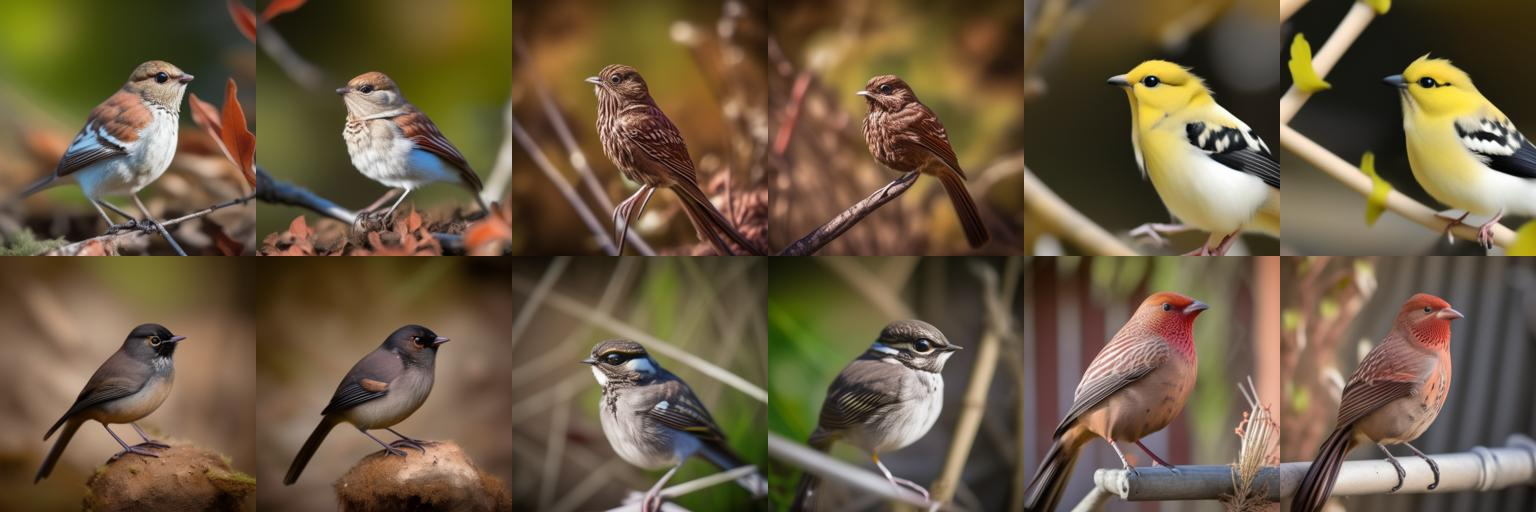

In [ ]:
STEPS = 20  # @param {type:"integer"}
GUIDANCE_SCALE = 4.0  # @param {type:"number"}
IMAGES_PER_PROMPT = 2  # @param {type:"integer"}

run_stage('frozen', '--steps', STEPS, '--guidance', GUIDANCE_SCALE, '--images-per-prompt', IMAGES_PER_PROMPT)
show_image('kandinsky_generation_frozen_grid.jpg', 'Frozen model: the generated images, two per caption')

**What to notice:** a validation and a test denoising loss, the test loss broken down by timestep, then twelve generated images with three CLIP measures beside the same three measures on the real photographs. One line per caption shows the prompt, its CLIP score, the caption CLIP found nearest and whether that was the right one. The grid under the output (`outputs/kandinsky_generation_frozen_grid.jpg` in the run directory) holds the twelve images: compare what you see with the numbers.

**Checkpoint:** read `by_timestep_test`. Where is the loss highest, and why is a denoising loss not a measure of how good the generated images look?

<details>
<summary>Check your reasoning (open after answering)</summary>

The UNet predicts the added noise. At a large timestep the noisy latent is mostly noise, so the noise is comparatively easy to recover; at a small timestep the noise is a faint perturbation of the image and is harder to separate out. The loss is therefore usually highest at the smallest timesteps — but read your own `by_timestep_test` rather than assuming it. The loss measures how well the UNet fits *these photographs* under the training objective. It says nothing directly about composition, sharpness or whether a person would find an image convincing, which is why the notebook also reads CLIP scores and keeps the real-photo reference line beside them. The CLIP scores are another model's opinion, not a human judgement: a generated image can score above the real photographs on a CLIP reading and still look wrong to a birdwatcher. With twelve images, label accuracy moves in steps of 1/12, so one image changes it by about 0.08.

On the CLIP question: in the recorded Kaggle T4 run of the previous revision, the frozen generations scored prompt similarity 33.2 against the real photographs' 30.3 — above the reference line — and label accuracy 0.83 against 0.92. That run printed 88.66 for the real photographs' reference similarity because each photo was then included in its own reference; leave-one-out, the same photographs give about 57.7, below the generations' 68.9. So the real photographs are not a ceiling on two of the three readings; label accuracy is the one on which the frozen model sat below them. Read your own numbers rather than these.

</details>

## 7. Bounded LoRA fine-tuning · [Concept]

The `adapt` stage calls `pipe.adapt`, which trains the 176 LoRA tensors (rank 8, 1,646,592 parameters — 0.13 % of the UNet) that `peft` attached to the attention projections of the UNet, and nothing else; the UNet base, the MoVQ and the prior are frozen. Each step takes one training photograph's latent (MoVQ-encoded once, seeded), draws a timestep uniformly from the 1,000-step schedule and a noise tensor (both seeded), adds the noise, and minimises the MSE between the predicted and the true noise; AdamW at a fixed learning rate, gradient-norm clipping at 1.0, float16 autocast with loss scaling on CUDA. Epoch 0 records the frozen model's validation loss, and the epoch with the lowest validation denoising loss is kept. Before its process ends, the stage records two reference values of the trained model still in memory — its test denoising loss and one image at a fixed seed — and exports the adapter as `outputs/kandinsky_generation_adapter/` (`adapter.safetensors` + `manifest.json`).

**Predict before running:** will the training loss fall smoothly from epoch to epoch? Will the kept (best) epoch be the last one?

In [ ]:
EPOCHS = 4  # @param {type:"integer"}
LEARNING_RATE = 1e-4  # @param {type:"number"}
BATCH_SIZE = 1  # @param {type:"integer"}

run_stage('adapt', '--epochs', EPOCHS, '--lr', LEARNING_RATE, '--batch-size', BATCH_SIZE)

Running stage 'adapt' in the isolated environment; log: /content/outputs/kandinsky_generation/e1c4f6048f1f/logs/adapt.log


W1004 13:23:34.369000 5164 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 13:23:34.420000 5164 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


{'epoch': 0, 'train_loss': None, 'val_denoising_mse': 0.077634, 'note': 'frozen model (LoRA at initialisation: B = 0)'}


...

{'epoch': 3, 'train_loss': 0.0439, 'val_denoising_mse': 0.076943}


{'epoch': 4, 'train_loss': 0.0733, 'val_denoising_mse': 0.076716}


{'trainable_parameters': 1646592, 'total_parameters': 1254703880, 'steps': 144, 'best_epoch': 4, 'precision': 'float16 autocast + GradScaler', 'seconds': 75.9, 'gpu_memory_gb': 2.71}


{'artifact': '/content/outputs/kandinsky_generation/e1c4f6048f1f/outputs/kandinsky_generation_adapter', 'format': 'org.valcorza.kandinsky-generation.adapter.v1', 'tensors': 176, 'bytes': 6607664, 'sha256': 'e2d44b8c89826420...'}


{'stage': 'adapt', 'status': 'ok', 'seconds': 165.4}


**What to notice:** one line per epoch — epoch 0 is the frozen model's validation loss with no training loss — then a summary with 1,646,592 trainable parameters out of the UNet's total, the number of optimiser steps, the `best_epoch`, the precision and the elapsed seconds; then the exported artifact: 176 tensors of about 6.6 MB with its SHA-256.

**Checkpoint:** why is the kept epoch chosen on the validation photographs and not on the test photographs?

<details>
<summary>Check your reasoning (open after answering)</summary>

Choosing the epoch is a decision made by looking at scores. If it were made on the test photographs, the test result would be the best of several tries on the same data and would overstate how the adapter does on photographs it has never influenced. Keeping the test photographs out of every decision makes Section 8 a held-out measurement. The training loss is noisy because each step draws a batch (one photograph by default), a random timestep and random noise, and the loss depends strongly on the timestep; a single epoch's value is not a trend. Because epoch 0 (the frozen model) is a candidate, the kept validation loss can never be worse than the frozen one — if no epoch improves on it, epoch 0 is kept and the adapter stays at its zero initialisation.

</details>

## 8. Held-out evaluation: the paired comparison · [Evaluation practice]

**Question tested:** on test photographs and prompt/seed pairs that played no part in training or epoch selection, does the adapted model fit the photographs better than the frozen one, and do its generations move closer to the held-out real photographs of their caption (reference similarity) while still following the prompt (prompt similarity)?

The test photographs were never used for training or epoch selection. The `evaluate` stage is a fresh process: it loads the adapter from the exported files — the artifact you would ship, not the object that was trained — and scores it exactly as the frozen model was scored in Section 6 — the same seed, so the same latents, noise and timesteps, and the same twelve prompt/seed pairs for generation — and the table puts the frozen, the adapted and the real-photo numbers side by side. The stage asserts only what the procedure guarantees — the kept epoch's validation loss is no higher than the frozen model's (epoch 0) — and that the exported adapter reproduces the validation loss recorded for the kept epoch.

**Predict before running:** will the test denoising loss fall, and by a lot or a little? Which CLIP measure do you expect to move most after adaptation, and in which direction?

Running stage 'evaluate' in the isolated environment; log: /content/outputs/kandinsky_generation/e1c4f6048f1f/logs/evaluate.log


W1004 13:26:24.041000 5862 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 13:26:24.094000 5862 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


...

{'grid': '/content/outputs/kandinsky_generation/e1c4f6048f1f/outputs/kandinsky_generation_adapted_grid.jpg'}


{'test_denoising_mse_change': -0.000914, 'note': 'held-out observation, not asserted'}


{'report': '/content/outputs/kandinsky_generation/e1c4f6048f1f/outputs/kandinsky_generation_evaluation_report.json'}


{'stage': 'evaluate', 'status': 'ok', 'seconds': 144.5}


Frozen model (Section 6) -> /content/outputs/kandinsky_generation/e1c4f6048f1f/outputs/kandinsky_generation_frozen_grid.jpg


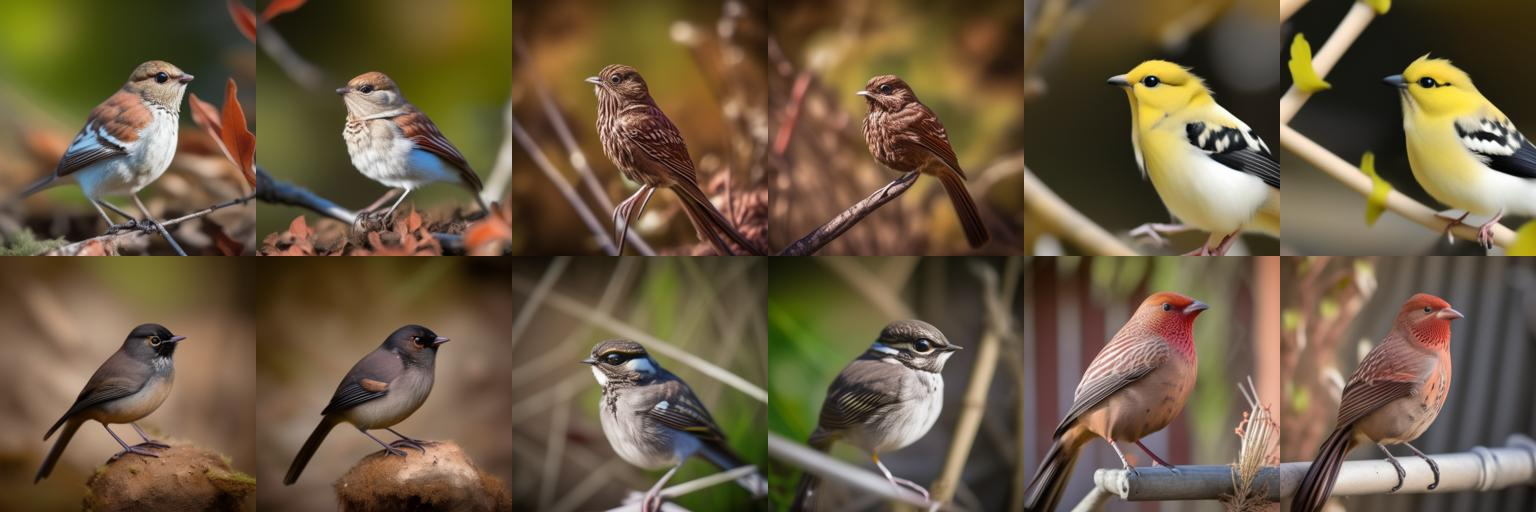

Adapted model: same prompts, same seeds -> /content/outputs/kandinsky_generation/e1c4f6048f1f/outputs/kandinsky_generation_adapted_grid.jpg


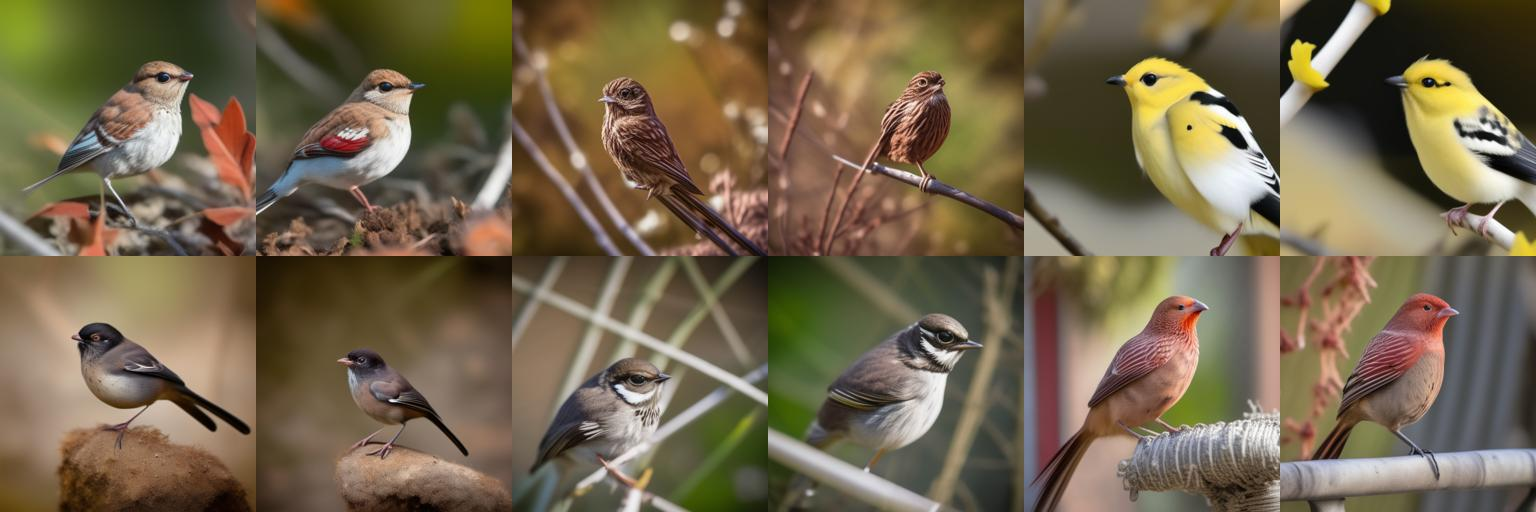

In [ ]:
run_stage('evaluate')
show_image('kandinsky_generation_frozen_grid.jpg', 'Frozen model (Section 6)')
show_image('kandinsky_generation_adapted_grid.jpg', 'Adapted model: same prompts, same seeds')

**What to notice:** each row of the comparison pairs a frozen and an adapted value measured on identical inputs, with the real photographs' value beside the CLIP rows. `test_denoising_mse_change` is printed as a held-out observation, not asserted: a negative value means the adapted model fits the unseen test photographs better. Compare the two grids under the output — same prompts, same seeds, so any difference comes from the adapter. The full record is `outputs/kandinsky_generation_evaluation_report.json` in the run directory.

**Checkpoint:** which of these results does the procedure *guarantee*, and which are *observations* that could come out differently on another run or another dataset?

<details>
<summary>Check your reasoning (open after answering)</summary>

Guaranteed: the kept epoch's validation loss is no higher than the frozen model's, because epoch 0 is one of the candidates — the cell asserts exactly that and nothing more. Everything on the test photographs is an observation: the test loss can rise even when validation fell, and the CLIP measures can move in either direction. The comparison is *paired* — same latents, noise, timesteps, prompts and seeds — so a difference is not a re-draw of randomness; but it is still one seeded run on 12 photographs and 12 images, with no estimate of spread. A small change in label accuracy is one or two images. A defensible sentence has the form: "on these 12 held-out photographs, the adapter changed the test denoising loss from *a* to *b* and the reference similarity from *c* to *d*, beside a leave-one-out real-photo reference of *e*" — a reference line, not a ceiling, so moving towards or past it is not the goal in itself. "The adapter makes better bird pictures" is not supported by these numbers.

</details>

## 9. Fresh reload and a new prompt · [Engineering]

The `reload` stage is a second fresh process. `KandinskyPipeline.from_artifact` re-verifies both snapshots, checks the artifact's manifest — the format, the decoder's id and revision, the LoRA scope and the weights' SHA-256 — **before** deserialising, loads a new UNet with the adapter attached and overlays the 176 tensors (OUT8). Nothing of the trained model survives in memory between processes, so this is a reload from files in the strictest sense (VER2). The stage then checks parity against the two reference values the `adapt` process recorded from the trained model while it was still in memory: the same held-out test denoising loss and the same image for the same prompt and seed (VER4). Only after parity holds does it render `NEW_PROMPT` — a composition that appears in no training caption — at two seeds; the CLIP prompt similarity is printed as a sanity check, not an evaluation. Finally it writes `outputs/kandinsky_generation_result.json` with the provenance, the runtime versions and the comparison, and lists every file in the run's `outputs/`.

**Expected result:** the artifact of 176 tensors of about 6.6 MB with its SHA-256, a `reload_parity` dictionary whose two differences are at or near zero, a CLIP prompt similarity for the new prompt labelled as a sanity check, the listing of `outputs/`, and the two new-prompt images.

Running stage 'reload' in the isolated environment; log: /content/outputs/kandinsky_generation/e1c4f6048f1f/logs/reload.log


{'artifact': '/content/outputs/kandinsky_generation/e1c4f6048f1f/outputs/kandinsky_generation_adapter', 'format': 'org.valcorza.kandinsky-generation.adapter.v1', 'tensors': 176, 'bytes': 6607664, 'sha256': 'e2d44b8c89826420...'}


W1004 13:28:52.030000 6479 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 13:28:52.083000 6479 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


...

  - outputs/prepare.json (2.2 KB)


  - outputs/reload.json (0.3 KB)


  - outputs/weights.json (1.7 KB)


{'stage': 'reload', 'status': 'ok', 'seconds': 98.3}


New prompt, seed 2000 (reloaded adapter) -> /content/outputs/kandinsky_generation/e1c4f6048f1f/outputs/kandinsky_generation_new_prompt_0.png


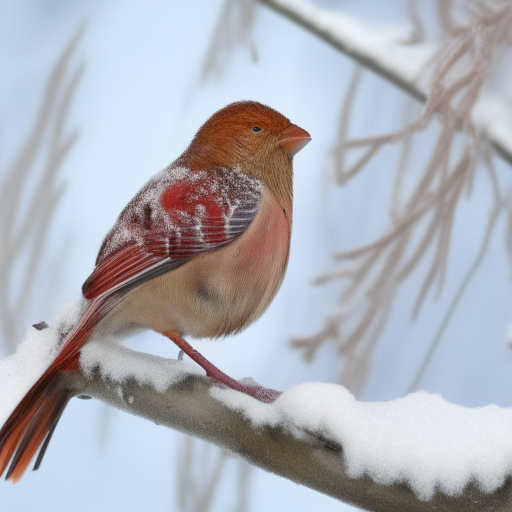

New prompt, seed 2001 (reloaded adapter) -> /content/outputs/kandinsky_generation/e1c4f6048f1f/outputs/kandinsky_generation_new_prompt_1.png


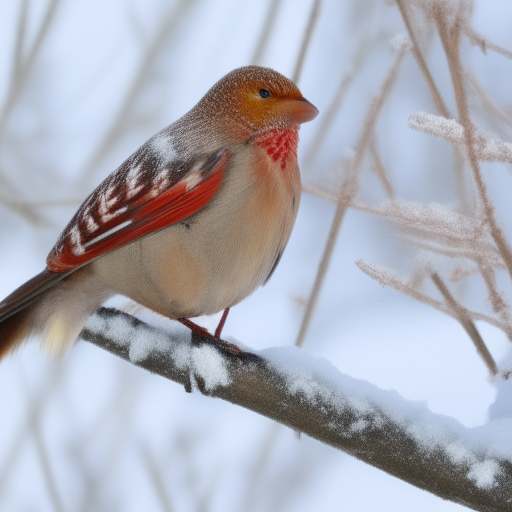

In [ ]:
run_stage('reload')
show_image('kandinsky_generation_new_prompt_0.png', 'New prompt, seed 2000 (reloaded adapter)')
show_image('kandinsky_generation_new_prompt_1.png', 'New prompt, seed 2001 (reloaded adapter)')

**What to notice:** the reloaded pipeline was built in a process that never saw the trained model — only `adapter.safetensors`, `manifest.json` and the verified base snapshots — so matching numbers show that the files alone carry the adaptation. Reload parity shows that a saved computation can be reproduced; it says nothing about whether the adapter is good. The new prompt's CLIP score is one composition at two seeds: a sanity check, not a test of generality. This is the end of the canonical path; everything it produces is in `outputs/`.

## 10. Optional activity: change one thing — the guidance scale · [Concept]

**Predict → Change one thing → Run → Observe → Explain.** This activity is off by default and changes nothing the canonical path produced: with `RUN_ACTIVITY = False` the next cell only prints how to switch it on. It runs the `activity` stage, which loads the exported adapter, reuses the twelve prompt/seed pairs of Section 8 and the prompt embeddings already encoded, so it downloads nothing and does not reload the prior.

**Change one thing:** generation uses classifier-free guidance at `GUIDANCE_SCALE` (4.0 by default). Set `ACTIVITY_GUIDANCE_SCALE` to another value between 1.0 and 20.0 (outside that range `generate` refuses) and `RUN_ACTIVITY = True`, then run the cell. Prompts, seeds, steps and the adapter stay fixed; only the guidance scale changes. At exactly 1.0 the pipeline skips guidance: the UNet sees only the prompt's embedding and the negative prompt is not used.

**Predict before running:** with guidance lowered to 1.0, will CLIP prompt similarity rise or fall? What about label accuracy and reference similarity? Write your prediction down.

In [ ]:
RUN_ACTIVITY = False  # @param {type:"boolean"}
ACTIVITY_GUIDANCE_SCALE = 1.0  # @param {type:"number"}

if RUN_ACTIVITY:
    run_stage('activity', '--guidance', ACTIVITY_GUIDANCE_SCALE)
    show_image('kandinsky_generation_activity_grid.jpg', 'Adapted model at the activity guidance scale')
else:
    print({'activity': 'skipped (optional)', 'to_run': 'set RUN_ACTIVITY = True and a guidance scale in 1.0..20.0, then run this cell'})

{'activity': 'skipped (optional)', 'to_run': 'set RUN_ACTIVITY = True and a guidance scale in 1.0..20.0, then run this cell'}


**Observe:** three rows, each with the value at the default guidance, at your guidance and on the real photographs, then the generation time at both settings; compare the activity grid under the output with the adapted grid in Section 8.

**Explain:** did the result match your prediction? Which measure moved most, and does what you see in the two grids agree with the numbers?

<details>
<summary>Check your reasoning (open after answering)</summary>

Guidance amplifies the difference between the prompt-conditioned and the unconditioned prediction, so a lower scale usually follows the prompt less closely — CLIP prompt similarity and label accuracy often fall — while images can look less saturated and more varied. A higher scale usually pushes the other way, up to a point where images become over-contrasted. "Usually" is the honest word: twelve images at one seed each are a small sample, and a result against the usual direction is an observation about this run, not a failed activity. Guidance also costs time: above 1.0 the UNet evaluates both the prompt and the negative prompt at every step, so compare the two `seconds` values. Because only the guidance scale changed, any difference is caused by it — the adapter, the prompts and the seeds were held fixed. This is a generation setting, not training: the held-out denoising loss does not depend on it.

</details>

## Troubleshooting · [Engineering]

| Symptom | Likely cause | What to do |
|---|---|---|
| Section 1 stops with `No GPU driver was found` or `CUDA was not detected`, or Section 2 stops with `The isolated environment cannot see a CUDA GPU` | the runtime has no GPU | *Runtime → Change runtime type → T4 GPU*, then run all again from the top. This notebook is not supported on a CPU-only runtime. If Colab offers no GPU, your GPU quota may be exhausted; try again later. |
| Section 1 stops with `This notebook needs a Linux x86_64 GPU runtime` | a local Windows or macOS kernel, or an ARM machine | Use Google Colab, Kaggle, or a Linux x86_64 machine with a CUDA GPU: the locked environment is built for manylinux x86_64 wheels. |
| Section 1 stops with `Not enough free disk` | the snapshots need about 16.5 GB and the isolated environment about 12 GB | Start a fresh runtime with about 30 GB free; a `weights/` directory from an earlier run is reused and counted. |
| `Carried file integrity failure` in Section 2 | a carried file was edited in the notebook | Do not edit the infrastructure cells; open a fresh copy of the notebook from the repository. |
| `uv 0.12.15 wheel size/hash mismatch`, or a `URLError` / timeout while downloading it | a network failure or an unexpected response from PyPI | Re-run the Section 2 install cell. Never replace the pinned URL or digest. |
| `CalledProcessError` from `uv venv` or `uv pip install` (for example a hash mismatch, `Failed to download` or HTTP 5xx) | a transient PyPI or network failure, or a package that no longer matches the lock | Re-run the Section 2 install cell: `uv` reuses what it already downloaded. If a hash mismatch repeats, stop and report it — never remove `--require-hashes`, a pin or a hash to get past it. |
| `RuntimeError: Stage '…' failed (exit 2): …` | the stage raised an error; the message after the colon is the stage's own error, and the stage's full log (with the traceback) is printed above it and kept in the run directory's `logs/` | Find the message in the rows below. A stage reads only files, so after fixing the cause you can re-run that cell and the cells after it. |
| `… is missing: run the stage that writes it before …` | a learner cell was run before an earlier stage | Run the notebook from the top, or re-run the earlier cells in order. |
| `the dataset changed since 'prepare'` | the BYOD zip or the photo cache changed after Section 4 | Re-run from Section 4. |
| A download error (timeout, HTTP 429/5xx) in Section 3 | a transient Hugging Face Hub failure | Re-run the Section 3 cell: staging only fetches the files that are still absent. |
| `ValueError: ...: size ... != manifest ...` or `sha256 ... != manifest ...` | a partial or corrupted download (staging checks that a file exists, verification checks its bytes) | Delete the named file under `weights/` and re-run the Section 3 cell. Never edit a manifest to get past a mismatch. |
| `No space left on device` during a stage | the disk filled after the Section 1 check | Start a fresh runtime with about 30 GB free. |
| A photograph fetch fails in Section 4 (`URLError`, or `fetched ... bytes with sha256 ..., pinned ...`) | a network failure or an unexpected response from the iNaturalist bucket | Re-run the Section 4 cell; photographs already verified are kept in `weights/inat-birds/` and reused. |
| `CUDA out of memory` | a form field was raised (`BATCH_SIZE`, `IMAGES_PER_PROMPT`), or another program in the runtime holds GPU memory | Set the fields back to their defaults and re-run that cell: each stage is its own process, so the failed stage's memory was released when it stopped. |
| `ModuleNotFoundError: No module named 'google.colab'` with `USE_BYOD = True` | the upload dialog needs Google Colab | Set `BYOD_PATH` to a zip already in the runtime, use Colab for the upload, or keep `USE_BYOD = False`. |
| `BYOD zip must contain captions.csv` or `captions.csv is missing columns [...]` | the zip layout differs from the contract | Put `captions.csv` with the columns `id`, `file`, `caption` in the zip beside the images; the run directory's `outputs/kandinsky_generation_sample_captions.csv` shows the expected shape. |
| `KeyError` naming an image file in the `prepare` stage's error | a `file` value that is not the bare name of an image in the zip | Use the file name only (`bird01.jpg`, not `images/bird01.jpg`) and make sure every listed image is in the zip. |
| `image sides must be within 256..4096 px`, `split leaves no test record` or `split leaves ... training records` | a BYOD image is too small or too large, or there are too few images per caption | Resize the image, and meet the stated minimum: at least one caption with six or more distinct images (the split keeps about 20 % of each such caption for validation and 20 % for test, and needs at least four training images). |

## Interpretation and limits · [Evaluation practice]

The question this notebook can answer is narrow: does a LoRA of 1.6 million parameters, trained for a few minutes on 36 captioned photographs, change the held-out denoising loss on twelve photographs the model never saw, and move its generations towards the held-out real photographs of the same species? Your run answers it in Section 8, on identical inputs before and after, with the leave-one-out real-photo reference line beside the CLIP measures; read the direction and the size of each change there rather than from this text. The artifact that carries the adaptation is about 6.6 MB.

The numbers are sample-sanity evidence. A denoising loss is the training objective, not a quality score; CLIP similarity and CLIP's nearest-caption vote are a frozen model's opinion, not a human judgement, and CLIP itself has biases about what a species name looks like; twelve images per model from one seeded run give no dispersion estimate; and nothing here measures aesthetics, diversity, artefacts or prompt fidelity beyond the six captions. The real photographs are a **reference line, not a ceiling**: generated images can score above them on prompt similarity and reference similarity, so a generation that beats a photograph on a CLIP reading is not a better bird picture. Fine-tuning on a narrow domain can also erode the model elsewhere — the new prompt in Section 9 is a sanity check on one composition, not a test of generality.

**Pretraining overlap.** The 60 sample photographs are public iNaturalist images, and both the generator and the CLIP scorer were trained on web-scale image–text data that may include them or near copies. The label accuracy, the reference similarity and the real-photo values on the sample may therefore be optimistic; BYOD on private photographs avoids this.

Three things to carry to real data. **Captions are the contract:** the adapter learns the association between the caption text and the images; a caption that does not describe its image, or one caption for very different images, teaches noise. **Stratify by caption:** every caption with three or more images has held-out photographs, so the test measures new photographs of seen captions, not unseen captions; a caption with fewer than three images is used for training only and cannot be evaluated. A random split also assumes the photographs are independent, so keep bursts, crops and repeat shots of one individual or scene out of the dataset. **Licences travel with the outputs:** the Kandinsky weights are Apache-2.0, the training photographs here are CC0 — with your own data, the rights to the images and to what the adapter produces are yours to establish.

Successful execution proves that the recorded repository revision's pipeline modules and stage runner, carried in this standalone notebook and run in an isolated hash-locked environment, can stage and digest-verify three pinned safetensors snapshots, fetch and validate digest-pinned real photographs, encode prompts and release the prior, execute bounded LoRA fine-tuning, evaluate the frozen and the adapted model on identical held-out inputs beside a leave-one-out real-photo reference line, reload the exported adapter in a fresh process with parity to the trained model, and emit the shown machine-readable artifacts — without the repository being reachable. It does **not** establish benchmark superiority, production fitness, or image quality beyond the checks shown.

## Conclude with evidence · [Evaluation practice]

Complete this in your own words, using the numbers your run printed:

> On [12 held-out photographs of six bird species / your BYOD test set], adapting Kandinsky 2.2 with a rank-8 LoRA for [epochs] epochs (kept epoch [best_epoch]) changed the test denoising loss from [frozen] to [adapted]. For twelve images at fixed prompts and seeds, CLIP prompt similarity went from [frozen] to [adapted], label accuracy from [frozen] to [adapted] and reference similarity from [frozen] to [adapted], beside a leave-one-out real-photo reference (a reference line, not a ceiling) of [real-photo values]. The most important failure mode or uncertainty is [for example: one seeded run with no spread estimate; CLIP's own view of a species name; a species the generations still miss]. These numbers do not show [image quality to a human viewer / behaviour on other prompts or domains / ...]. Next I would [specific next experiment].

<details>
<summary>Check your reasoning: what makes a conclusion strong? (open after writing yours)</summary>

A strong conclusion names the task and the data (how many held-out photographs, which captions), reports the frozen baseline and the real-photo reference line beside the adapted numbers, and keeps the guaranteed result (validation loss no worse than epoch 0) apart from the observations (everything on the test set). It says that the denoising loss is the training objective and that CLIP scores are another model's opinion, so neither is a quality judgement. It states the limits of one seeded run on twelve photographs and does not generalise beyond six species in one photographic style. It ends with a specific next step — several seeds to estimate spread, a larger held-out set, or a human rating of the two grids. A weak conclusion says only that "fine-tuning improved the model".

</details>

**Transfer:** switch on BYOD (Section 4) with your own captioned photographs of one narrow domain — at least one caption with six or more distinct images, independent of each other — and write the same conclusion for it. Before running, predict whether the held-out loss will change more or less than it did for the birds, and why.

## References

- Repository README: https://github.com/kurtvalcorza/kandinsky-generation-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/kandinsky-generation-pipeline/blob/main/MODEL_CARD.md
- Weights notes: https://github.com/kurtvalcorza/kandinsky-generation-pipeline/blob/main/docs/WEIGHTS.md
- Hugging Face decoder repository: https://huggingface.co/kandinsky-community/kandinsky-2-2-decoder (revision `9ae140d347fed8ce6e8bb3005dcc1f48543bb8e3`)
- Hugging Face prior repository: https://huggingface.co/kandinsky-community/kandinsky-2-2-prior (revision 9fc51ad5732afc5d031724219d22e6c42179c5a8)
- Shakhmatov, A., et al. (2023). Kandinsky 2.2: https://github.com/ai-forever/Kandinsky-2
- uv (the installer that builds the isolated environment): https://docs.astral.sh/uv/
- Hu, E. J., et al. (2022). LoRA: Low-rank adaptation of large language models. ICLR: https://arxiv.org/abs/2106.09685
- Cherti, M., et al. (2023). Reproducible scaling laws for contrastive language-image learning. CVPR (the LAION CLIP scorer): https://arxiv.org/abs/2212.07143
- DIMER Notebook Specification 2.2 and Model Card Specification 1.2 (in the ml-worker repository)